In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import scipy.sparse as sp
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.stats import spearmanr
import celltypist
from celltypist import models

/home/jack/miniforge3/envs/scanpy/lib/python3.14/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [2]:
IN_DIR = "/mnt/md0/jack-gaa/gaa/analysis/shared_6way_qc_unified/"
LR_CONDITIONS = ['LR_Std', 'LR_Aug', 'LR_Dis']

adatas = {}
for name in LR_CONDITIONS:
    adatas[name] = sc.read_h5ad(os.path.join(IN_DIR, f"{name}.h5ad"))
    print(f"Loaded {name}: {adatas[name].n_obs:,} cells x {adatas[name].n_vars:,} features")

for name in LR_CONDITIONS[1:]:
    assert all(adatas[LR_CONDITIONS[0]].obs_names == adatas[name].obs_names)
print(f"Confirmed identical, already-QC-passed barcodes: {adatas['LR_Std'].n_obs:,} cells")

qc_pass_barcodes = adatas['LR_Std'].obs_names.tolist()

adatas_raw = {name: adatas[name].copy() for name in LR_CONDITIONS}

Loaded LR_Std: 2,280 cells x 27,389 features
Loaded LR_Aug: 2,280 cells x 81,614 features
Loaded LR_Dis: 2,280 cells x 159,670 features
Confirmed identical, already-QC-passed barcodes: 2,280 cells


In [3]:
def run_lr_clustering(adata, name):
    print(f"-> Processing {name}...")
    sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor='seurat')
    sc.tl.pca(adata, svd_solver='arpack', random_state=42)
    sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30, random_state=42)
    sc.tl.umap(adata, random_state=42)
    sc.tl.leiden(adata, resolution=0.5, key_added='leiden', random_state=42)
    print(f"   Done. {name} generated {len(adata.obs['leiden'].unique())} clusters.")
    return adata

for name in LR_CONDITIONS:
    adatas[name] = run_lr_clustering(adatas[name], name)

-> Processing LR_Std...


/home/jack/miniforge3/envs/scanpy/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


   Done. LR_Std generated 11 clusters.
-> Processing LR_Aug...
   Done. LR_Aug generated 11 clusters.
-> Processing LR_Dis...
   Done. LR_Dis generated 10 clusters.


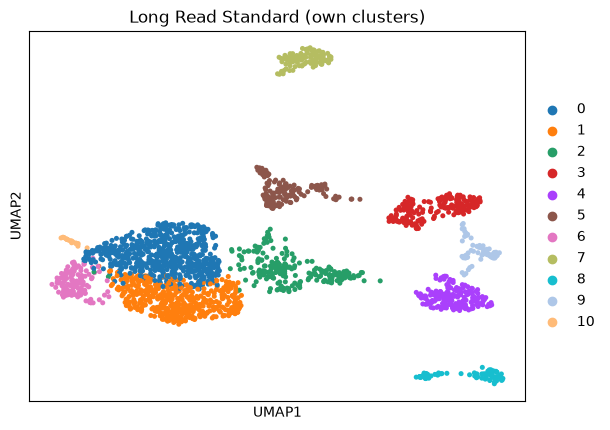

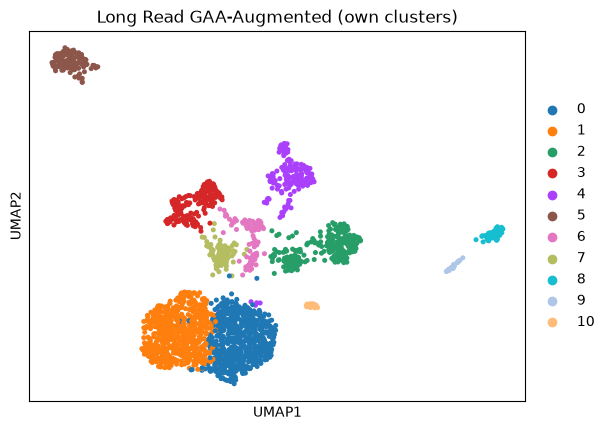

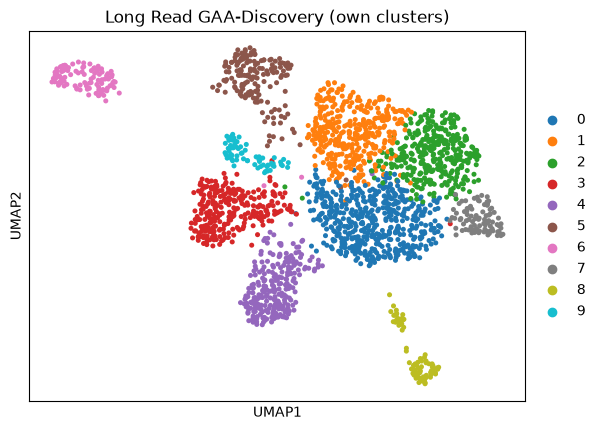

In [4]:
sc.pl.umap(adatas['LR_Std'], color='leiden', title='Long Read Standard (own clusters)')
sc.pl.umap(adatas['LR_Aug'], color='leiden', title='Long Read GAA-Augmented (own clusters)')
sc.pl.umap(adatas['LR_Dis'], color='leiden', title='Long Read GAA-Discovery (own clusters)')

## Peak-level feature isolation




In [5]:
adata_lr_dis_peaks = adatas_raw['LR_Dis'][:, adatas_raw['LR_Dis'].var_names.str.contains('peak', case=False)].copy()
adata_lr_aug_peaks = adatas_raw['LR_Aug'][:, adatas_raw['LR_Aug'].var_names.str.contains('peak', case=False)].copy()

print(f"LR Discovery — full peak-level features:            {adata_lr_dis_peaks.n_vars:,}")
print(f"LR Augmented — peak-named (non-merged-class) only:  {adata_lr_aug_peaks.n_vars:,}")

LR Discovery — full peak-level features:            159,670
LR Augmented — peak-named (non-merged-class) only:  54,836


## Discovery gene-level collapse

In [6]:
COLLAPSE_CLASSES = {
    'known_exon', 'extended_exon', 'proximal_novel_exon',
    'known_transcript_intronic', 'known_gene_intronic',
}
KEEP_SEPARATE_CLASSES = {'antisense_exonic', 'antisense_intronic', 'intergenic'}


def parse_discovery_id(var_name):
    parts = var_name.split('|')
    if len(parts) < 3:
        return None, None, None
    context, classification, peak_id = parts[0], parts[1], '|'.join(parts[2:])
    return context, classification, peak_id


def build_gene_map(adata_dis):
    gene_map = {}
    for v in adata_dis.var_names:
        context, cls, peak_id = parse_discovery_id(v)
        if cls in COLLAPSE_CLASSES and context:
            gene_map[v] = context
    return gene_map


def collapse_discovery_to_gene_level(adata_dis, gene_map):
    var_names = list(adata_dis.var_names)
    targets = [gene_map.get(v, v) for v in var_names]
    target_genes = sorted(set(targets))
    gene_index = {g: i for i, g in enumerate(target_genes)}

    row_idx = [gene_index[t] for t in targets]
    col_idx = list(range(len(var_names)))
    data = np.ones(len(var_names))
    M = sp.csr_matrix((data, (row_idx, col_idx)), shape=(len(target_genes), len(var_names)))

    X_new = adata_dis.X @ M.T
    adata_gene = ad.AnnData(X=sp.csr_matrix(X_new), obs=adata_dis.obs.copy())
    adata_gene.var_names = target_genes
    return adata_gene


gene_map = build_gene_map(adatas_raw['LR_Dis'])
adata_lr_dis_genelevel = collapse_discovery_to_gene_level(adatas_raw['LR_Dis'], gene_map)
print(f"Collapsed {len(gene_map):,} peak features -> {adata_lr_dis_genelevel.n_vars:,} gene-level bins")

Collapsed 94,856 peak features -> 78,506 gene-level bins


## CellTypist annotation

📂 Storing models in /home/jack/.celltypist/data/models
💾 Total models to download: 1
⏩ Skipping [1/1]: Immune_All_Low.pkl (file exists)
🔬 Input data has 2280 cells and 30139 genes
🔗 Matching reference genes in the model
🧬 5628 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!
🔬 Input data has 2280 cells and 89454 genes
🔗 Matching reference genes in the model
🧬 5620 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!
🔬 Input data has 2280 cells and 78506 genes
🔗 Matching reference genes in the model
🧬 4142 features us

LR_Std: 10 cell types assigned
LR_Aug: 11 cell types assigned
LR_Dis: 5 cell types assigned


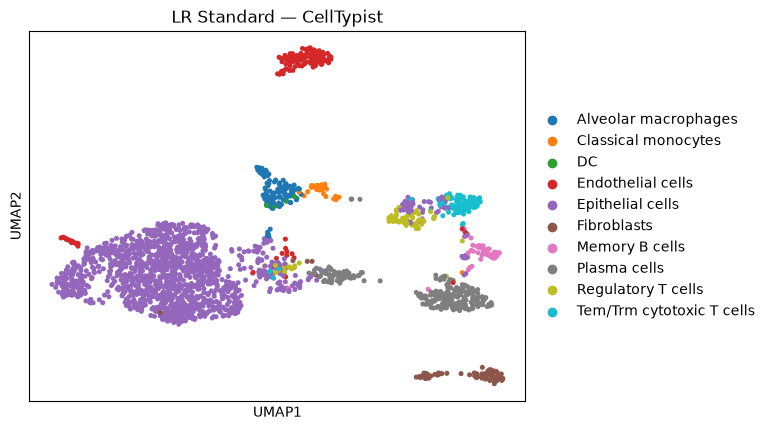

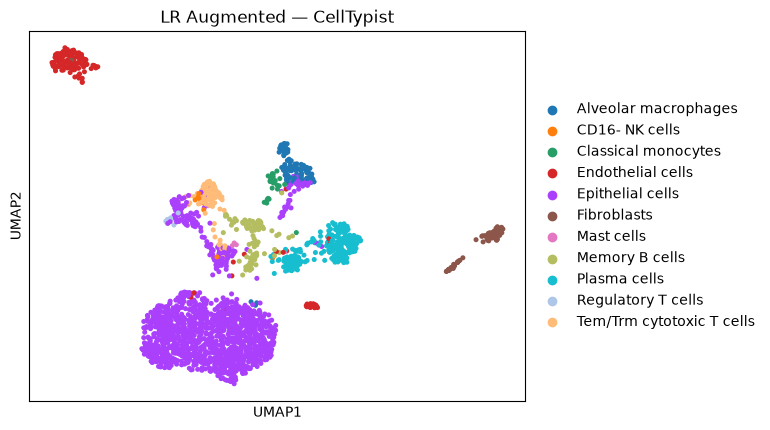

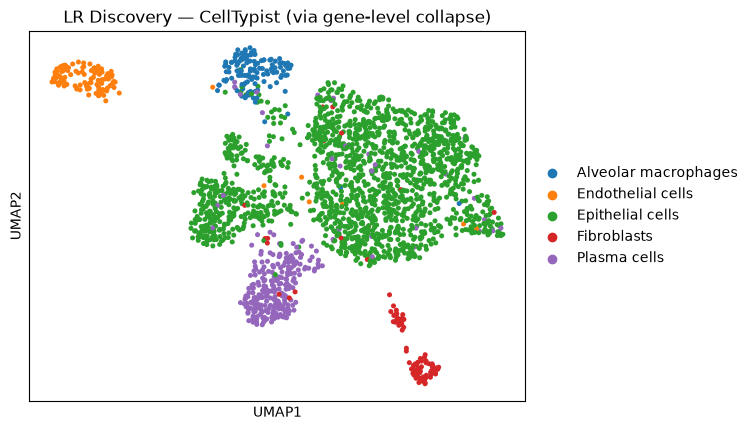

In [7]:
PATH_LR_STD_RAW = "/mnt/md0/jack-gaa/wf-single-cell/SRR21492157-wf-single-cell-v2/output/SRR21492157-data/SRR21492157-data.gene_raw_feature_bc_matrix/"
PATH_LR_AUG_RAW = "/mnt/md1/jack-gaa2/wf-single-cell-gaa-augmented-31Jul2026/output/SRR21492157-data/SRR21492157-data.gene_raw_feature_bc_matrix/"

adata_lr_std_raw_counts = sc.read_10x_mtx(PATH_LR_STD_RAW, var_names='gene_symbols', cache=True)
adata_lr_aug_raw_counts = sc.read_10x_mtx(PATH_LR_AUG_RAW, var_names='gene_symbols', cache=True)
adata_lr_aug_raw_counts.var_names = adata_lr_aug_raw_counts.var_names.str.replace('.tsv', '', regex=False)

adata_lr_std_for_celltypist = adata_lr_std_raw_counts[qc_pass_barcodes].copy()
adata_lr_aug_for_celltypist = adata_lr_aug_raw_counts[qc_pass_barcodes].copy()

sc.pp.normalize_total(adata_lr_std_for_celltypist, target_sum=1e4)
sc.pp.log1p(adata_lr_std_for_celltypist)
sc.pp.normalize_total(adata_lr_aug_for_celltypist, target_sum=1e4)
sc.pp.log1p(adata_lr_aug_for_celltypist)

adata_lr_dis_for_celltypist = adata_lr_dis_genelevel.copy()
sc.pp.normalize_total(adata_lr_dis_for_celltypist, target_sum=1e4)
sc.pp.log1p(adata_lr_dis_for_celltypist)

models.download_models(model=['Immune_All_Low.pkl'])

predictions_std = celltypist.annotate(adata_lr_std_for_celltypist, model='Immune_All_Low.pkl', majority_voting=True)
predictions_aug = celltypist.annotate(adata_lr_aug_for_celltypist, model='Immune_All_Low.pkl', majority_voting=True)
predictions_dis = celltypist.annotate(adata_lr_dis_for_celltypist, model='Immune_All_Low.pkl', majority_voting=True)

adatas['LR_Std'].obs['celltypist_label'] = predictions_std.predicted_labels['majority_voting'].values
adatas['LR_Aug'].obs['celltypist_label'] = predictions_aug.predicted_labels['majority_voting'].values
adatas['LR_Dis'].obs['celltypist_label'] = predictions_dis.predicted_labels['majority_voting'].values

for name in LR_CONDITIONS:
    print(f"{name}: {adatas[name].obs['celltypist_label'].nunique()} cell types assigned")

sc.pl.umap(adatas['LR_Std'], color='celltypist_label', title='LR Standard — CellTypist')
sc.pl.umap(adatas['LR_Aug'], color='celltypist_label', title='LR Augmented — CellTypist')
sc.pl.umap(adatas['LR_Dis'], color='celltypist_label', title='LR Discovery — CellTypist (via gene-level collapse)')

## Discovery cell capture 


In [8]:
n_types_by_condition = {name: adatas[name].obs['celltypist_label'].nunique() for name in LR_CONDITIONS}
print("Distinct cell types called per condition:", n_types_by_condition)

for name in LR_CONDITIONS:
    top_type_pct = 100 * adatas[name].obs['celltypist_label'].value_counts(normalize=True).iloc[0]
    print(f"{name}: largest single cell-type call accounts for {top_type_pct:.1f}% of cells")

Distinct cell types called per condition: {'LR_Std': 10, 'LR_Aug': 11, 'LR_Dis': 5}
LR_Std: largest single cell-type call accounts for 63.3% of cells
LR_Aug: largest single cell-type call accounts for 63.5% of cells
LR_Dis: largest single cell-type call accounts for 72.4% of cells


## Cluster agreement: Std vs Aug, Std vs Dis, Aug vs Dis

=== Cluster Agreement (ARI / NMI) ===
Std vs Aug: ARI=0.599  NMI=0.747
Std vs Dis: ARI=0.315  NMI=0.570
Aug vs Dis: ARI=0.373  NMI=0.637


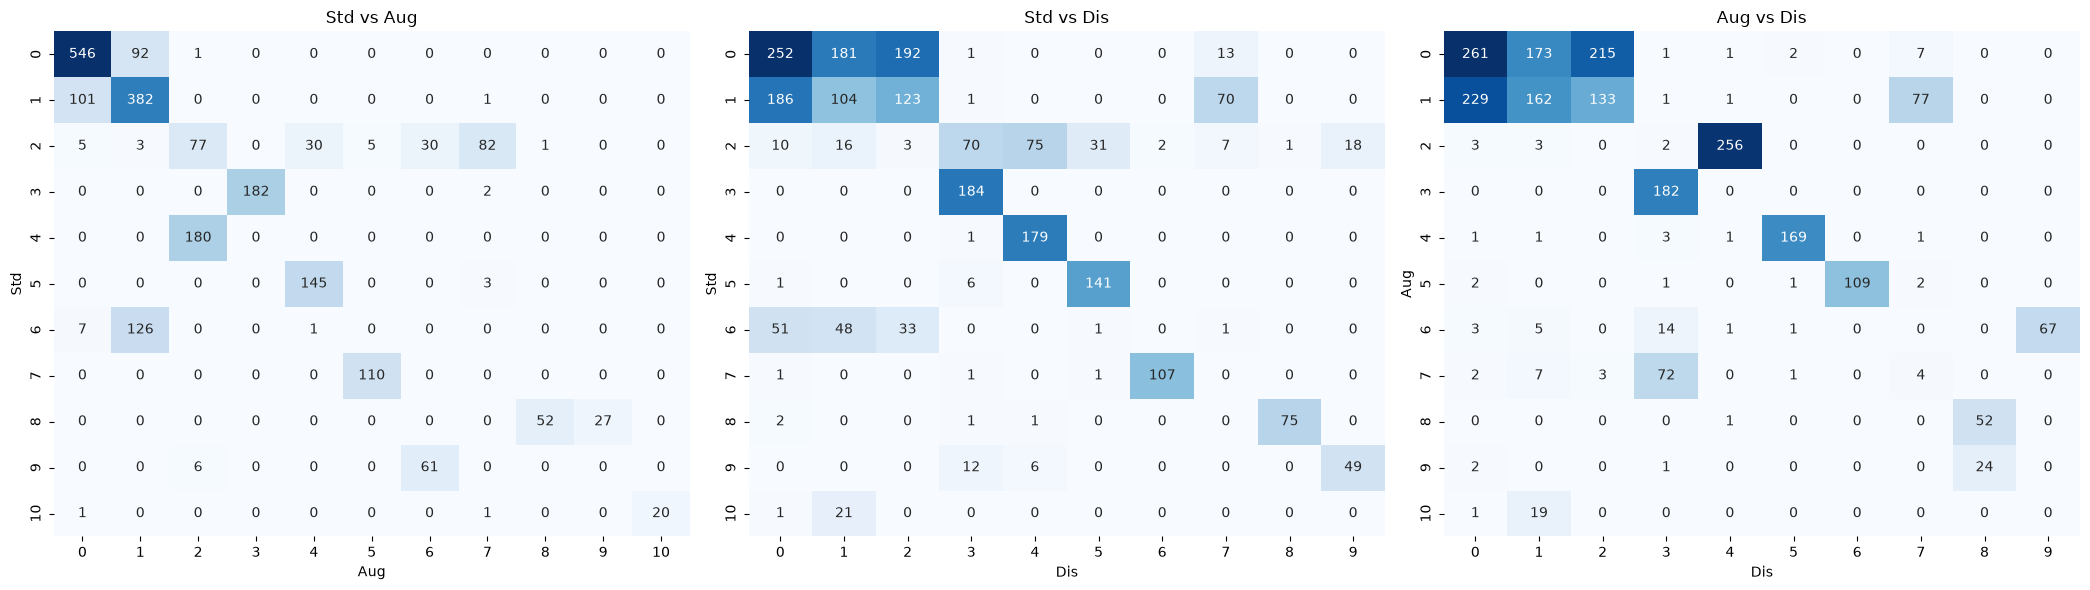


Look for any 1-to-many splits in the crosstabs above — candidates for the
cluster-split investigation function later in this notebook.


In [9]:
df_congruence = pd.DataFrame(index=qc_pass_barcodes)
df_congruence['Std'] = adatas['LR_Std'].obs['leiden']
df_congruence['Aug'] = adatas['LR_Aug'].obs['leiden']
df_congruence['Dis'] = adatas['LR_Dis'].obs['leiden']

pairs = [('Std', 'Aug'), ('Std', 'Dis'), ('Aug', 'Dis')]
congruence_results = {}

print("=== Cluster Agreement (ARI / NMI) ===")
for a, b in pairs:
    ari = adjusted_rand_score(df_congruence[a], df_congruence[b])
    nmi = normalized_mutual_info_score(df_congruence[a], df_congruence[b])
    congruence_results[(a, b)] = {'ari': ari, 'nmi': nmi}
    print(f"{a} vs {b}: ARI={ari:.3f}  NMI={nmi:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, (a, b) in zip(axes, pairs):
    ct = pd.crosstab(df_congruence[a], df_congruence[b])
    sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'{a} vs {b}')
    ax.set_xlabel(b)
    ax.set_ylabel(a)
plt.tight_layout()
plt.show()

print("\nLook for any 1-to-many splits in the crosstabs above — candidates for the")
print("cluster-split investigation function later in this notebook.")

## Std-based cluster labelling for Aug/Dis UMAPs


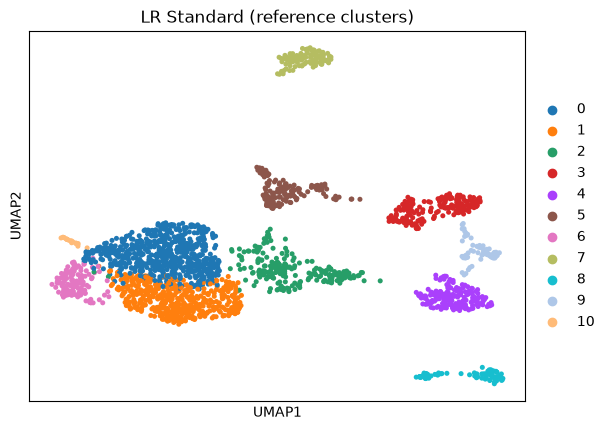

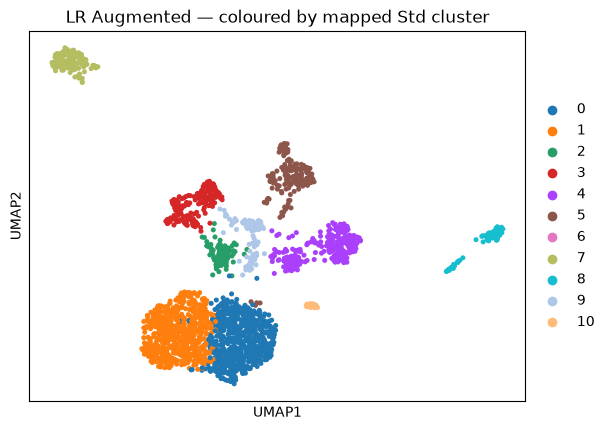

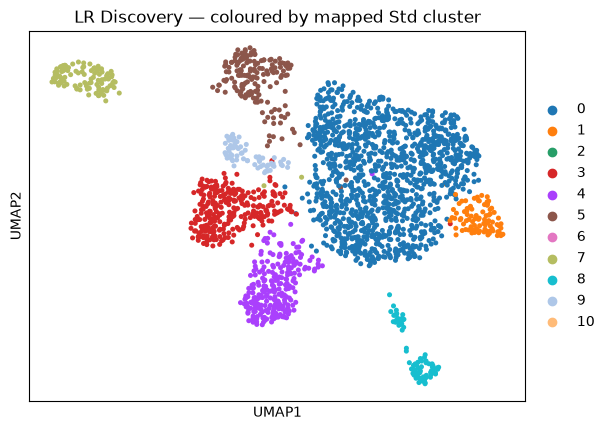

In [10]:
def transfer_labels_from_std(std_labels, other_labels):
    ct = pd.crosstab(other_labels, std_labels)
    return ct.idxmax(axis=1).to_dict()

aug_to_std_map = transfer_labels_from_std(df_congruence['Std'], df_congruence['Aug'])
dis_to_std_map = transfer_labels_from_std(df_congruence['Std'], df_congruence['Dis'])

adatas['LR_Aug'].obs['std_mapped_cluster'] = adatas['LR_Aug'].obs['leiden'].map(aug_to_std_map)
adatas['LR_Dis'].obs['std_mapped_cluster'] = adatas['LR_Dis'].obs['leiden'].map(dis_to_std_map)

shared_categories = sorted(df_congruence['Std'].astype(str).unique(), key=int)
adatas['LR_Std'].obs['leiden'] = pd.Categorical(adatas['LR_Std'].obs['leiden'].astype(str), categories=shared_categories)
adatas['LR_Aug'].obs['std_mapped_cluster'] = pd.Categorical(adatas['LR_Aug'].obs['std_mapped_cluster'].astype(str), categories=shared_categories)
adatas['LR_Dis'].obs['std_mapped_cluster'] = pd.Categorical(adatas['LR_Dis'].obs['std_mapped_cluster'].astype(str), categories=shared_categories)

sc.pl.umap(adatas['LR_Std'], color='leiden', title='LR Standard (reference clusters)')
sc.pl.umap(adatas['LR_Aug'], color='std_mapped_cluster', title='LR Augmented — coloured by mapped Std cluster')
sc.pl.umap(adatas['LR_Dis'], color='std_mapped_cluster', title='LR Discovery — coloured by mapped Std cluster')

## Sankey diagrams 

Std cluster -> dominant CellTypist label (n cells):
  0: Epithelial cells  (n=639)
  1: Epithelial cells  (n=484)
  2: Epithelial cells  (n=233)
  3: Tem/Trm cytotoxic T cells  (n=184)
  4: Plasma cells  (n=180)
  5: Alveolar macrophages  (n=148)
  6: Epithelial cells  (n=134)
  7: Endothelial cells  (n=110)
  8: Fibroblasts  (n=79)
  9: Memory B cells  (n=67)
  10: Endothelial cells  (n=22)

Aug cluster -> dominant CellTypist label (n cells):
  0: Epithelial cells  (n=660)
  1: Epithelial cells  (n=603)
  2: Plasma cells  (n=264)
  3: Tem/Trm cytotoxic T cells  (n=182)
  4: Alveolar macrophages  (n=176)
  5: Endothelial cells  (n=115)
  6: Memory B cells  (n=91)
  7: Epithelial cells  (n=89)
  8: Fibroblasts  (n=53)
  9: Fibroblasts  (n=27)
  10: Endothelial cells  (n=20)

Dis cluster -> dominant CellTypist label (n cells):
  0: Epithelial cells  (n=504)
  1: Epithelial cells  (n=370)
  2: Epithelial cells  (n=351)
  3: Epithelial cells  (n=277)
  4: Plasma cells  (n=261)
  5: Alveola

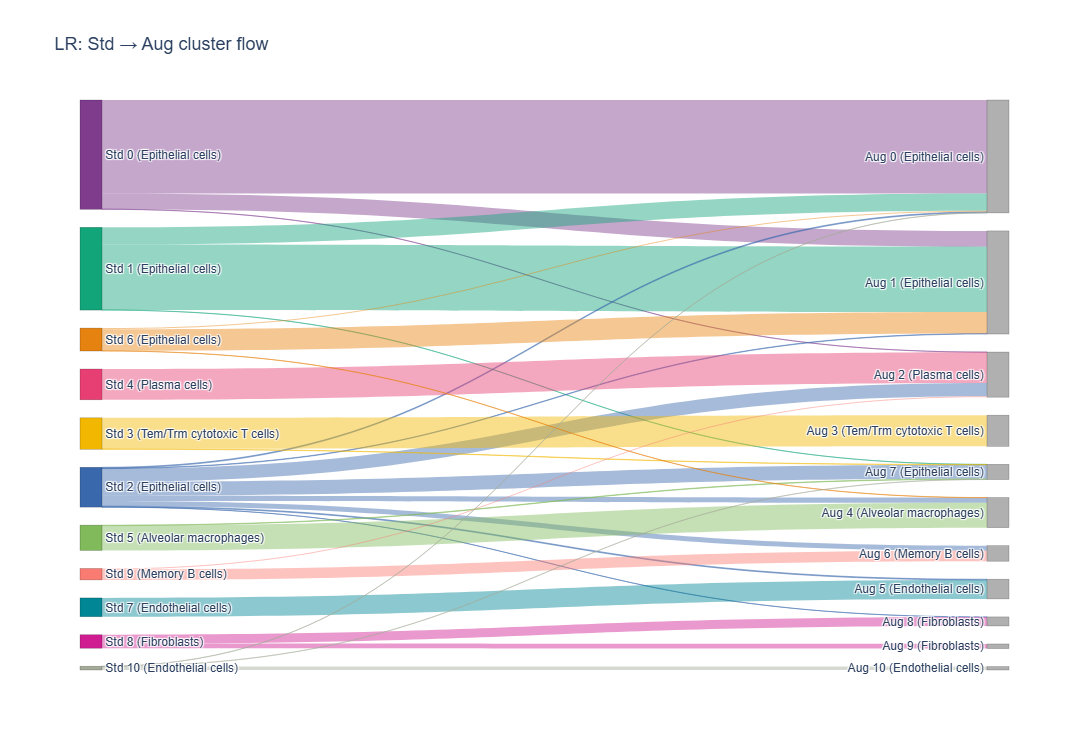

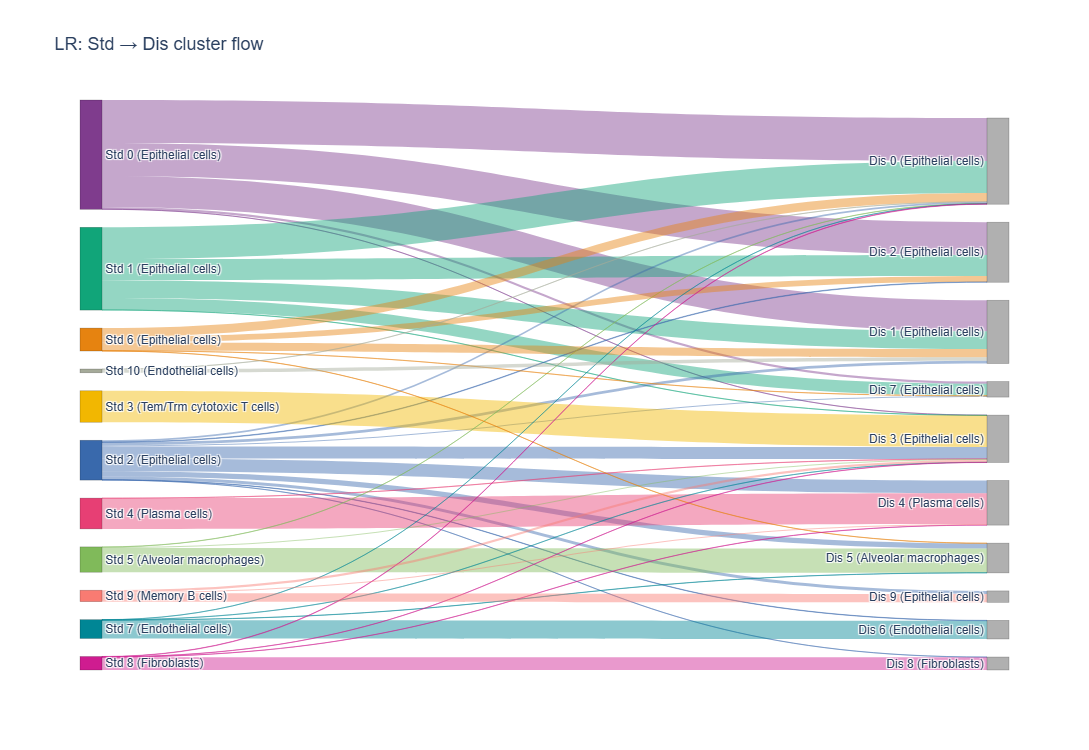

In [11]:
def dominant_celltype_per_cluster(adata, groupby='leiden'):
    return adata.obs.groupby(groupby)['celltypist_label'].agg(lambda x: x.value_counts().idxmax())

def cluster_sizes(adata, groupby='leiden'):
    return adata.obs[groupby].value_counts()

std_celltype_map = dominant_celltype_per_cluster(adatas['LR_Std']).to_dict()
aug_celltype_map = dominant_celltype_per_cluster(adatas['LR_Aug']).to_dict()
dis_celltype_map = dominant_celltype_per_cluster(adatas['LR_Dis']).to_dict()

std_sizes = cluster_sizes(adatas['LR_Std'])
aug_sizes = cluster_sizes(adatas['LR_Aug'])
dis_sizes = cluster_sizes(adatas['LR_Dis'])

print("Std cluster -> dominant CellTypist label (n cells):")
for cl, ct in std_celltype_map.items():
    print(f"  {cl}: {ct}  (n={std_sizes.get(cl, 0)})")

print("\nAug cluster -> dominant CellTypist label (n cells):")
for cl, ct in aug_celltype_map.items():
    print(f"  {cl}: {ct}  (n={aug_sizes.get(cl, 0)})")

print("\nDis cluster -> dominant CellTypist label (n cells):")
for cl, ct in dis_celltype_map.items():
    print(f"  {cl}: {ct}  (n={dis_sizes.get(cl, 0)})")


def build_sankey(labels_a, labels_b, name_a, name_b, title, celltype_map_a=None, celltype_map_b=None):
    df = pd.DataFrame({name_a: labels_a, name_b: labels_b})
    flow = df.groupby([name_a, name_b]).size().reset_index(name='count')

    a_clusters = sorted(df[name_a].unique(), key=lambda x: int(x))
    b_clusters = sorted(df[name_b].unique(), key=lambda x: int(x))

    if celltype_map_a:
        a_labels = [f"{name_a} {c} ({celltype_map_a.get(c, '?')})" for c in a_clusters]
    else:
        a_labels = [f"{name_a} {c}" for c in a_clusters]
    if celltype_map_b:
        b_labels = [f"{name_b} {c} ({celltype_map_b.get(c, '?')})" for c in b_clusters]
    else:
        b_labels = [f"{name_b} {c}" for c in b_clusters]
    all_labels = a_labels + b_labels

    a_idx = {c: i for i, c in enumerate(a_clusters)}
    b_idx = {c: i + len(a_clusters) for i, c in enumerate(b_clusters)}

    palette = px.colors.qualitative.Bold + px.colors.qualitative.Set3 + px.colors.qualitative.Pastel
    node_colors = [palette[i % len(palette)] for i in range(len(a_clusters))] + ['#B0B0B0'] * len(b_clusters)

    def hex_to_rgba(hex_color, alpha=0.45):
        h = hex_color.lstrip('#')
        if len(h) == 6:
            r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
        else:
            nums = hex_color.strip('rgb()').split(',')
            r, g, b = [int(float(n)) for n in nums[:3]]
        return f'rgba({r},{g},{b},{alpha})'

    sources, targets, values, link_colors = [], [], [], []
    for _, row in flow.iterrows():
        src = a_idx[row[name_a]]
        sources.append(src)
        targets.append(b_idx[row[name_b]])
        values.append(row['count'])
        link_colors.append(hex_to_rgba(node_colors[src]))

    fig = go.Figure(data=[go.Sankey(
        arrangement='snap',
        node=dict(pad=18, thickness=22, line=dict(color="rgba(0,0,0,0.3)", width=0.6),
                  label=all_labels, color=node_colors),
        link=dict(source=sources, target=targets, value=values, color=link_colors),
    )])
    fig.update_layout(title=dict(text=title, font=dict(size=18)), font=dict(size=12, family="Arial"),
                       height=750, width=950, paper_bgcolor='white', plot_bgcolor='white')
    return fig


out_dir = '/mnt/md0/jack-gaa/gaa/analysis/sankeys'
os.makedirs(out_dir, exist_ok=True)

fig1 = build_sankey(df_congruence['Std'], df_congruence['Aug'], 'Std', 'Aug', 'LR: Std → Aug cluster flow',
                     celltype_map_a=std_celltype_map, celltype_map_b=aug_celltype_map)
fig1.write_html(f'{out_dir}/lr_sankey_std_vs_aug.html')
fig1.show()

fig2 = build_sankey(df_congruence['Std'], df_congruence['Dis'], 'Std', 'Dis', 'LR: Std → Dis cluster flow',
                     celltype_map_a=std_celltype_map, celltype_map_b=dis_celltype_map)
fig2.write_html(f'{out_dir}/lr_sankey_std_vs_dis.html')
fig2.show()

## Gene-level agreement Augmented vs collapsed-Discovery

62,244 shared gene bins, true raw counts — Spearman ρ=0.731


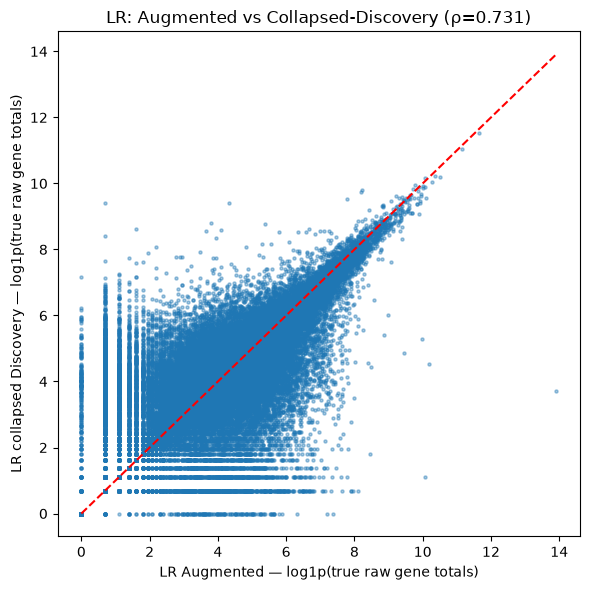

In [12]:
PATH_LR_DIS_RAW = "/mnt/md1/jack-gaa2/wf-single-cell-gaa-discovery-30Jul2026/output/SRR21492157-data/SRR21492157-data.gene_raw_feature_bc_matrix/"

adata_lr_dis_raw_counts = sc.read_10x_mtx(PATH_LR_DIS_RAW, var_names='gene_symbols', cache=True)
adata_lr_dis_raw_counts.var_names = adata_lr_dis_raw_counts.var_names.str.replace('.tsv', '', regex=False)
adata_lr_dis_raw_counts = adata_lr_dis_raw_counts[qc_pass_barcodes].copy()

gene_map_true_raw = build_gene_map(adata_lr_dis_raw_counts)
adata_lr_dis_genelevel_true_raw = collapse_discovery_to_gene_level(adata_lr_dis_raw_counts, gene_map_true_raw)

adata_lr_aug_true_raw = adata_lr_aug_raw_counts[qc_pass_barcodes].copy()

shared_genes = sorted(set(adata_lr_aug_true_raw.var_names) & set(adata_lr_dis_genelevel_true_raw.var_names))
aug_totals = np.asarray(adata_lr_aug_true_raw[:, shared_genes].X.sum(axis=0)).ravel()
dis_totals = np.asarray(adata_lr_dis_genelevel_true_raw[:, shared_genes].X.sum(axis=0)).ravel()

rho, _ = spearmanr(aug_totals, dis_totals)
print(f"{len(shared_genes):,} shared gene bins, true raw counts — Spearman ρ={rho:.3f}")

plt.figure(figsize=(6, 6))
plt.scatter(np.log1p(aug_totals), np.log1p(dis_totals), s=5, alpha=0.4)
lims = [0, max(np.log1p(aug_totals).max(), np.log1p(dis_totals).max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('LR Augmented — log1p(true raw gene totals)')
plt.ylabel('LR collapsed Discovery — log1p(true raw gene totals)')
plt.title(f'LR: Augmented vs Collapsed-Discovery (ρ={rho:.3f})')
plt.tight_layout()
plt.show()

## Genome-wide Std vs Aug vs Dis gene correlation

std vs aug: Spearman ρ=0.934
std vs dis: Spearman ρ=0.859
aug vs dis: Spearman ρ=0.871


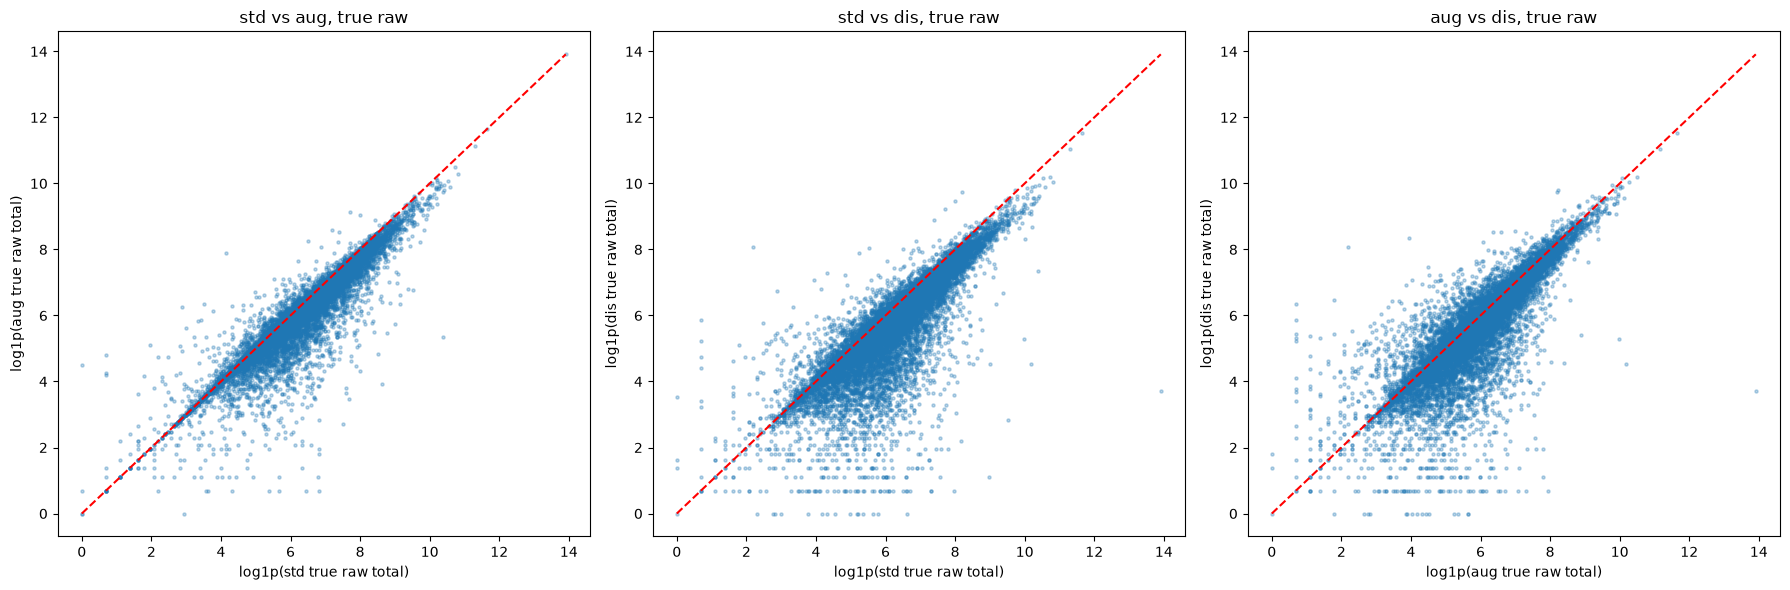

In [13]:
adata_lr_std_true_raw = adata_lr_std_raw_counts[qc_pass_barcodes].copy()

shared_genes_3way = sorted(set(adata_lr_std_true_raw.var_names) & set(adata_lr_dis_genelevel_true_raw.var_names) & set(adata_lr_aug_true_raw.var_names))

std_totals_3way = np.asarray(adata_lr_std_true_raw[:, shared_genes_3way].X.sum(axis=0)).ravel()
aug_totals_3way = np.asarray(adata_lr_aug_true_raw[:, shared_genes_3way].X.sum(axis=0)).ravel()
dis_totals_3way = np.asarray(adata_lr_dis_genelevel_true_raw[:, shared_genes_3way].X.sum(axis=0)).ravel()

three_way_df = pd.DataFrame({'gene': shared_genes_3way, 'std': std_totals_3way, 'aug': aug_totals_3way, 'dis': dis_totals_3way})

pairs_3way = [('std', 'aug'), ('std', 'dis'), ('aug', 'dis')]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (a, b) in zip(axes, pairs_3way):
    rho_3way, _ = spearmanr(three_way_df[a], three_way_df[b])
    print(f"{a} vs {b}: Spearman ρ={rho_3way:.3f}")
    ax.scatter(np.log1p(three_way_df[a]), np.log1p(three_way_df[b]), s=5, alpha=0.3)
    lims = [0, max(np.log1p(three_way_df[a]).max(), np.log1p(three_way_df[b]).max())]
    ax.plot(lims, lims, 'r--')
    ax.set_xlabel(f'log1p({a} true raw total)')
    ax.set_ylabel(f'log1p({b} true raw total)')
    ax.set_title(f'{a} vs {b}, true raw')
plt.tight_layout()
plt.show()

## DIS-native: standalone clustering on the validated gene-level collapse

DIS-native clusters: 9
DIS-native vs Std: ARI=0.434  NMI=0.652
DIS-native vs Aug: ARI=0.356  NMI=0.589
(for reference — raw DIS-peaks-only vs Aug, from the main clustering: ARI=0.373  NMI=0.637)


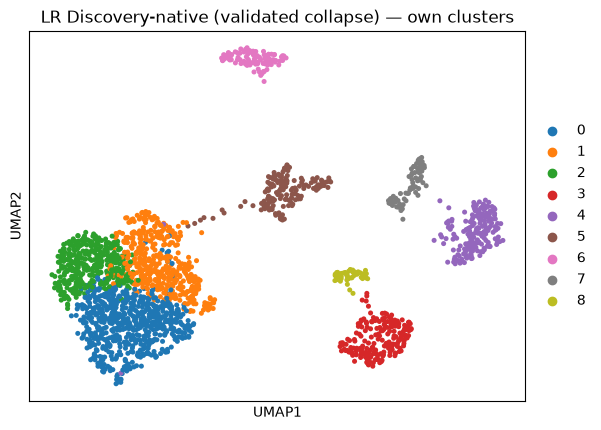

In [14]:
adata_lr_dis_native = adata_lr_dis_genelevel.copy()
sc.pp.highly_variable_genes(adata_lr_dis_native, n_top_genes=3000, flavor='seurat')
sc.tl.pca(adata_lr_dis_native, svd_solver='arpack', random_state=42)
sc.pp.neighbors(adata_lr_dis_native, n_neighbors=15, n_pcs=30, random_state=42)
sc.tl.umap(adata_lr_dis_native, random_state=42)
sc.tl.leiden(adata_lr_dis_native, resolution=0.5, key_added='leiden', random_state=42)
print(f"DIS-native clusters: {adata_lr_dis_native.obs['leiden'].nunique()}")

ari_native_std = adjusted_rand_score(adata_lr_dis_native.obs['leiden'].values, df_congruence['Std'].values)
ari_native_aug = adjusted_rand_score(adata_lr_dis_native.obs['leiden'].values, df_congruence['Aug'].values)
nmi_native_std = normalized_mutual_info_score(adata_lr_dis_native.obs['leiden'].values, df_congruence['Std'].values)
nmi_native_aug = normalized_mutual_info_score(adata_lr_dis_native.obs['leiden'].values, df_congruence['Aug'].values)

print(f"DIS-native vs Std: ARI={ari_native_std:.3f}  NMI={nmi_native_std:.3f}")
print(f"DIS-native vs Aug: ARI={ari_native_aug:.3f}  NMI={nmi_native_aug:.3f}")
print(f"(for reference — raw DIS-peaks-only vs Aug, from the main clustering: "
      f"ARI={congruence_results[('Aug','Dis')]['ari']:.3f}  NMI={congruence_results[('Aug','Dis')]['nmi']:.3f})")

sc.pl.umap(adata_lr_dis_native, color='leiden', title='LR Discovery-native (validated collapse) — own clusters')

## Marker genes: top 15 per cluster, with Wilcoxon scores

In [15]:
for name in LR_CONDITIONS:
    sc.tl.rank_genes_groups(adatas[name], groupby='leiden', method='wilcoxon', key_added='rank_genes_groups')
    sc.tl.rank_genes_groups(adatas[name], groupby='celltypist_label', method='wilcoxon', key_added='rank_genes_groups_celltypist')

def top_n_markers_table(adata, n=15, key='rank_genes_groups'):
    groups = list(adata.uns[key]['names'].dtype.names)
    data = {}
    for g in groups:
        names = adata.uns[key]['names'][g][:n]
        scores = adata.uns[key]['scores'][g][:n]
        data[g] = [f'{nm} ({sc_:.1f})' for nm, sc_ in zip(names, scores)]
    df = pd.DataFrame(data)
    df.index = [f'rank_{i+1}' for i in range(n)]
    return df

for name in LR_CONDITIONS:
    print(f"\n=== {name}: top 15 markers per Leiden cluster (Wilcoxon score) ===")
    display(top_n_markers_table(adatas[name], n=15, key='rank_genes_groups'))
    print(f"\n=== {name}: top 15 markers per CELL TYPE (Wilcoxon score) ===")
    display(top_n_markers_table(adatas[name], n=15, key='rank_genes_groups_celltypist'))


=== LR_Std: top 15 markers per Leiden cluster (Wilcoxon score) ===


,0,1,2,3,4,5,6,7,8,9,10
rank_1,NEBL (20.6),RMST (22.3),CELF2 (10.1),PRKCH (20.1),IGHV1-3 (20.4),SAT1 (18.5),ENSG00000231606 (17.8),FLT1 (17.7),DLC1 (14.4),ARHGAP24 (13.4),LRFN5 (7.8)
rank_2,RUFY3 (19.6),SLC4A4 (22.3),ARHGAP15 (10.1),FYN (20.1),FBXW7 (20.2),ZEB2 (17.6),KAZN-AS1 (17.7),INSR (17.7),LHFPL6 (14.1),RALGPS2 (12.7),ENSG00000285798 (7.7)
rank_3,NIHCOLE (19.5),AUTS2 (21.8),ENSG00000228655 (9.4),SKAP1 (19.8),ST6GAL1 (20.0),DOCK4 (17.0),KAZN (16.9),EGFL7 (17.5),CACNA1C (13.5),PRKCB (12.2),ENSG00000254202 (7.5)
rank_4,ENSG00000287360 (19.1),CDH10 (21.8),PTPRC (9.4),PTPRC (18.7),ANKRD36BP2 (19.9),SRGN (16.8),CNTN1 (16.6),FBXL7 (17.5),CALD1 (13.1),AFF3 (12.0),UNC13C (7.5)
rank_5,SPIRE1 (18.6),CSMD1 (21.7),CYTIP (9.1),CELF2 (18.0),FCRL5 (19.7),CTSB (16.7),PRKG1 (14.4),LDB2 (17.4),IGFBP7 (13.0),ANKRD44 (11.8),COL6A6 (7.3)
rank_6,KCND2 (18.2),TENM3 (21.6),PRKCB (9.1),B2M (17.4),IGHV3-21 (19.7),QKI (16.4),LINC02476 (14.4),GRB10 (17.3),COL4A2 (12.8),CDK14 (11.7),PCDH9 (7.3)
rank_7,MOCOS (17.9),BRCC3 (21.4),DOCK8 (9.0),ANKRD44 (17.3),IGKC (19.4),GNAQ (16.0),ROBO2 (13.6),SPRY1 (17.0),COL5A2 (12.8),ADAM28 (11.7),LINC00383 (7.1)
rank_8,C4orf47 (17.9),ATP8A1 (20.9),ANKRD44 (8.8),MBNL1 (16.9),FNDC3A (19.3),DMXL2 (15.9),PTH2R (13.5),TCF4 (16.9),COL4A1 (12.7),RIPOR2 (11.6),PRKG1 (7.1)
rank_9,ENSG00000253496 (17.8),TEX15 (20.8),TOX (8.6),LINC01934 (15.8),XBP1 (18.9),AOAH (15.9),SLC4A10 (12.7),ANO2 (16.9),VMP1 (12.6),NCOA3 (10.6),ERBB4 (7.0)
rank_10,NR1H4 (17.8),COL23A1 (20.7),CD44 (8.5),TOX (14.9),ELL2 (18.9),ATG7 (15.8),NALCN (12.4),VWF (16.8),PDGFRB (12.6),FCHSD2 (10.5),PDK4 (7.0)



=== LR_Std: top 15 markers per CELL TYPE (Wilcoxon score) ===


,Alveolar macrophages,Classical monocytes,DC,Endothelial cells,Epithelial cells,Fibroblasts,Memory B cells,Plasma cells,Regulatory T cells,Tem/Trm cytotoxic T cells
rank_1,SAT1 (17.0),HLA-DRA (8.0),IL18 (5.1),FLT1 (16.8),KCNIP4 (32.0),DLC1 (14.9),ARHGAP24 (11.8),FBXW7 (22.6),FYN (11.5),PRKCH (14.7)
rank_2,DMXL2 (16.5),SRGN (8.0),ENSG00000227531 (5.1),INSR (16.5),ENSG00000229618 (31.4),LHFPL6 (14.4),AFF3 (11.2),ANKRD36BP2 (22.2),SKAP1 (11.2),TOX (14.4)
rank_3,CTSB (16.5),ETV6 (7.9),RNF144B (5.0),LDB2 (16.2),DNAH11 (31.4),CACNA1C (13.8),RALGPS2 (11.1),FCRL5 (22.2),PRKCH (10.8),FYN (13.7)
rank_4,DOCK4 (16.1),CYRIA (7.7),DMXL2 (5.0),SIPA1L2 (16.1),TENM3 (31.4),COL4A2 (13.3),ADAM28 (10.8),ST6GAL1 (21.7),PHACTR2 (10.7),SKAP1 (13.4)
rank_5,MS4A7 (15.8),CELF2 (7.5),ATG7 (5.0),FBXL7 (16.1),NIHCOLE (31.4),COL5A2 (13.2),PRKCB (10.7),IGHV1-3 (21.5),ST8SIA1 (10.1),PTPRC (12.8)
rank_6,FMNL2 (15.7),GNAQ (7.4),SLC9A9 (4.9),DOCK4 (16.1),ENSG00000251574 (31.3),CALD1 (13.2),CDK14 (10.7),IGHV3-21 (21.4),ITK (10.1),ATXN1 (12.1)
rank_7,ZEB2 (15.6),CD74 (7.3),AOAH (4.9),EGFL7 (16.0),ENSG00000286318 (31.2),PDGFRB (13.0),ANKRD44 (10.1),TENT5C (21.4),LINC01934 (10.1),CELF2 (12.1)
rank_8,FRMD4B (15.5),LYN (7.3),LAIR1 (4.9),MAGI1 (15.9),SLIT2 (31.1),EBF2 (13.0),TCF4 (10.0),XBP1 (21.3),PTPRC (10.1),DOCK8 (12.0)
rank_9,QKI (15.1),SAT1 (7.2),DPYD (4.9),ADAMTS9 (15.9),LRRC7 (31.1),IGFBP7 (12.9),RIPOR2 (9.6),IFNG-AS1 (21.2),MAP3K5 (10.0),HLA-B (11.4)
rank_10,DAPK1 (15.0),RAB31 (7.1),GSAP (4.8),ARL15 (15.9),PCSK6 (31.0),COL4A1 (12.9),PAX5 (9.6),ELL2 (20.5),ANKRD44 (9.9),CBLB (11.4)



=== LR_Aug: top 15 markers per Leiden cluster (Wilcoxon score) ===


...

,Alveolar macrophages,CD16- NK cells,Classical monocytes,Endothelial cells,Epithelial cells,Fibroblasts,Mast cells,Memory B cells,Plasma cells,Regulatory T cells,Tem/Trm cytotoxic T cells
rank_1,SAT1 (16.6),GNLY (5.5),CD74 (7.6),FBXL7 (16.8),KCNIP4 (29.5),DLC1 (14.4),IL1RL1 (3.5),ARHGAP24 (15.3),IGHV1-3 (22.1),PHACTR2 (5.4),TOX (15.3)
rank_2,FMNL2 (15.6),GNLY|antisense_exonic|peak_454554 (5.0),HLA-DRA (7.4),INSR (16.8),TENM3 (28.7),LHFPL6 (14.3),HDC (3.5),AFF3 (13.7),FCRL5 (21.7),B2M (5.2),FYN (14.2)
rank_3,DOCK4 (15.3),KLRC1 (5.0),CYRIA (7.4),FLT1 (16.6),ENSG00000250243|antisense_intronic|peak_510346...,CACNA1C (13.6),ENSG00000240521 (3.5),PRKCB (12.9),XBP1 (21.6),ENSG00000227240 (5.1),PRKCH (14.1)
rank_4,FRMD4B (14.9),PRKCH (4.8),RAB31 (7.3),LDB2 (16.4),ENSG00000229618 (28.6),COL5A2 (13.0),ENSG00000243797 (3.5),CDK14 (12.7),IGHV1-2 (21.5),ICOS (5.1),SKAP1 (13.4)
rank_5,ZEB2 (14.5),ATP8B4 (4.6),ETV6 (7.3),EGFL7 (15.8),SLIT2 (28.4),CCDC102B (13.0),MS4A2 (3.5),RIPOR2 (12.6),ANKRD36BP2 (20.7),FYN (4.9),PTPRC (12.5)
rank_6,DMXL2 (14.3),KLRC3 (4.4),DOCK10 (7.3),SIPA1L2 (15.8),PCSK6 (28.1),VMP1 (12.6),HPGD (3.5),ANKRD44 (12.4),IGHJ3 (20.6),HLA-B (4.7),CELF2 (11.8)
rank_7,MS4A7 (14.3),CTSW (4.4),DOCK2 (7.2),DOCK4 (15.7),NDRG1 (28.0),PDGFRB (12.6),TPSB2 (3.5),RALGPS2 (12.1),IFNG-AS1 (20.4),STK17B (4.7),ANKRD44 (11.7)
rank_8,QKI (14.3),TXK (4.2),SRGN (7.2),MAGI1 (15.5),ENSG00000251574 (27.9),EBF2 (12.6),RGS13 (3.5),WDFY4 (11.4),IGKC (20.2),SAMSN1 (4.7),ITGAE (11.5)
rank_9,ATG7 (14.0),TRG-AS1 (4.0),CD86 (7.1),VWF (15.5),LRRC7 (27.7),COL4A1 (12.5),GRAP2 (3.4),RALGPS2-AS1|antisense_exonic|peak_21671 (11.3),PIM2 (20.1),SKAP1 (4.6),HLA-B (11.4)
rank_10,NPL (14.0),CCL5 (4.0),CELF2 (7.1),ARL15 (15.4),NLGN1 (27.7),COL4A2 (12.4),ENSG00000285534 (3.4),BLK (11.2),ELL2 (19.6),LTB (4.5),HLA-C (11.2)



=== LR_Dis: top 15 markers per Leiden cluster (Wilcoxon score) ===


,0,1,2,3,4,5,6,7,8,9
rank_1,VEGFA|known_exon|peak_246069 (14.9),PDK4-AS1|antisense_intronic|peak_567224 (28.8),GPAT4|antisense_intronic|peak_579373 (25.9),B2M|known_exon|peak_96718 (17.8),IGHV1-2|known_exon|peak_396812 (23.1),SAT1|known_exon|peak_296782 (20.7),EGFL7|known_exon|peak_295028 (17.4),ERBB4|antisense_intronic|peak_164654 (15.0),PDGFRB|known_exon|peak_543115 (12.1),ARHGAP24|known_transcript_intronic|peak_213202...
rank_2,NDRG1|antisense_intronic|peak_285674 (13.6),PDK4-AS1|antisense_intronic|peak_567241 (26.2),GPAT4|antisense_intronic|peak_579369 (18.1),IGKV3-20|known_exon|peak_455080 (16.0),IGHG1|known_exon|peak_396773 (23.0),SAT1|antisense_exonic|peak_602517 (19.4),SPRY1|known_exon|peak_216704 (16.7),ERBB4|known_transcript_intronic|peak_467554 (1...,VMP1|known_exon|peak_123047 (11.3),IGLV3-19|known_exon|peak_179329 (8.7)
rank_3,intergenic|intergenic|peak_303779 (11.0),PDK4-AS1|antisense_intronic|peak_567237 (21.5),GPAT4|antisense_intronic|peak_579359 (15.1),HLA-B|known_exon|peak_548224 (15.7),IGKV3-20|known_exon|peak_455080 (21.8),GLUL|known_exon|peak_324929 (15.7),FLT1|known_exon|peak_378684 (16.7),ERBB4|antisense_intronic|peak_164621 (14.8),VMP1|known_exon|peak_123036 (11.1),intergenic|intergenic|peak_291153 (8.5)
rank_4,ENSG00000289316|known_exon|peak_590132 (10.7),ENSG00000287733|extended_exon|peak_268869 (15.4),near:ENSG00000229370:4523bp|intergenic|peak_44...,HLA-A|known_exon|peak_244156 (14.7),XBP1|extended_exon|peak_483558 (20.0),MS4A7|known_exon|peak_50853 (14.6),MCPH1|antisense_intronic|peak_576434 (16.0),ERBB4|known_transcript_intronic|peak_467549 (1...,ADAMTS4|known_exon|peak_322710 (10.3),IGLV3-21|known_exon|peak_179327 (8.4)
rank_5,KAZN|known_transcript_intronic|peak_2617 (10.6),PDK4|antisense_intronic|peak_263585 (15.0),ENSG00000251294|antisense_intronic|peak_527817...,HLA-C|known_exon|peak_548214 (14.0),XBP1|known_exon|peak_483543 (18.2),CTSB|known_exon|peak_576726 (14.1),FLT1|antisense_intronic|peak_76819 (15.8),ERBB4|known_transcript_intronic|peak_467385 (1...,near:CCDC102B:17980bp|intergenic|peak_133110 (...,CD74|known_exon|peak_543117 (8.1)
rank_6,intergenic|intergenic|peak_303780 (10.5),UBE2D2|antisense_intronic|peak_541473 (14.7),near:ENSG00000229370:23011bp|intergenic|peak_1...,ENSG00000269968|antisense_exonic|peak_60559 (1...,ST6GAL1|known_transcript_intronic|peak_202083 ...,MS4A6A|known_exon|peak_354317 (13.9),STC1|known_exon|peak_578177 (15.5),ERBB4|antisense_intronic|peak_164644 (12.7),CCDC102B|known_exon|peak_133081 (10.0),ENSG00000241666|antisense_exonic|peak_19756 (7.4)
rank_7,HMGN3|known_exon|peak_551286 (10.4),near:ENSG00000287733:1802bp|intergenic|peak_26...,EGLN3|known_transcript_intronic|peak_388569 (1...,TMSB4X|known_exon|peak_296020 (11.9),PIM2|known_exon|peak_603545 (16.8),CTSB|antisense_intronic|peak_272435 (13.9),IVNS1ABP|known_exon|peak_325348 (15.2),ERBB4|antisense_intronic|peak_164698 (12.3),VMP1|antisense_exonic|peak_425500 (9.7),intergenic|intergenic|peak_291201 (7.3)
rank_8,ENO2|known_exon|peak_60711 (10.3),ENSG00000223786|known_transcript_intronic|peak...,BRCC3|antisense_intronic|peak_609535 (11.9),ENSG00000261573|antisense_intronic|peak_23801 ...,ANKRD36BP2|known_exon|peak_152465 (16.6),ENSG00000259678|antisense_intronic|peak_399938...,INSR|antisense_exonic|peak_135280 (15.2),ERBB4|antisense_intronic|peak_164640 (12.1),LHFPL6|known_transcript_intronic|peak_380083 (...,BCL11A|known_transcript_intronic|peak_451223 (...
rank_9,near:LINC02041:40273bp|intergenic|peak_202378 ...,LINC00504|antisense_intronic|peak_205666 (13.2),LINC02268|known_transcript_intronic|peak_52465...,IGHG1|known_exon|peak_396773 (11.7),PIM2|antisense_intronic|peak_297945 (16.1),MS4A6A|known_exon|peak_354304 (13.4),FLT1|antisense_intronic|peak_76814 (15.1),ERBB4|antisense_intronic|peak_164686 (10.1),GEM|known_transcript_intronic|peak_584369 (9.1),IGKV3-20|known_exon|peak_455080 (6.7)
rank_10,FAM13A|known_exon|peak_517408 (10.1),NEAT1|known_exon|peak_51893 (12.8),LINC01320|antisense_exonic|peak_448290


=== LR_Dis: top 15 markers per CELL TYPE (Wilcoxon score) ===


,Alveolar macrophages,Endothelial cells,Epithelial cells,Fibroblasts,Plasma cells
rank_1,SAT1|known_exon|peak_296782 (18.8),EGFL7|known_exon|peak_295028 (17.8),near:ENSG00000229370:4523bp|intergenic|peak_44...,PDGFRB|known_exon|peak_543115 (12.2),IGHV1-2|known_exon|peak_396812 (21.2)
rank_2,SAT1|antisense_exonic|peak_602517 (17.9),SPRY1|known_exon|peak_216704 (17.1),VEGFA|known_exon|peak_246069 (21.3),VMP1|known_exon|peak_123047 (11.0),IGHG1|known_exon|peak_396773 (21.2)
rank_3,GLUL|known_exon|peak_324929 (14.3),FLT1|known_exon|peak_378684 (17.1),NDRG1|antisense_intronic|peak_285674 (20.8),VMP1|known_exon|peak_123036 (10.3),IGKV3-20|known_exon|peak_455080 (19.8)
rank_4,MS4A7|known_exon|peak_50853 (13.3),FLT1|antisense_intronic|peak_76819 (16.0),near:ENSG00000229370:23011bp|intergenic|peak_1...,ADAMTS4|known_exon|peak_322710 (9.9),XBP1|extended_exon|peak_483558 (18.2)
rank_5,CTSL|known_exon|peak_291494 (13.3),MCPH1|antisense_intronic|peak_576434 (15.9),ENSG00000287733|extended_exon|peak_268869 (20.3),CCDC102B|known_exon|peak_133081 (9.7),XBP1|known_exon|peak_483543 (16.8)
rank_6,CTSB|known_exon|peak_576726 (13.2),STC1|known_exon|peak_578177 (15.9),UBE2D2|antisense_intronic|peak_541473 (19.8),near:CCDC102B:17980bp|intergenic|peak_133110 (...,ST6GAL1|known_transcript_intronic|peak_202083 ...
rank_7,ENSG00000259678|antisense_intronic|peak_399938...,INSR|antisense_exonic|peak_135280 (15.5),HMGN3|known_exon|peak_551286 (19.5),VMP1|antisense_exonic|peak_425500 (9.5),PIM2|known_exon|peak_603545 (15.6)
rank_8,FTL|known_exon|peak_140887 (12.5),FLT1|antisense_intronic|peak_76814 (15.4),KAZN|known_transcript_intronic|peak_2617 (19.5),COL3A1|known_exon|peak_161993 (8.7),TXNIP|known_exon|peak_320019 (15.5)
rank_9,CTSB|antisense_intronic|peak_272435 (12.3),FLT1|known_transcript_intronic|peak_378658 (15.4),near:LINC02041:40273bp|intergenic|peak_202378 ...,CALD1|known_exon|peak_268755 (8.7),BTG2|known_exon|peak_24350 (15.3)
rank_10,PSAP|known_exon|peak_340217 (12.2),SPARCL1|antisense_intronic|peak_213623 (15.2),NDRG1|known_transcript_intronic|peak_590232 (1...,GEM|known_transcript_intronic|peak_584369 (8.6),PIM2|antisense_intronic|peak_297945 (15.3)


## Top 15 novel-peak markers per cluster

In [16]:
def top_n_peak_markers_table(adata, n=15, key='rank_genes_groups'):
    groups = list(adata.uns[key]['names'].dtype.names)
    data = {}
    for g in groups:
        all_names = adata.uns[key]['names'][g]
        all_scores = adata.uns[key]['scores'][g]
        pairs = [(nm, sc_) for nm, sc_ in zip(all_names, all_scores) if '|' in nm][:n]
        entries = [f'{nm} ({sc_:.1f})' for nm, sc_ in pairs]
        entries += [None] * (n - len(entries))
        data[g] = entries
    df = pd.DataFrame(data)
    df.index = [f'rank_{i+1}' for i in range(n)]
    return df

for name in ['LR_Aug', 'LR_Dis']:
    print(f"\n=== {name}: top 15 novel-peak markers per Leiden cluster (Wilcoxon score) ===")
    display(top_n_peak_markers_table(adatas[name], n=15, key='rank_genes_groups'))
    print(f"\n=== {name}: top 15 novel-peak markers per CELL TYPE (Wilcoxon score) ===")
    display(top_n_peak_markers_table(adatas[name], n=15, key='rank_genes_groups_celltypist'))


=== LR_Aug: top 15 novel-peak markers per Leiden cluster (Wilcoxon score) ===


,0,1,2,3,4,5,6,7,8,9,10
rank_1,CCDC110|antisense_intronic|peak_222652 (16.0),intergenic|intergenic|peak_303779 (23.3),ST6GAL1|antisense_intronic|peak_505053 (18.9),ENSG00000269968|antisense_exonic|peak_60559 (1...,ZEB2-AS1|antisense_exonic|peak_459554 (14.5),SPARCL1|antisense_intronic|peak_213623 (14.7),RALGPS2-AS1|antisense_exonic|peak_21671 (10.5),ENSG00000240497|antisense_intronic|peak_502764...,MYO1B-AS1|antisense_intronic|peak_162475 (10.1),POLR2B|antisense_exonic|peak_514055 (7.2),ENSG00000285798|antisense_intronic|peak_196705...
rank_2,ENSG00000250243|antisense_intronic|peak_510346...,intergenic|intergenic|peak_303780 (22.5),ENSG00000275202|antisense_exonic|peak_79038 (1...,near:MT-ND1:1471bp|intergenic|peak_295315 (9.4),CTSB|antisense_intronic|peak_272435 (13.3),CALCRL-AS1|antisense_intronic|peak_464809 (14.4),ARHGAP24|antisense_intronic|peak_516591 (8.7),SKAP1-AS2|antisense_intronic|peak_424375 (5.2),near:CCDC102B:17980bp|intergenic|peak_133110 (...,ENSG00000285090|antisense_intronic|peak_263413...,LINC02046|antisense_exonic|peak_500301 (7.1)
rank_3,HMGN3-AS1|antisense_exonic|peak_551355 (14.9),near:ENSG00000229370:4523bp|intergenic|peak_44...,BMP6|antisense_exonic|peak_546612 (15.0),PTPRC|antisense_intronic|peak_326446 (8.0),HIF1A-AS3|antisense_intronic|peak_88776 (12.5),ENSG00000254631|antisense_intronic|peak_357166...,ENSG00000241666|antisense_exonic|peak_19756 (8.5),near:SLFN12L:1203bp|intergenic|peak_421458 (5.1),ENSG00000253811|antisense_exonic|peak_543805 (...,near:PTCH2:606bp|intergenic|peak_311018 (5.2),near:ENSG00000254202:717bp|intergenic|peak_278...
rank_4,NDRG1|antisense_intronic|peak_285674 (14.7),intergenic|intergenic|peak_303775 (19.4),ENSG00000287555|antisense_intronic|peak_522769...,near:MT-ND1:2506bp|intergenic|peak_295313 (7.3),SRGN|antisense_intronic|peak_339991 (11.2),ENSG00000238258|antisense_intronic|peak_336013...,FCRL1|antisense_intronic|peak_18893 (8.2),LTO1|antisense_exonic|peak_53183 (5.0),ZEB2-AS1|antisense_exonic|peak_459554 (8.6),IGFBP7-AS1|antisense_exonic|peak_514175 (5.0),near:RHEX:1172bp|intergenic|peak_24709 (6.5)
rank_5,near:NEK7:49200bp|intergenic|peak_23628 (14.7),ENSG00000250243|antisense_intronic|peak_510346...,NDUFAF6|antisense_intronic|peak_584551 (12.7),near:CD96:171bp|intergenic|peak_192218 (7.2),ENSG00000226334|antisense_intronic|peak_598075...,A2M-AS1|antisense_exonic|peak_363546 (13.4),intergenic|intergenic|peak_596512 (6.9),STK4-DT|antisense_intronic|peak_172866 (4.7),HTR1F|antisense_intronic|peak_493842 (8.4),IGFBP7|antisense_intronic|peak_210792 (4.7),PIK3R4|antisense_intronic|peak_194880 (6.5)
rank_6,near:HILPDA:3717bp|intergenic|peak_571645 (14.2),ENSG00000251294|antisense_intronic|peak_527817...,RALGPS2-AS1|antisense_exonic|peak_21671 (12.5),near:SLFN12L:1203bp|intergenic|peak_421458 (6.9),CARMIL1|antisense_intronic|peak_547648 (10.3),MCPH1|antisense_intronic|peak_576434 (13.3),CEPT1|antisense_exonic|peak_318415 (5.7),TENM3-AS1|antisense_intronic|peak_221295 (4.6),near:EBF1:41bp|intergenic|peak_543869 (8.4),ENSG00000238258|antisense_intronic|peak_336013...,PDK4-AS1|antisense_intronic|peak_567224 (6.3)
rank_7,CDCA7L|antisense_exonic|peak_256297 (13.2),FAM13A-AS1|antisense_exonic|peak_517185 (16.5),FBXW7|antisense_intronic|peak_218914 (11.0),ENSG00000228655|antisense_intronic|peak_156828...,near:SPRED1:409bp|intergenic|peak_95596 (9.8),ADGRF5-AS1|antisense_intronic|peak_550057 (12.8),intergenic|intergenic|peak_291250 (5.5),NLGN1|antisense_intronic|peak_503588 (4.6),IGFBP7|antisense_intronic|peak_210769 (8.3),RBMS3-AS2|antisense_intronic|peak_185986 (3.7),NNMT|antisense_intronic|peak_360815 (6.2)
rank_8,EGFR-AS1|antisense_exonic|peak_259754 (13.2),BRCC3|antisense_intronic|peak_609532 (16.4),near:PDK1:5745bp|intergenic|peak_160178 (10.9),CCL3L3|antisense_exonic|peak_119324 (6.5),DEPP1|antisense_intronic|peak_33864 (9.7),PLPP1|antisense_intronic|peak_226954 (12.7),ENSG00000269968|antisense_exonic|peak_60559 (5.4),near:ENSG00000229370:4523bp|intergenic|peak_44...,ENSG00


=== LR_Aug: top 15 novel-peak markers per CELL TYPE (Wilcoxon score) ===


,Alveolar macrophages,CD16- NK cells,Classical monocytes,Endothelial cells,Epithelial cells,Fibroblasts,Mast cells,Memory B cells,Plasma cells,Regulatory T cells,Tem/Trm cytotoxic T cells
rank_1,ZEB2-AS1|antisense_exonic|peak_459554 (12.4),GNLY|antisense_exonic|peak_454554 (5.0),SRGN|antisense_intronic|peak_339991 (7.0),SPARCL1|antisense_intronic|peak_213623 (13.1),ENSG00000250243|antisense_intronic|peak_510346...,POLR2B|antisense_exonic|peak_514055 (10.8),A2M-AS1|antisense_exonic|peak_363546 (3.3),RALGPS2-AS1|antisense_exonic|peak_21671 (11.3),ST6GAL1|antisense_intronic|peak_505053 (18.4),ENSG00000269968|antisense_exonic|peak_60559 (3.9),ENSG00000269968|antisense_exonic|peak_60559 (9.7)
rank_2,CTSB|antisense_intronic|peak_272435 (11.1),PTPRC|antisense_intronic|peak_326446 (2.9),CARMIL1|antisense_intronic|peak_547648 (5.3),CALCRL-AS1|antisense_intronic|peak_464809 (13.0),near:ENSG00000229370:4523bp|intergenic|peak_44...,near:CCDC102B:17980bp|intergenic|peak_133110 (...,ENSG00000240497|antisense_intronic|peak_502764...,ENSG00000241666|antisense_exonic|peak_19756 (9.5),ENSG00000275202|antisense_exonic|peak_79038 (1...,CYTOR|antisense_intronic|peak_454803 (3.4),CCL3L3|antisense_exonic|peak_119324 (8.3)
rank_3,ENSG00000226334|antisense_intronic|peak_598075...,RFTN1|antisense_intronic|peak_185116 (2.6),HIF1A-AS3|antisense_intronic|peak_88776 (5.0),ENSG00000254631|antisense_intronic|peak_357166...,NDRG1|antisense_intronic|peak_285674 (24.7),IGFBP7-AS1|antisense_exonic|peak_514175 (9.4),PRH1|antisense_intronic|peak_61248 (2.9),ARHGAP24|antisense_intronic|peak_516591 (9.0),BMP6|antisense_exonic|peak_546612 (14.7),near:MT-ND1:1471bp|intergenic|peak_295315 (3.1),PRKCH-AS1|antisense_intronic|peak_88617 (6.9)
rank_4,HIF1A-AS3|antisense_intronic|peak_88776 (10.2),DOCK8-AS2|antisense_intronic|peak_287006 (2.5),RNF149|antisense_exonic|peak_153480 (4.9),A2M-AS1|antisense_exonic|peak_363546 (12.2),FAM13A-AS1|antisense_exonic|peak_517185 (24.5),IGFBP7|antisense_intronic|peak_210769 (8.8),MED12L|antisense_intronic|peak_500838 (2.6),FCRL1|antisense_intronic|peak_18893 (8.4),ENSG00000287555|antisense_intronic|peak_522769...,INKA2|antisense_exonic|peak_15668 (2.9),near:SLFN12L:1203bp|intergenic|peak_421458 (6.5)
rank_5,ZNF331|antisense_intronic|peak_444068 (8.6),BCL2|antisense_intronic|peak_132841 (2.5),UVRAG-DT|antisense_exonic|peak_54217 (4.7),near:PLPP3:1375bp|intergenic|peak_312805 (12.2),HMGN3-AS1|antisense_exonic|peak_551355 (24.5),MYO1B-AS1|antisense_intronic|peak_162475 (8.7),ENSG00000259813|antisense_exonic|peak_417665 (...,intergenic|intergenic|peak_596512 (7.3),RALGPS2-AS1|antisense_exonic|peak_21671 (12.0),ENSG00000241666|antisense_exonic|peak_19756 (2.5),near:MT-ND1:1471bp|intergenic|peak_295315 (6.1)
rank_6,near:SPRED1:409bp|intergenic|peak_95596 (8.5),near:TXK:144bp|intergenic|peak_513285 (2.3),ETV6|antisense_exonic|peak_364422 (4.3),ENSG00000238258|antisense_intronic|peak_336013...,ENSG00000230233|antisense_intronic|peak_478393...,ENSG00000253811|antisense_exonic|peak_543805 (...,ENSG00000260891|antisense_intronic|peak_112543...,CEPT1|antisense_exonic|peak_318415 (6.1),NDUFAF6|antisense_intronic|peak_584551 (11.9),SKAP1|antisense_intronic|peak_121720 (2.5),PTPRC|antisense_intronic|peak_326446 (5.9)
rank_7,DEPP1|antisense_intronic|peak_33864 (8.3),ENSG00000269968|antisense_exonic|peak_60559 (2.3),RAB31|antisense_intronic|peak_430646 (4.3),MCPH1|antisense_intronic|peak_576434 (11.7),TMEM140|antisense_exonic|peak_573071 (23.0),IGFBP7|antisense_intronic|peak_210792 (8.4),BIRC6|antisense_intronic|peak_448070 (2.5),intergenic|intergenic|peak_291250 (6.0),near:PDK1:5745bp|intergenic|peak_160178 (10.9),RHOH|antisense_intronic|peak_512502 (2.3),near:CD96:171bp|intergenic|peak_192218 (5.6)
rank_8,ENSG00000238258|antisense_intronic|peak_336013...,near:PTGDR:1776bp|intergenic|peak_87450 (2.3),FAM72A|antisense_intronic|peak_24740 (3.9),ADGRF5-AS1|antisense_intronic|peak_550057 (11.4),CDCA7L|antisense_exonic|peak_256297 (22.6),ZEB2-AS1|antisense_


=== LR_Dis: top 15 novel-peak markers per Leiden cluster (Wilcoxon score) ===


,0,1,2,3,4,5,6,7,8,9
rank_1,VEGFA|known_exon|peak_246069 (14.9),PDK4-AS1|antisense_intronic|peak_567224 (28.8),GPAT4|antisense_intronic|peak_579373 (25.9),B2M|known_exon|peak_96718 (17.8),IGHV1-2|known_exon|peak_396812 (23.1),SAT1|known_exon|peak_296782 (20.7),EGFL7|known_exon|peak_295028 (17.4),ERBB4|antisense_intronic|peak_164654 (15.0),PDGFRB|known_exon|peak_543115 (12.1),ARHGAP24|known_transcript_intronic|peak_213202...
rank_2,NDRG1|antisense_intronic|peak_285674 (13.6),PDK4-AS1|antisense_intronic|peak_567241 (26.2),GPAT4|antisense_intronic|peak_579369 (18.1),IGKV3-20|known_exon|peak_455080 (16.0),IGHG1|known_exon|peak_396773 (23.0),SAT1|antisense_exonic|peak_602517 (19.4),SPRY1|known_exon|peak_216704 (16.7),ERBB4|known_transcript_intronic|peak_467554 (1...,VMP1|known_exon|peak_123047 (11.3),IGLV3-19|known_exon|peak_179329 (8.7)
rank_3,intergenic|intergenic|peak_303779 (11.0),PDK4-AS1|antisense_intronic|peak_567237 (21.5),GPAT4|antisense_intronic|peak_579359 (15.1),HLA-B|known_exon|peak_548224 (15.7),IGKV3-20|known_exon|peak_455080 (21.8),GLUL|known_exon|peak_324929 (15.7),FLT1|known_exon|peak_378684 (16.7),ERBB4|antisense_intronic|peak_164621 (14.8),VMP1|known_exon|peak_123036 (11.1),intergenic|intergenic|peak_291153 (8.5)
rank_4,ENSG00000289316|known_exon|peak_590132 (10.7),ENSG00000287733|extended_exon|peak_268869 (15.4),near:ENSG00000229370:4523bp|intergenic|peak_44...,HLA-A|known_exon|peak_244156 (14.7),XBP1|extended_exon|peak_483558 (20.0),MS4A7|known_exon|peak_50853 (14.6),MCPH1|antisense_intronic|peak_576434 (16.0),ERBB4|known_transcript_intronic|peak_467549 (1...,ADAMTS4|known_exon|peak_322710 (10.3),IGLV3-21|known_exon|peak_179327 (8.4)
rank_5,KAZN|known_transcript_intronic|peak_2617 (10.6),PDK4|antisense_intronic|peak_263585 (15.0),ENSG00000251294|antisense_intronic|peak_527817...,HLA-C|known_exon|peak_548214 (14.0),XBP1|known_exon|peak_483543 (18.2),CTSB|known_exon|peak_576726 (14.1),FLT1|antisense_intronic|peak_76819 (15.8),ERBB4|known_transcript_intronic|peak_467385 (1...,near:CCDC102B:17980bp|intergenic|peak_133110 (...,CD74|known_exon|peak_543117 (8.1)
rank_6,intergenic|intergenic|peak_303780 (10.5),UBE2D2|antisense_intronic|peak_541473 (14.7),near:ENSG00000229370:23011bp|intergenic|peak_1...,ENSG00000269968|antisense_exonic|peak_60559 (1...,ST6GAL1|known_transcript_intronic|peak_202083 ...,MS4A6A|known_exon|peak_354317 (13.9),STC1|known_exon|peak_578177 (15.5),ERBB4|antisense_intronic|peak_164644 (12.7),CCDC102B|known_exon|peak_133081 (10.0),ENSG00000241666|antisense_exonic|peak_19756 (7.4)
rank_7,HMGN3|known_exon|peak_551286 (10.4),near:ENSG00000287733:1802bp|intergenic|peak_26...,EGLN3|known_transcript_intronic|peak_388569 (1...,TMSB4X|known_exon|peak_296020 (11.9),PIM2|known_exon|peak_603545 (16.8),CTSB|antisense_intronic|peak_272435 (13.9),IVNS1ABP|known_exon|peak_325348 (15.2),ERBB4|antisense_intronic|peak_164698 (12.3),VMP1|antisense_exonic|peak_425500 (9.7),intergenic|intergenic|peak_291201 (7.3)
rank_8,ENO2|known_exon|peak_60711 (10.3),ENSG00000223786|known_transcript_intronic|peak...,BRCC3|antisense_intronic|peak_609535 (11.9),ENSG00000261573|antisense_intronic|peak_23801 ...,ANKRD36BP2|known_exon|peak_152465 (16.6),ENSG00000259678|antisense_intronic|peak_399938...,INSR|antisense_exonic|peak_135280 (15.2),ERBB4|antisense_intronic|peak_164640 (12.1),LHFPL6|known_transcript_intronic|peak_380083 (...,BCL11A|known_transcript_intronic|peak_451223 (...
rank_9,near:LINC02041:40273bp|intergenic|peak_202378 ...,LINC00504|antisense_intronic|peak_205666 (13.2),LINC02268|known_transcript_intronic|peak_52465...,IGHG1|known_exon|peak_396773 (11.7),PIM2|antisense_intronic|peak_297945 (16.1),MS4A6A|known_exon|peak_354304 (13.4),FLT1|antisense_intronic|peak_76814 (15.1),ERBB4|antisense_intronic|peak_164686 (10.1),GEM|known_transcript_intronic|peak_584369 (9.1),IGKV3-20|known_exon|peak_455080 (6.7)
rank_10,FAM13A|known_exon|peak_517408 (10.1),NEAT1|known_exon|peak_51893 (12.8),LINC01320|antisense_exonic|peak_448290


=== LR_Dis: top 15 novel-peak markers per CELL TYPE (Wilcoxon score) ===


,Alveolar macrophages,Endothelial cells,Epithelial cells,Fibroblasts,Plasma cells
rank_1,SAT1|known_exon|peak_296782 (18.8),EGFL7|known_exon|peak_295028 (17.8),near:ENSG00000229370:4523bp|intergenic|peak_44...,PDGFRB|known_exon|peak_543115 (12.2),IGHV1-2|known_exon|peak_396812 (21.2)
rank_2,SAT1|antisense_exonic|peak_602517 (17.9),SPRY1|known_exon|peak_216704 (17.1),VEGFA|known_exon|peak_246069 (21.3),VMP1|known_exon|peak_123047 (11.0),IGHG1|known_exon|peak_396773 (21.2)
rank_3,GLUL|known_exon|peak_324929 (14.3),FLT1|known_exon|peak_378684 (17.1),NDRG1|antisense_intronic|peak_285674 (20.8),VMP1|known_exon|peak_123036 (10.3),IGKV3-20|known_exon|peak_455080 (19.8)
rank_4,MS4A7|known_exon|peak_50853 (13.3),FLT1|antisense_intronic|peak_76819 (16.0),near:ENSG00000229370:23011bp|intergenic|peak_1...,ADAMTS4|known_exon|peak_322710 (9.9),XBP1|extended_exon|peak_483558 (18.2)
rank_5,CTSL|known_exon|peak_291494 (13.3),MCPH1|antisense_intronic|peak_576434 (15.9),ENSG00000287733|extended_exon|peak_268869 (20.3),CCDC102B|known_exon|peak_133081 (9.7),XBP1|known_exon|peak_483543 (16.8)
rank_6,CTSB|known_exon|peak_576726 (13.2),STC1|known_exon|peak_578177 (15.9),UBE2D2|antisense_intronic|peak_541473 (19.8),near:CCDC102B:17980bp|intergenic|peak_133110 (...,ST6GAL1|known_transcript_intronic|peak_202083 ...
rank_7,ENSG00000259678|antisense_intronic|peak_399938...,INSR|antisense_exonic|peak_135280 (15.5),HMGN3|known_exon|peak_551286 (19.5),VMP1|antisense_exonic|peak_425500 (9.5),PIM2|known_exon|peak_603545 (15.6)
rank_8,FTL|known_exon|peak_140887 (12.5),FLT1|antisense_intronic|peak_76814 (15.4),KAZN|known_transcript_intronic|peak_2617 (19.5),COL3A1|known_exon|peak_161993 (8.7),TXNIP|known_exon|peak_320019 (15.5)
rank_9,CTSB|antisense_intronic|peak_272435 (12.3),FLT1|known_transcript_intronic|peak_378658 (15.4),near:LINC02041:40273bp|intergenic|peak_202378 ...,CALD1|known_exon|peak_268755 (8.7),BTG2|known_exon|peak_24350 (15.3)
rank_10,PSAP|known_exon|peak_340217 (12.2),SPARCL1|antisense_intronic|peak_213623 (15.2),NDRG1|known_transcript_intronic|peak_590232 (1...,GEM|known_transcript_intronic|peak_584369 (8.6),PIM2|antisense_intronic|peak_297945 (15.3)


## Flattened peak-marker ranking table

In [17]:
def build_peak_marker_ranking_table(adata, name, top_n_per_cluster=15, key='rank_genes_groups'):
    groups = list(adata.uns[key]['names'].dtype.names)
    rows = []
    for g in groups:
        names = adata.uns[key]['names'][g]
        scores = adata.uns[key]['scores'][g]
        lfcs = adata.uns[key]['logfoldchanges'][g]
        padjs = adata.uns[key]['pvals_adj'][g]
        all_entries = list(zip(names, scores, lfcs, padjs))[:top_n_per_cluster]
        for nm, sc_, lfc, padj in all_entries:
            if '|' in nm:
                context, classification, peak_id = parse_discovery_id(nm)
            else:
                context, classification, peak_id = nm, 'reference_gene', None
            rows.append({
                'condition': name, 'group': g, 'feature': nm,
                'gene_context': context, 'classification': classification, 'peak_id': peak_id,
                'score': sc_, 'log2FC': lfc, 'padj': padj,
            })
    return pd.DataFrame(rows).sort_values('score', ascending=False).reset_index(drop=True)


lr_aug_peak_ranking = build_peak_marker_ranking_table(adatas['LR_Aug'], 'LR_Aug')
lr_dis_peak_ranking = build_peak_marker_ranking_table(adatas['LR_Dis'], 'LR_Dis')

print("=== LR_Aug: flattened peak-marker ranking table (now includes reference genes, not peaks-only) ===")
display(lr_aug_peak_ranking.head(30))

print("\n=== LR_Dis: flattened peak-marker ranking table (now includes reference genes, not peaks-only) ===")
display(lr_dis_peak_ranking.head(30))

=== LR_Aug: flattened peak-marker ranking table (now includes reference genes, not peaks-only) ===


,condition,group,feature,gene_context,classification,peak_id,score,log2FC,padj
0,LR_Aug,1,ROBO2,ROBO2,reference_gene,None,29.390572,3.693125,5.915315e-185
1,LR_Aug,1,intergenic|intergenic|peak_303779,intergenic,intergenic,peak_303779,23.290434,1.855162,2.261641e-115
2,LR_Aug,2,IGHV1-3,IGHV1-3,reference_gene,None,22.969622,2.885054,7.657535e-112
3,LR_Aug,2,FCRL5,FCRL5,reference_gene,None,22.584810,4.877029,2.494188e-108
4,LR_Aug,1,intergenic|intergenic|peak_303780,intergenic,intergenic,peak_303780,22.470808,1.892283,2.179621e-107
5,LR_Aug,2,IGHV1-2,IGHV1-2,reference_gene,None,22.369810,2.400393,2.107410e-106
6,LR_Aug,2,XBP1,XBP1,reference_gene,None,22.214117,3.412301,5.118589e-105
7,LR_Aug,2,IGHJ3,IGHJ3,reference_gene,None,21.398809,2.502457,2.237255e-97
8,LR_Aug,1,LRRC7,LRRC7,reference_gene,None,21.380632,1.471591,3.649416e-97
9,LR_Aug,1,SLC4A4,SLC4A4,reference_gene,None,21.375980,1.506654,3.649416e-97



=== LR_Dis: flattened peak-marker ranking table (now includes reference genes, not peaks-only) ===


,condition,group,feature,gene_context,classification,peak_id,score,log2FC,padj
0,LR_Dis,1,PDK4-AS1|antisense_intronic|peak_567224,PDK4-AS1,antisense_intronic,peak_567224,28.837383,3.958502,1.164625e-177
1,LR_Dis,1,PDK4-AS1|antisense_intronic|peak_567241,PDK4-AS1,antisense_intronic,peak_567241,26.171459,4.078503,4.484251e-146
2,LR_Dis,2,GPAT4|antisense_intronic|peak_579373,GPAT4,antisense_intronic,peak_579373,25.851402,3.127562,3.746499e-142
3,LR_Dis,4,IGHV1-2|known_exon|peak_396812,IGHV1-2,known_exon,peak_396812,23.099421,2.330282,7.492373e-113
4,LR_Dis,4,IGHG1|known_exon|peak_396773,IGHG1,known_exon,peak_396773,23.043018,2.113571,1.379718e-112
5,LR_Dis,4,IGKV3-20|known_exon|peak_455080,IGKV3-20,known_exon,peak_455080,21.781416,1.706963,1.852962e-100
6,LR_Dis,1,PDK4-AS1|antisense_intronic|peak_567237,PDK4-AS1,antisense_intronic,peak_567237,21.485416,3.771132,1.134406e-97
7,LR_Dis,5,SAT1|known_exon|peak_296782,SAT1,known_exon,peak_296782,20.736763,3.394426,2.577597e-90
8,LR_Dis,4,XBP1|extended_exon|peak_483558,XBP1,extended_exon,peak_483558,19.991901,3.936681,2.585850e-84
9,LR_Dis,5,SAT1|antisense_exonic|peak_602517,SAT1,antisense_exonic,peak_602517,19.380716,3.579008,8.963491e-79


In [18]:
RANKING_OUT_DIR = "/mnt/md0/jack-gaa/gaa/analysis/peak_rankings/"
os.makedirs(RANKING_OUT_DIR, exist_ok=True)

lr_aug_peak_ranking.to_csv(os.path.join(RANKING_OUT_DIR, "lr_aug_peak_ranking.csv"), index=False)
lr_dis_peak_ranking.to_csv(os.path.join(RANKING_OUT_DIR, "lr_dis_peak_ranking.csv"), index=False)
print(f"Saved LR ranking tables to {RANKING_OUT_DIR}")

Saved LR ranking tables to /mnt/md0/jack-gaa/gaa/analysis/peak_rankings/


In [19]:
lr_aug_peak_ranking_extended = build_peak_marker_ranking_table(adatas['LR_Aug'], 'LR_Aug', top_n_per_cluster=100)
lr_dis_peak_ranking_extended = build_peak_marker_ranking_table(adatas['LR_Dis'], 'LR_Dis', top_n_per_cluster=100)
lr_aug_peak_ranking_extended.to_csv(os.path.join(RANKING_OUT_DIR, "lr_aug_peak_ranking_extended.csv"), index=False)
lr_dis_peak_ranking_extended.to_csv(os.path.join(RANKING_OUT_DIR, "lr_dis_peak_ranking_extended.csv"), index=False)

adatas['LR_Aug'].obs[['leiden']].to_csv(os.path.join(RANKING_OUT_DIR, "lr_aug_clusters.csv"))
adatas['LR_Dis'].obs[['leiden']].to_csv(os.path.join(RANKING_OUT_DIR, "lr_dis_clusters.csv"))
print("Saved extended rankings and cluster labels for module-score analysis")

Saved extended rankings and cluster labels for module-score analysis


## Systematic antisense-suppression check

Shared antisense peaks between Aug and Dis: 39,022
Genes with antisense peaks ~fully suppressed in Aug (ratio > 0.95): 197 / 10,173
Correlation: STD gene expression vs suppression ratio: 0.017

Top 15 most-suppressed genes (by ratio):


,gene_context,aug_count,dis_count,suppression_ratio,std_expr
10095,ZNF764,0.0,38.0,1.0,116.0
6748,PDXK,0.0,203.0,1.0,1231.0
1700,DCHS1-AS1,0.0,54.0,1.0,NaN
3177,ENSG00000270094,0.0,30.0,1.0,NaN
7694,RNF31,0.0,48.0,1.0,370.0
2742,ENSG00000255320,0.0,115.0,1.0,104.0
2711,ENSG00000254638,0.0,2.0,1.0,40.0
805,BRD2,0.0,118.0,1.0,718.0
3019,ENSG00000263272,0.0,59.0,1.0,NaN
7531,RCCD1-AS1,0.0,134.0,1.0,7.0


Excluding 521 of 10,173 genes with dis_count < 10 (ratio numerically unstable at very low counts)


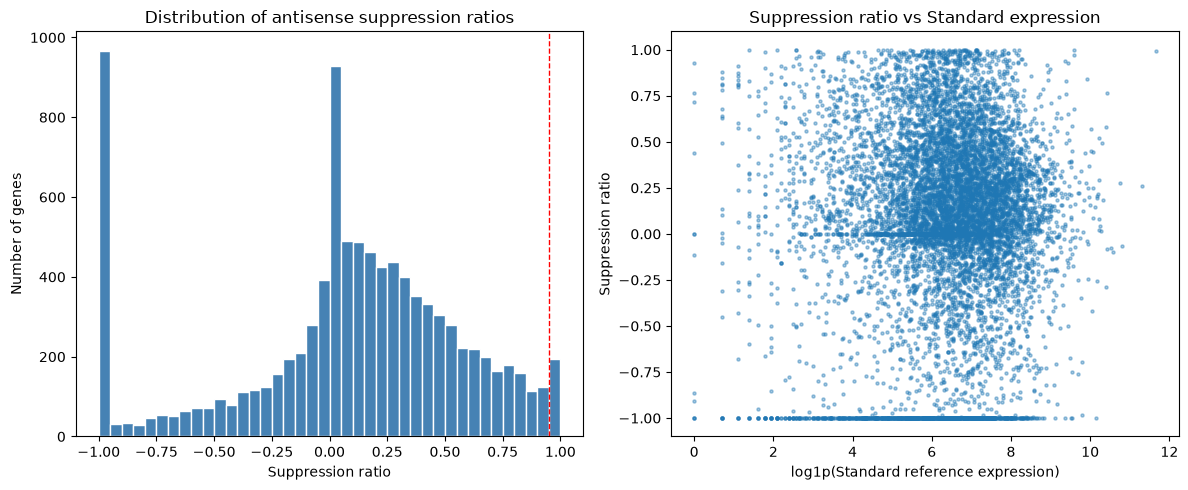

In [20]:
antisense_classes = {'antisense_exonic', 'antisense_intronic'}

aug_antisense_names = [v for v in adata_lr_aug_true_raw.var_names if parse_discovery_id(v)[1] in antisense_classes]
dis_antisense_set = set(adata_lr_dis_raw_counts.var_names)
shared_antisense = [v for v in aug_antisense_names if v in dis_antisense_set]

print(f"Shared antisense peaks between Aug and Dis: {len(shared_antisense):,}")

aug_as_counts = np.asarray(adata_lr_aug_true_raw[:, shared_antisense].X.sum(axis=0)).ravel()
dis_as_counts = np.asarray(adata_lr_dis_raw_counts[:, shared_antisense].X.sum(axis=0)).ravel()
contexts = [parse_discovery_id(v)[0] for v in shared_antisense]

antisense_df = pd.DataFrame({'peak': shared_antisense, 'gene_context': contexts,
                              'aug_count': aug_as_counts, 'dis_count': dis_as_counts})

gene_level_suppression = antisense_df.groupby('gene_context')[['aug_count', 'dis_count']].sum().reset_index()
gene_level_suppression['suppression_ratio'] = 1 - (
    gene_level_suppression['aug_count'] / gene_level_suppression['dis_count'].replace(0, np.nan)
)

std_totals_series = pd.Series(np.asarray(adata_lr_std_true_raw.X.sum(axis=0)).ravel(), index=adata_lr_std_true_raw.var_names)
gene_level_suppression['std_expr'] = gene_level_suppression['gene_context'].map(std_totals_series)

n_fully_suppressed = (gene_level_suppression['suppression_ratio'] > 0.95).sum()
print(f"Genes with antisense peaks ~fully suppressed in Aug (ratio > 0.95): "
      f"{n_fully_suppressed:,} / {len(gene_level_suppression):,}")

corr = gene_level_suppression[['std_expr', 'suppression_ratio']].corr().iloc[0, 1]
print(f"Correlation: STD gene expression vs suppression ratio: {corr:.3f}")

print("\nTop 15 most-suppressed genes (by ratio):")
display(gene_level_suppression.sort_values('suppression_ratio', ascending=False).head(15))

#Scatter plot and Histogram
MIN_DIS_COUNT = 10

n_excluded = (gene_level_suppression['dis_count'] < MIN_DIS_COUNT).sum()
print(f"Excluding {n_excluded:,} of {len(gene_level_suppression):,} genes with dis_count < {MIN_DIS_COUNT} "
      f"(ratio numerically unstable at very low counts)")

stable_suppression = gene_level_suppression[gene_level_suppression['dis_count'] >= MIN_DIS_COUNT].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(stable_suppression['suppression_ratio'].clip(lower=-1, upper=1).dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0.95, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Suppression ratio')
axes[0].set_ylabel('Number of genes')
axes[0].set_title('Distribution of antisense suppression ratios')

axes[1].scatter(np.log1p(stable_suppression['std_expr']), stable_suppression['suppression_ratio'].clip(lower=-1, upper=1), s=5, alpha=0.4)
axes[1].set_xlabel('log1p(Standard reference expression)')
axes[1].set_ylabel('Suppression ratio')
axes[1].set_title('Suppression ratio vs Standard expression')

plt.tight_layout()
plt.show()

In [21]:
n_still_negative = (gene_level_suppression['suppression_ratio'] < 0).sum()
print(f"Genes with negative suppression ratio (Aug > Dis): {n_still_negative:,} / {len(gene_level_suppression):,}")

Genes with negative suppression ratio (Aug > Dis): 3,501 / 10,173


In [22]:
gene_level_suppression.sort_values('suppression_ratio').head(10)

,gene_context,aug_count,dis_count,suppression_ratio,std_expr
6700,PDCD4-AS1,2701.0,1.0,-2700.000000,64.0
7398,RABGAP1L-DT,892.0,1.0,-891.000000,14.0
2418,ENSG00000235066,865.0,1.0,-864.000000,37.0
1771,DEPP1,789.0,1.0,-788.000000,3616.0
3159,ENSG00000269570,728.0,1.0,-727.000000,7.0
4469,GRIP2,692.0,1.0,-691.000000,32.0
3721,ENSG00000290548,490.0,1.0,-489.000000,3471.0
9588,VPS13B-DT,1562.0,5.0,-311.399994,683.0
8302,SMAD5-AS1,580.0,2.0,-289.000000,98.0
2,A2M-AS1,833.0,3.0,-276.666656,93.0


## Antisense-only, intergenic-only, and intronic-only subclustering

LR Aug antisense-only: 44,729 features
LR Aug intergenic-only: 10,105 features
LR Aug intronic-only (known_gene_intronic): 0 features
LR Dis antisense-only: 54,779 features
LR Dis intergenic-only: 10,035 features
LR Aug antisense-only: 14 clusters (44,729 features)
LR Aug intergenic-only: 14 clusters (10,105 features)
Skipping 'LR Aug intronic-only': contains 0 features.
LR Dis antisense-only: 13 clusters (54,779 features)
LR Dis intergenic-only: 14 clusters (10,035 features)


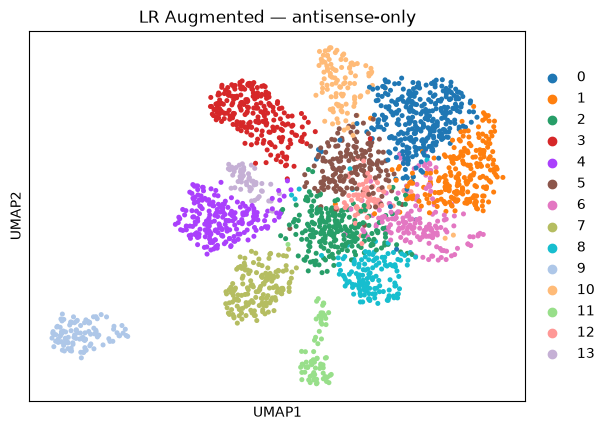

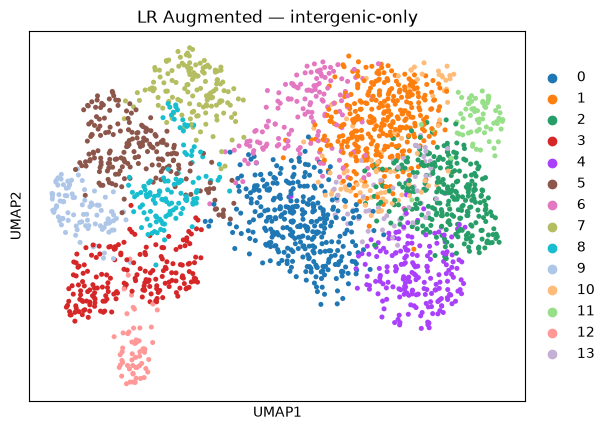

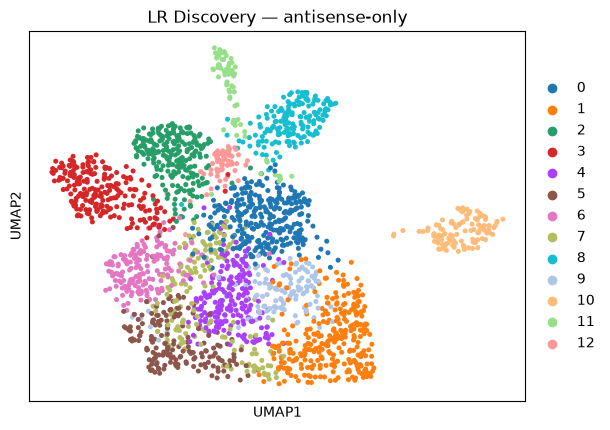

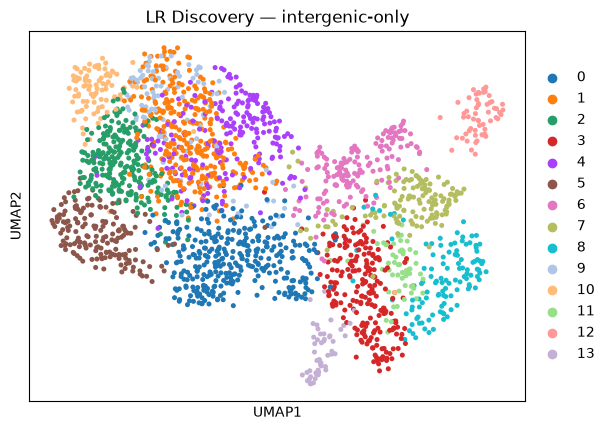

In [23]:
def subset_by_class(adata_raw, classes):
    mask = np.array([parse_discovery_id(v)[1] in classes for v in adata_raw.var_names])
    return adata_raw[:, mask].copy()

lr_aug_antisense = subset_by_class(adatas_raw['LR_Aug'], {'antisense_exonic', 'antisense_intronic'})
lr_aug_intergenic = subset_by_class(adatas_raw['LR_Aug'], {'intergenic'})
lr_aug_intronic = subset_by_class(adatas_raw['LR_Aug'], {'known_gene_intronic'})
lr_dis_antisense = subset_by_class(adatas_raw['LR_Dis'], {'antisense_exonic', 'antisense_intronic'})
lr_dis_intergenic = subset_by_class(adatas_raw['LR_Dis'], {'intergenic'})

print(f"LR Aug antisense-only: {lr_aug_antisense.n_vars:,} features")
print(f"LR Aug intergenic-only: {lr_aug_intergenic.n_vars:,} features")
print(f"LR Aug intronic-only (known_gene_intronic): {lr_aug_intronic.n_vars:,} features")
print(f"LR Dis antisense-only: {lr_dis_antisense.n_vars:,} features")
print(f"LR Dis intergenic-only: {lr_dis_intergenic.n_vars:,} features")


def cluster_subset(adata, resolution=1.0, label=""):
    if adata.n_vars == 0:
        print(f"Skipping '{label}': contains 0 features.")
        return None
    a = adata.copy()
    # No normalize_total/log1p here — LR already normalised, unlike SR's version.
    n_top = min(2000, a.n_vars)
    n_comps = min(30, a.n_vars - 1, a.n_obs - 1)
    if n_comps < 1:
        print(f"Skipping '{label}': not enough features/cells for PCA.")
        return None
    sc.pp.highly_variable_genes(a, n_top_genes=n_top, flavor='seurat')
    sc.tl.pca(a, svd_solver='arpack', random_state=42, n_comps=n_comps)
    sc.pp.neighbors(a, n_neighbors=15, n_pcs=min(30, n_comps), random_state=42)
    sc.tl.umap(a, random_state=42)
    sc.tl.leiden(a, resolution=resolution, key_added='leiden', random_state=42)
    print(f"{label}: {a.obs['leiden'].nunique()} clusters ({a.n_vars:,} features)")
    return a

lr_aug_antisense_cl = cluster_subset(lr_aug_antisense, label="LR Aug antisense-only")
lr_aug_intergenic_cl = cluster_subset(lr_aug_intergenic, label="LR Aug intergenic-only")
lr_aug_intronic_cl = cluster_subset(lr_aug_intronic, label="LR Aug intronic-only")
lr_dis_antisense_cl = cluster_subset(lr_dis_antisense, label="LR Dis antisense-only")
lr_dis_intergenic_cl = cluster_subset(lr_dis_intergenic, label="LR Dis intergenic-only")

if lr_aug_antisense_cl: sc.pl.umap(lr_aug_antisense_cl, color='leiden', title='LR Augmented — antisense-only')
if lr_aug_intergenic_cl: sc.pl.umap(lr_aug_intergenic_cl, color='leiden', title='LR Augmented — intergenic-only')
if lr_aug_intronic_cl: sc.pl.umap(lr_aug_intronic_cl, color='leiden', title='LR Augmented — intronic-only (known_gene_intronic)')
if lr_dis_antisense_cl: sc.pl.umap(lr_dis_antisense_cl, color='leiden', title='LR Discovery — antisense-only')
if lr_dis_intergenic_cl: sc.pl.umap(lr_dis_intergenic_cl, color='leiden', title='LR Discovery — intergenic-only')

## CellTypist colouring for Augmented's three novel-peak subsets

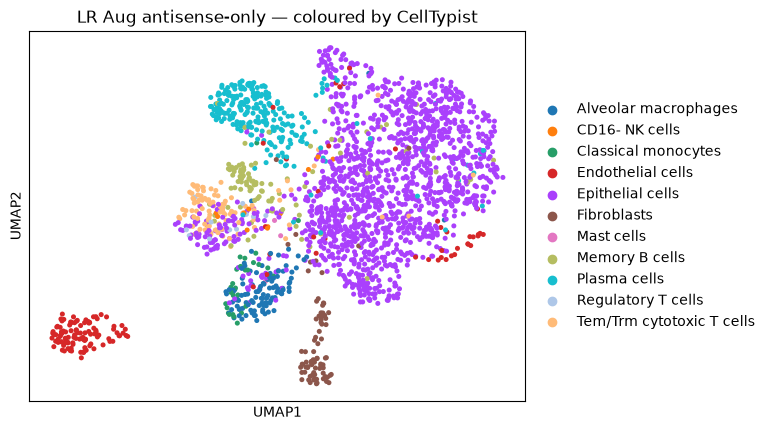

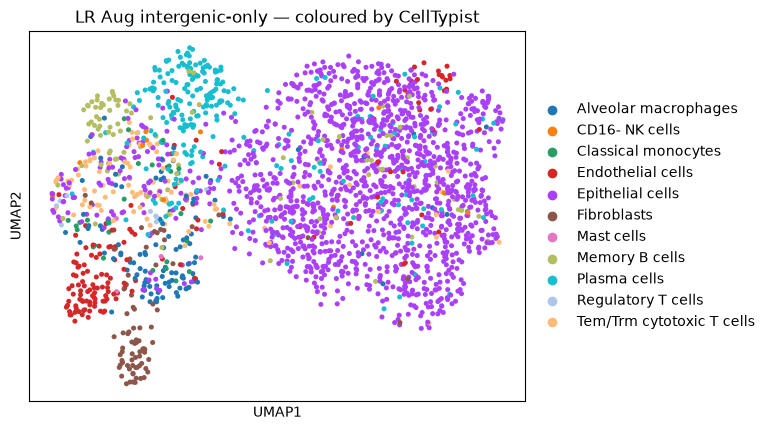

In [24]:
for subset_adata, subset_name in [
    (lr_aug_antisense_cl, 'LR Aug antisense-only'),
    (lr_aug_intergenic_cl, 'LR Aug intergenic-only'),
    (lr_aug_intronic_cl, 'LR Aug intronic-only'),
]:
    if subset_adata is not None:
        subset_adata.obs['celltypist_label'] = adatas['LR_Aug'].obs['celltypist_label'].reindex(subset_adata.obs_names).values
        sc.pl.umap(subset_adata, color='celltypist_label', title=f'{subset_name} — coloured by CellTypist')

## Novel-features

LR Aug combined (all novel classes): 54,834 features
LR Dis combined (all novel classes): 64,814 features
LR Aug combined: 15 clusters (54,834 features)
LR Dis combined: 15 clusters (64,814 features)


... storing 'dominant_feature_type' as categorical


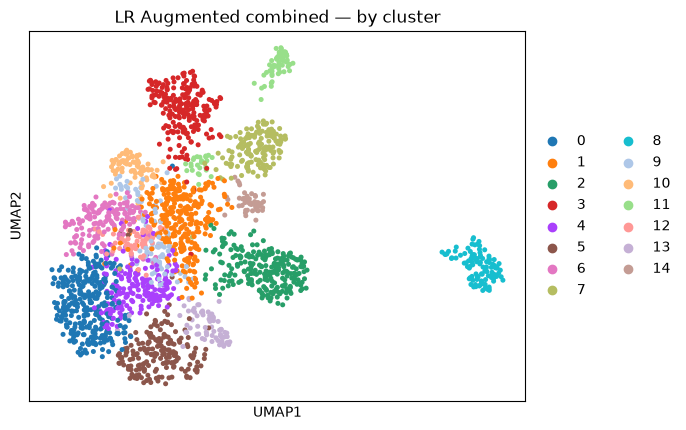

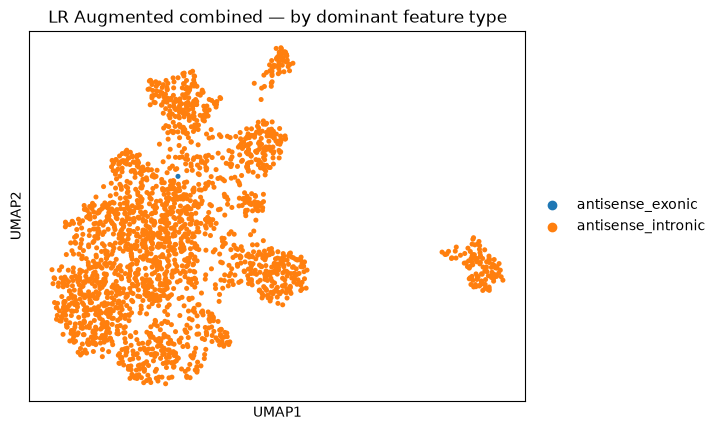

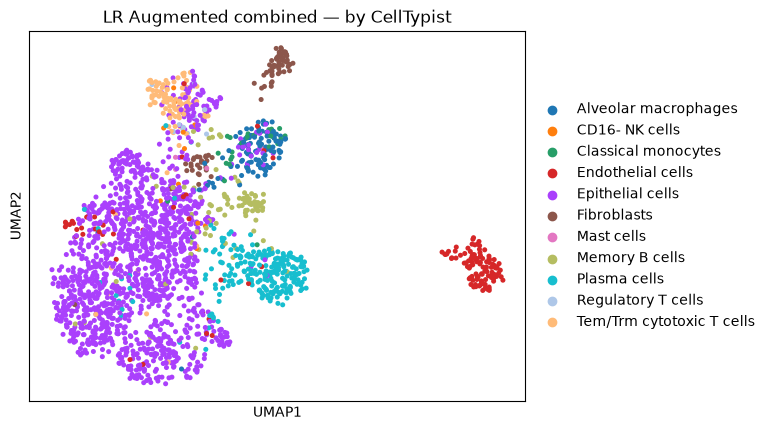

... storing 'dominant_feature_type' as categorical


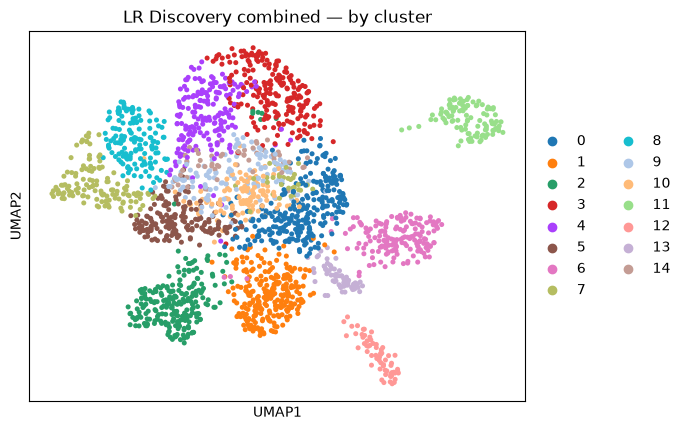

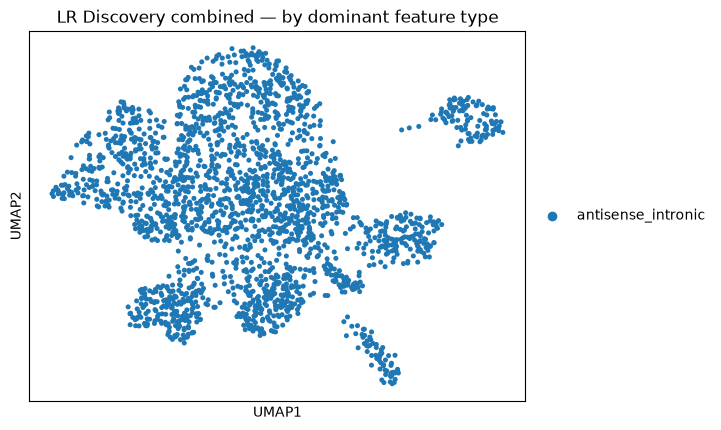

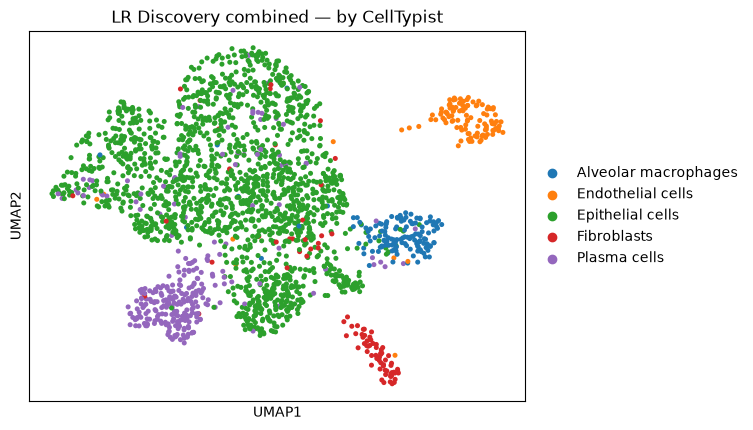

In [25]:
lr_aug_combined = subset_by_class(
    adatas_raw['LR_Aug'], {'antisense_exonic', 'antisense_intronic', 'intergenic', 'known_gene_intronic'}
)
lr_dis_combined = subset_by_class(
    adatas_raw['LR_Dis'], {'antisense_exonic', 'antisense_intronic', 'intergenic'}
)

print(f"LR Aug combined (all novel classes): {lr_aug_combined.n_vars:,} features")
print(f"LR Dis combined (all novel classes): {lr_dis_combined.n_vars:,} features")

lr_aug_combined_cl = cluster_subset(lr_aug_combined, label="LR Aug combined")
lr_dis_combined_cl = cluster_subset(lr_dis_combined, label="LR Dis combined")


def assign_dominant_feature_type(adata_raw_subset, adata_clustered, classes):
    """For each cell, which of the combined classes contributes the most signal —
    a per-cell summary of what kind of novel feature is driving that cell's profile."""
    if adata_clustered is None:
        return
    class_totals = {}
    for cls in classes:
        cls_mask = np.array([parse_discovery_id(v)[1] == cls for v in adata_raw_subset.var_names])
        if cls_mask.sum() == 0:
            class_totals[cls] = np.zeros(adata_raw_subset.n_obs)
            continue
        class_totals[cls] = np.asarray(adata_raw_subset[:, cls_mask].X.sum(axis=1)).ravel()
    totals_df = pd.DataFrame(class_totals, index=adata_raw_subset.obs_names)
    dominant = totals_df.idxmax(axis=1)
    adata_clustered.obs['dominant_feature_type'] = dominant.reindex(adata_clustered.obs_names).values


assign_dominant_feature_type(lr_aug_combined, lr_aug_combined_cl,
                              {'antisense_exonic', 'antisense_intronic', 'intergenic', 'known_gene_intronic'})
assign_dominant_feature_type(lr_dis_combined, lr_dis_combined_cl,
                              {'antisense_exonic', 'antisense_intronic', 'intergenic'})

if lr_aug_combined_cl is not None:
    sc.pl.umap(lr_aug_combined_cl, color='leiden', title='LR Augmented combined — by cluster')
    sc.pl.umap(lr_aug_combined_cl, color='dominant_feature_type', title='LR Augmented combined — by dominant feature type')
    lr_aug_combined_cl.obs['celltypist_label'] = adatas['LR_Aug'].obs['celltypist_label'].reindex(lr_aug_combined_cl.obs_names).values
    sc.pl.umap(lr_aug_combined_cl, color='celltypist_label', title='LR Augmented combined — by CellTypist')

if lr_dis_combined_cl is not None:
    sc.pl.umap(lr_dis_combined_cl, color='leiden', title='LR Discovery combined — by cluster')
    sc.pl.umap(lr_dis_combined_cl, color='dominant_feature_type', title='LR Discovery combined — by dominant feature type')
    lr_dis_combined_cl.obs['celltypist_label'] = adatas['LR_Dis'].obs['celltypist_label'].reindex(lr_dis_combined_cl.obs_names).values
    sc.pl.umap(lr_dis_combined_cl, color='celltypist_label', title='LR Discovery combined — by CellTypist')

## AUG DIS top-marker-peak cross-matching


Top antisense marker overall (Aug): GPAT4|antisense_intronic|peak_579369 (cluster 0, score=26.3)


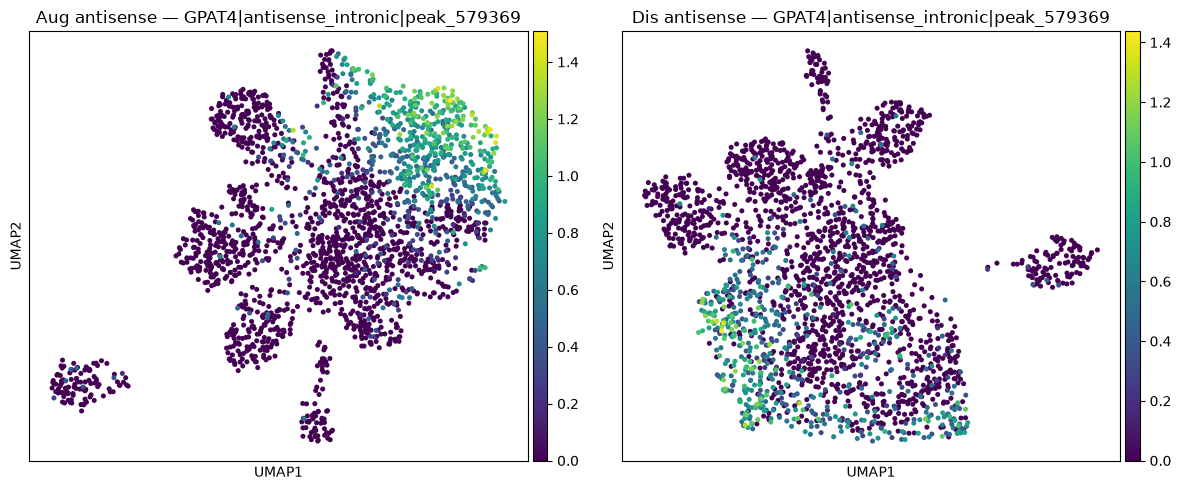

Top intergenic marker overall (Aug): near:ENSG00000289447:8781bp|intergenic|peak_547747 (cluster 4, score=21.9)


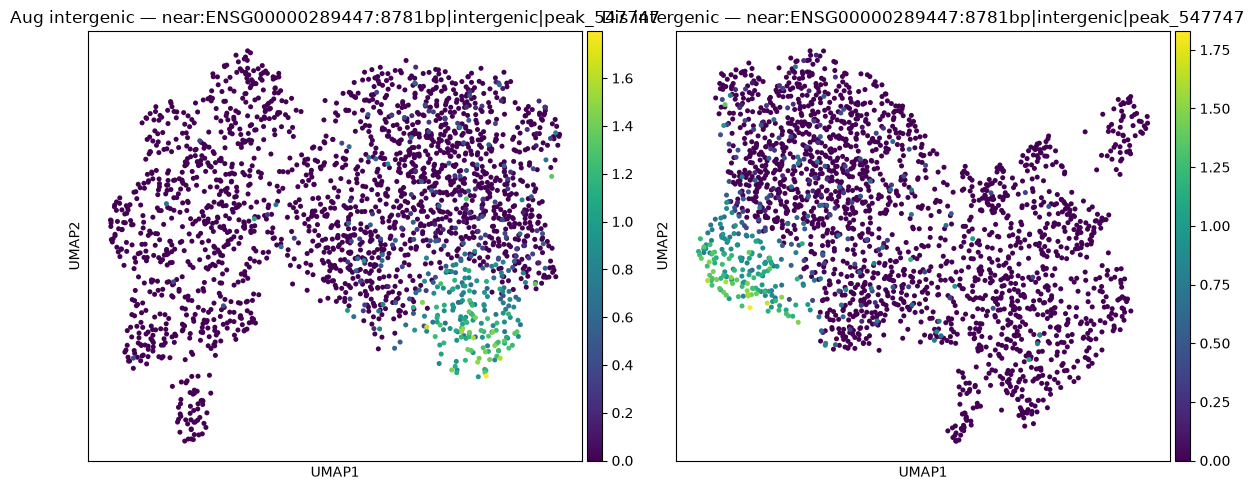

Top combined (all novel classes) marker overall (Aug): GPAT4|antisense_intronic|peak_579369 (cluster 0, score=25.2)


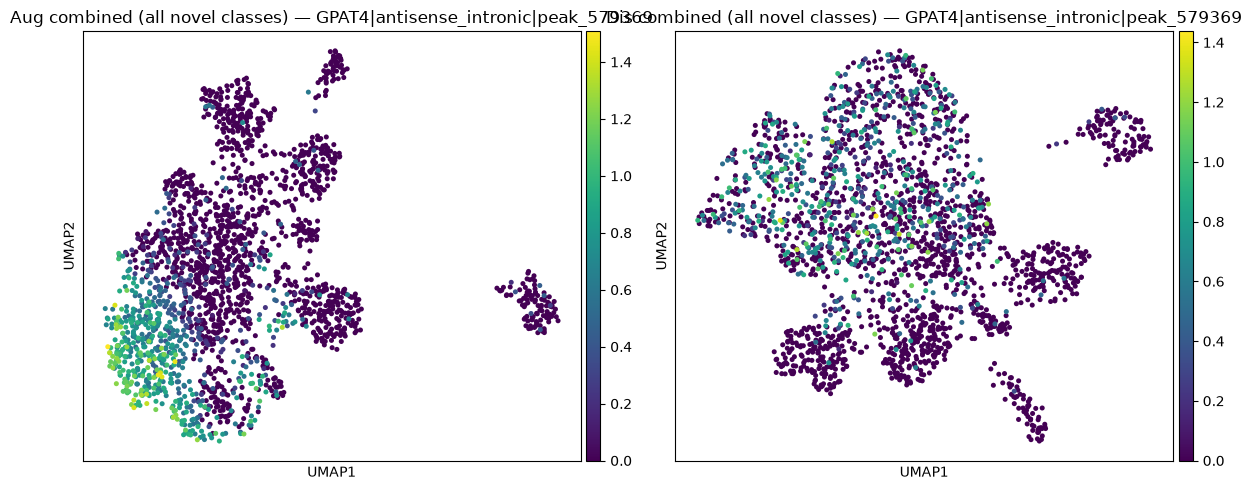

In [26]:
def find_and_compare_top_marker(adata_aug_subset, adata_dis_subset, label):
    sc.tl.rank_genes_groups(adata_aug_subset, groupby='leiden', method='wilcoxon')
    all_markers = pd.concat([
        sc.get.rank_genes_groups_df(adata_aug_subset, group=c).assign(cluster=c)
        for c in adata_aug_subset.obs['leiden'].cat.categories
    ])
    top = all_markers.sort_values('scores', ascending=False).iloc[0]
    print(f"Top {label} marker overall (Aug): {top['names']} (cluster {top['cluster']}, score={top['scores']:.1f})")

    peak_id = parse_discovery_id(top['names'])[2]
    dis_match = [v for v in adata_dis_subset.var_names if parse_discovery_id(v)[2] == peak_id]

    if not dis_match:
        print(f"No matching peak_id found in Dis {label} subset.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sc.pl.umap(adata_aug_subset, color=top['names'], ax=axes[0], show=False, title=f'Aug {label} — {top["names"]}')
    sc.pl.umap(adata_dis_subset, color=dis_match[0], ax=axes[1], show=False, title=f'Dis {label} — {dis_match[0]}')
    plt.tight_layout()
    plt.show()

if lr_aug_antisense_cl is not None and lr_dis_antisense_cl is not None:
    find_and_compare_top_marker(lr_aug_antisense_cl, lr_dis_antisense_cl, 'antisense')
if lr_aug_intergenic_cl is not None and lr_dis_intergenic_cl is not None:
    find_and_compare_top_marker(lr_aug_intergenic_cl, lr_dis_intergenic_cl, 'intergenic')


if lr_aug_combined_cl is not None and lr_dis_combined_cl is not None:
    find_and_compare_top_marker(lr_aug_combined_cl, lr_dis_combined_cl, 'combined (all novel classes)')

## Volcano plots + STRING export 

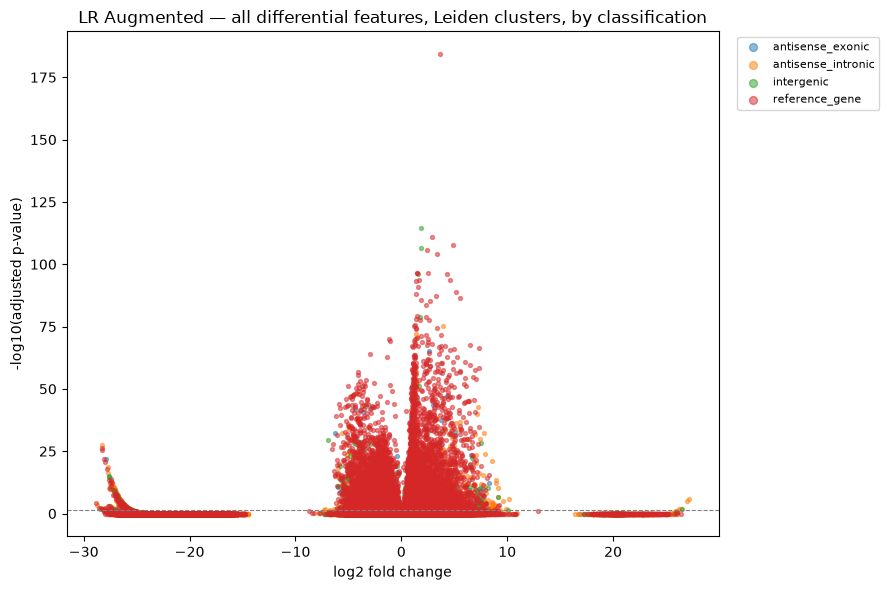

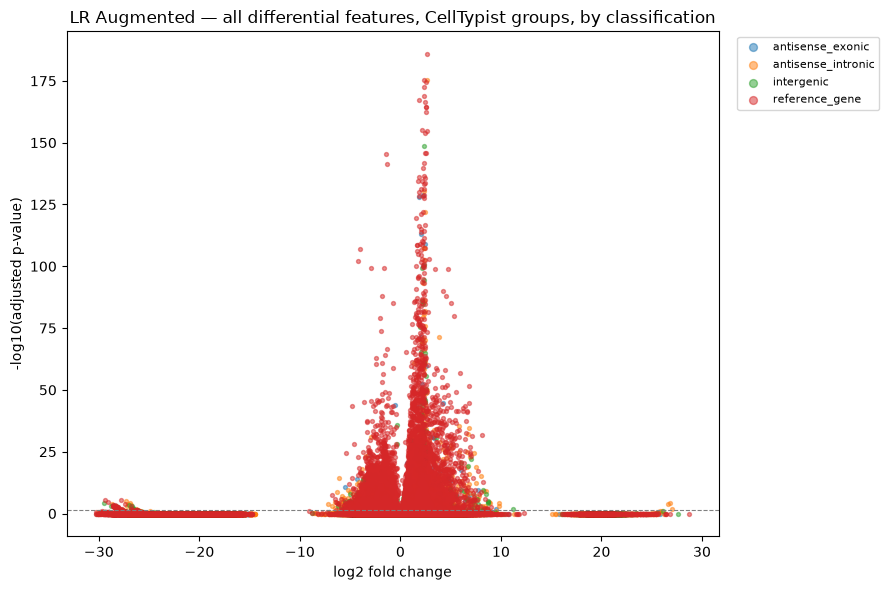

In [27]:
def build_volcano_data(adata, key='rank_genes_groups'):
    groups = list(adata.uns[key]['names'].dtype.names)
    rows = []
    for g in groups:
        names = adata.uns[key]['names'][g]
        lfcs = adata.uns[key]['logfoldchanges'][g]
        padjs = adata.uns[key]['pvals_adj'][g]
        for nm, lfc, padj in zip(names, lfcs, padjs):
            if '|' in nm:
                context, classification, peak_id = parse_discovery_id(nm)
            else:
                context, classification, peak_id = nm, 'reference_gene', None
            rows.append({'group': g, 'feature': nm, 'gene_context': context,
                         'classification': classification, 'log2FC': lfc, 'padj': padj})
    return pd.DataFrame(rows)


def plot_volcano(df, title):
    df = df.copy()
    df['neg_log10_padj'] = -np.log10(df['padj'].replace(0, 1e-300))
    fig, ax = plt.subplots(figsize=(9, 6))
    for cls, group_df in df.groupby('classification'):
        ax.scatter(group_df['log2FC'], group_df['neg_log10_padj'], s=8, alpha=0.5, label=cls)
    ax.axhline(-np.log10(0.05), color='grey', linestyle='--', linewidth=0.8)
    ax.set_xlabel('log2 fold change')
    ax.set_ylabel('-log10(adjusted p-value)')
    ax.set_title(title)
    ax.legend(markerscale=2, fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


volcano_df_leiden = build_volcano_data(adatas['LR_Aug'], key='rank_genes_groups')
volcano_df_celltype = build_volcano_data(adatas['LR_Aug'], key='rank_genes_groups_celltypist')

plot_volcano(volcano_df_leiden, 'LR Augmented — all differential features, Leiden clusters, by classification')
plot_volcano(volcano_df_celltype, 'LR Augmented — all differential features, CellTypist groups, by classification')

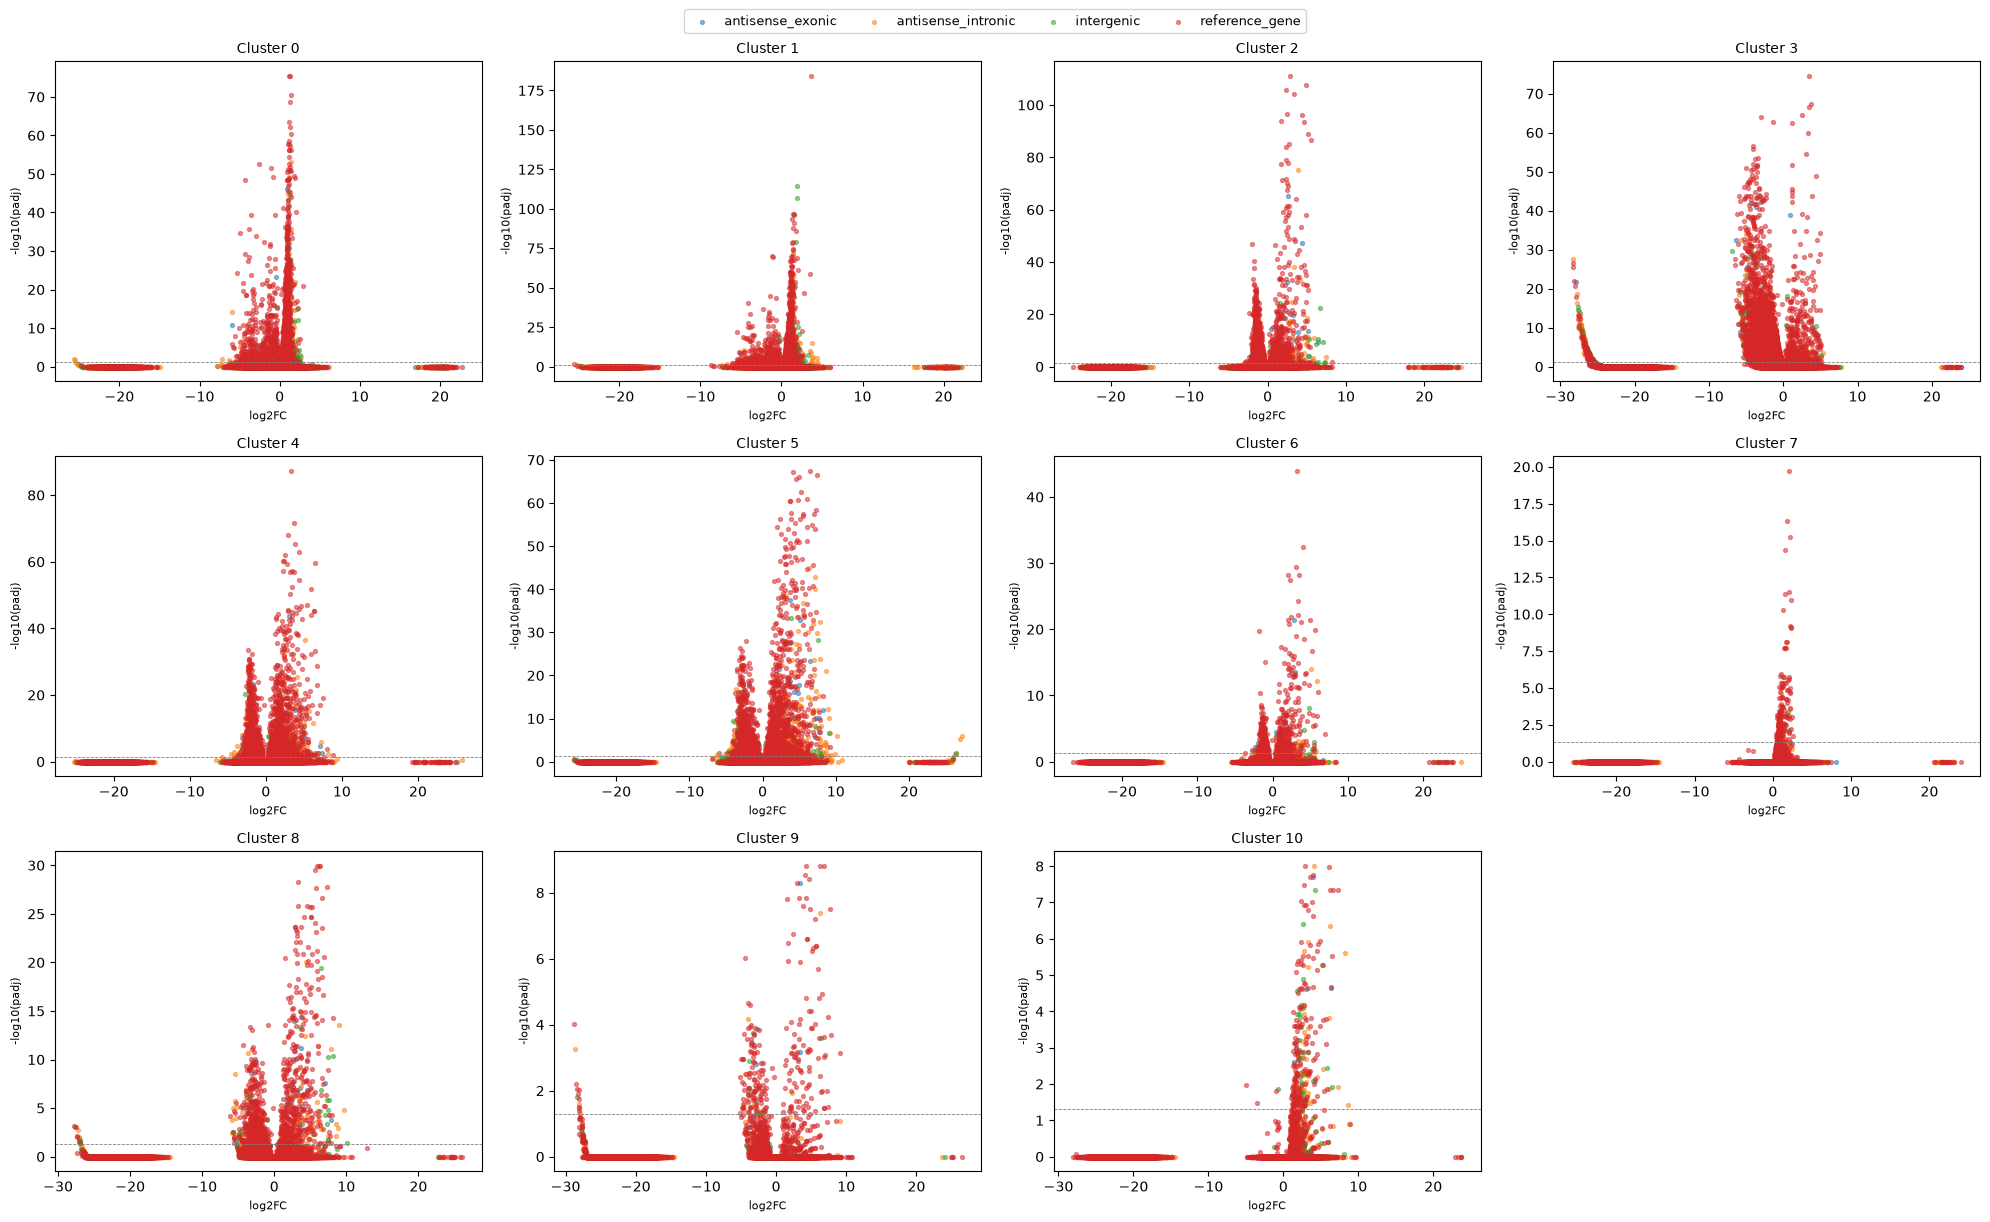

In [28]:
def plot_volcano_per_cluster(adata, key='rank_genes_groups'):
    volcano_df = build_volcano_data(adata, key=key)
    groups = sorted(volcano_df['group'].unique(), key=lambda x: (len(x), x))
    n_cols = 4
    n_rows = int(np.ceil(len(groups) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for ax, group in zip(axes, groups):
        group_df = volcano_df[volcano_df['group'] == group].copy()
        group_df['neg_log10_padj'] = -np.log10(group_df['padj'].replace(0, 1e-300))
        for cls, cls_df in group_df.groupby('classification'):
            ax.scatter(cls_df['log2FC'], cls_df['neg_log10_padj'], s=8, alpha=0.5, label=cls)
        ax.axhline(-np.log10(0.05), color='grey', linestyle='--', linewidth=0.6)
        ax.set_title(f'Cluster {group}', fontsize=10)
        ax.set_xlabel('log2FC', fontsize=8)
        ax.set_ylabel('-log10(padj)', fontsize=8)

    for ax in axes[len(groups):]:
        ax.axis('off')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=len(labels), fontsize=9)
    plt.tight_layout()
    plt.show()

plot_volcano_per_cluster(adatas['LR_Aug'], key='rank_genes_groups')

In [29]:
STRING_OUT_DIR = "/mnt/md0/jack-gaa/gaa/analysis/string_export/"
os.makedirs(STRING_OUT_DIR, exist_ok=True)

SIG_PADJ = 0.05
SIG_LOG2FC = 1.0

def clean_gene_symbols(gene_contexts):
    # Drops non-symbol contexts — 'intergenic' peaks with no overlap, and 'near:X:Ybp'
    # proximity labels — neither is a valid STRING input.
    return sorted(set(g for g in gene_contexts if g and g != 'intergenic' and not g.startswith('near:')))

sig_leiden = volcano_df_leiden[(volcano_df_leiden['padj'] < SIG_PADJ) & (volcano_df_leiden['log2FC'].abs() >= SIG_LOG2FC)]
sig_celltype = volcano_df_celltype[(volcano_df_celltype['padj'] < SIG_PADJ) & (volcano_df_celltype['log2FC'].abs() >= SIG_LOG2FC)]

genes_leiden = clean_gene_symbols(sig_leiden['gene_context'])
genes_celltype = clean_gene_symbols(sig_celltype['gene_context'])

pd.Series(genes_leiden).to_csv(os.path.join(STRING_OUT_DIR, "lr_aug_novel_genes_leiden_STRING.csv"), index=False, header=False)
pd.Series(genes_celltype).to_csv(os.path.join(STRING_OUT_DIR, "lr_aug_novel_genes_celltype_STRING.csv"), index=False, header=False)

print(f"Leiden-based (all significant, global threshold): {len(genes_leiden)} genes saved for STRING")
print(f"CellTypist-based (all significant, global threshold): {len(genes_celltype)} genes saved for STRING")
print(f"Saved to {STRING_OUT_DIR}")

Leiden-based (all significant, global threshold): 4999 genes saved for STRING
CellTypist-based (all significant, global threshold): 4618 genes saved for STRING
Saved to /mnt/md0/jack-gaa/gaa/analysis/string_export/


## Cluster-based STRING list, corrected to use std_mapped_cluster

In [30]:
valid_groups = [g for g, n in adatas['LR_Aug'].obs['std_mapped_cluster'].value_counts().items() if n >= 2]
excluded = set(adatas['LR_Aug'].obs['std_mapped_cluster'].unique()) - set(valid_groups)
print(f"Excluding std_mapped_cluster group(s) with fewer than 2 cells: {excluded}")

sc.tl.rank_genes_groups(adatas['LR_Aug'], groupby='std_mapped_cluster', groups=valid_groups,
                         method='wilcoxon', key_added='rank_genes_groups_stdmapped')

lr_aug_peak_ranking_stdmapped = build_peak_marker_ranking_table(
    adatas['LR_Aug'], 'LR_Aug', top_n_per_cluster=15, key='rank_genes_groups_stdmapped'
)

def get_top_n_genes_per_cluster(ranking_table, n=15):
    return ranking_table.sort_values('score', ascending=False).groupby('group').head(n)

lr_aug_top_per_cluster = get_top_n_genes_per_cluster(lr_aug_peak_ranking_stdmapped, n=15)
top_per_cluster_genes = clean_gene_symbols(lr_aug_top_per_cluster['gene_context'])

print(f"Top 15 per STD-MAPPED CLUSTER: {len(top_per_cluster_genes)} distinct genes across "
      f"{lr_aug_top_per_cluster['group'].nunique()} clusters")

pd.Series(top_per_cluster_genes).to_csv(
    os.path.join(STRING_OUT_DIR, "lr_aug_novel_genes_top_per_cluster_STRING.csv"), index=False, header=False
)

print("\n--- Copy-paste ready (top per cluster, std_mapped) ---")
print("\n".join(top_per_cluster_genes))

Excluding std_mapped_cluster group(s) with fewer than 2 cells: set()
Top 15 per STD-MAPPED CLUSTER: 131 distinct genes across 10 clusters

--- Copy-paste ready (top per cluster, std_mapped) ---
ADGRL4
AFF3
ANK2
ANKRD36BP2
ANKRD44
ANO2
AOAH
ARHGAP15
ARHGAP24
ARPP21
ATG7
B2M
BCL11A
BCL11B
BCL2
BLK
BRINP3
CACNA1C
CALD1
CCDC102B
CD2
CD247
CDH12
CDK14
CELF2
COL4A1
COL4A2
COL5A2
COL6A6
CSMD1
DIP2C
DLC1
DOCK4
EBF1
EBF2
EGFL7
EGFR
ELL2
ENSG00000229618
ENSG00000251574
ENSG00000253553
ENSG00000254202
ENSG00000284418
ENSG00000285798
ENSG00000289873
ERBB4
FBXL7
FBXW7
FCRL5
FLT1
FMNL2
FRMD4A
FRMD4B
FUT8
FYB1
FYN
GLUL
GNAQ
GPC6
GRB10
HLA-A
HLA-B
IFNG-AS1
IGHJ3
IGHV1-2
IGHV1-3
IGKC
IGKV1-12
IKZF3
INSR
KAZN
KCNIP4
LDB2
LHFPL6
LINC01934
LINC02046
LINC02906
LRFN5
LRRC7
MBNL1
MS4A7
MYOCOS
NDRG1
NEBL
NIHCOLE
NLGN1
NOTCH4
PCDH9
PDGFRB
PDK4
PEAK1
PIM2
PRKCB
PRKCH
PRKG1
PTPRC
QKI
RALGPS2
RALGPS2-AS1
RIMS2
RIPOR2
RMST
ROBO2
RUFY3
SAT1
SCML4
SIPA1L2
SKAP1
SLC4A4
SLC8A1
SLFN12L
SLIT2
SNTG1
SPIRE1
SPRY1
SRGN
ST6

In [31]:
df_print = lr_aug_top_per_cluster.copy()

print(f"Top 15 per std_mapped_cluster across {df_print['group'].nunique()} clusters\n")
print("--- Copy-paste ready breakdown per cluster ---")

for cluster_id, cluster_df in df_print.groupby('group'):
    print(f"\n=============================")
    print(f"  CLUSTER: {cluster_id}")
    print(f"=============================")

    cleaned_cluster_genes = clean_gene_symbols(cluster_df['gene_context'])

    if cleaned_cluster_genes:
        print("\n".join(cleaned_cluster_genes))
    else:
        print("(No valid genes found in this cluster)")

Top 15 per std_mapped_cluster across 10 clusters

--- Copy-paste ready breakdown per cluster ---

  CLUSTER: 0
ANK2
DIP2C
EGFR
ENSG00000229618
ENSG00000251574
ENSG00000253553
ENSG00000284418
GPC6
NDRG1
NEBL
NIHCOLE
RIMS2
RUFY3
SNTG1
SPIRE1

  CLUSTER: 1
CDH12
CSMD1
KAZN
KCNIP4
LRRC7
NLGN1
RMST
ROBO2
SLC4A4
SLIT2
TENM3

  CLUSTER: 10
ARPP21
BRINP3
COL6A6
ENSG00000254202
ENSG00000285798
ERBB4
FRMD4A
LINC02046
LINC02906
LRFN5
MYOCOS
PCDH9
PDK4
PRKG1

  CLUSTER: 2
BCL11B
CD2
CD247
CELF2
FYB1
FYN
LINC01934
PRKCH
PTPRC
RIPOR2
SCML4
SKAP1
SLFN12L
THEMIS
TOX

  CLUSTER: 3
ANKRD44
ARHGAP15
B2M
CELF2
FYN
HLA-A
HLA-B
IGKC
IGKV1-12
LINC01934
MBNL1
PRKCH
PTPRC
SKAP1
TOX

  CLUSTER: 4
ANKRD36BP2
ELL2
FBXW7
FCRL5
FUT8
IFNG-AS1
IGHJ3
IGHV1-2
IGHV1-3
IGKC
IGKV1-12
PIM2
ST6GAL1
TENT5C
XBP1

  CLUSTER: 5
AOAH
ATG7
DOCK4
FMNL2
FRMD4B
FYB1
GLUL
GNAQ
MS4A7
QKI
SAT1
SLC8A1
SRGN
TFEC
ZEB2

  CLUSTER: 7
ADGRL4
ANO2
DOCK4
EGFL7
ENSG00000289873
FBXL7
FLT1
GRB10
INSR
LDB2
NOTCH4
SIPA1L2
SPRY1
TCF4
VWF

  CLUSTER:

## Plateau test

In [32]:
lr_aug_peak_ranking_cluster_based_deep = build_peak_marker_ranking_table(
    adatas['LR_Aug'], 'LR_Aug', top_n_per_cluster=300, key='rank_genes_groups_stdmapped'
)

for n in [5, 10, 15, 20, 30, 50, 60, 80, 90, 95, 100, 110, 130, 150, 200, 250, 300]:
    test = get_top_n_genes_per_cluster(lr_aug_peak_ranking_cluster_based_deep, n=n)
    genes = clean_gene_symbols(test['gene_context'])
    print(f"Cluster Based, n={n}: {len(genes)} distinct genes")

Cluster Based, n=5: 45 distinct genes
Cluster Based, n=10: 88 distinct genes
Cluster Based, n=15: 131 distinct genes
Cluster Based, n=20: 174 distinct genes
Cluster Based, n=30: 260 distinct genes
Cluster Based, n=50: 417 distinct genes
Cluster Based, n=60: 483 distinct genes
Cluster Based, n=80: 615 distinct genes
Cluster Based, n=90: 678 distinct genes
Cluster Based, n=95: 706 distinct genes
Cluster Based, n=100: 734 distinct genes
Cluster Based, n=110: 799 distinct genes
Cluster Based, n=130: 924 distinct genes
Cluster Based, n=150: 1053 distinct genes
Cluster Based, n=200: 1346 distinct genes
Cluster Based, n=250: 1631 distinct genes
Cluster Based, n=300: 1897 distinct genes


In [33]:
lr_aug_peak_ranking_celltype = build_peak_marker_ranking_table(
    adatas['LR_Aug'], 'LR_Aug', top_n_per_cluster=15, key='rank_genes_groups_celltypist'
)

lr_aug_top_per_celltype = get_top_n_genes_per_cluster(lr_aug_peak_ranking_celltype, n=15)
top_per_celltype_genes = clean_gene_symbols(lr_aug_top_per_celltype['gene_context'])

print(f"Top 15 per CELL TYPE: {len(top_per_celltype_genes)} distinct genes across "
      f"{lr_aug_top_per_celltype['group'].nunique()} cell types")

pd.Series(top_per_celltype_genes).to_csv(
    os.path.join(STRING_OUT_DIR, "lr_aug_novel_genes_top_per_celltype_STRING.csv"), index=False, header=False
)

print("\n--- Copy-paste ready (top per cell type) ---")
print("\n".join(top_per_celltype_genes))

print(f"\nCompare against the cluster-based version: "
      f"{len(top_per_celltype_genes)} (cell-type) vs {len(top_per_cluster_genes)} (cluster) distinct genes.")

Top 15 per CELL TYPE: 147 distinct genes across 11 cell types

--- Copy-paste ready (top per cell type) ---
ACSL4
AFF3
ANKRD36BP2
ANKRD44
AOAH
ARHGAP24
ARL15
ATG7
ATP8B4
B2M
BCL11A
BLK
CACNA1C
CALD1
CARD11
CCDC102B
CCL5
CD69
CD74
CD86
CDK14
CELF2
COL4A1
COL4A2
COL5A2
CTSB
CTSC
CTSL
CTSW
CYRIA
DLC1
DMXL2
DOCK10
DOCK2
DOCK4
DOCK8
EBF1
EBF2
EGFL7
ELL2
ENSG00000227240
ENSG00000229618
ENSG00000240521
ENSG00000243797
ENSG00000250243
ENSG00000251574
ENSG00000283674
ENSG00000284418
ENSG00000285534
ETV6
FBXL7
FBXW7
FCRL5
FLT1
FMNL2
FRMD4B
FUT8
FYN
GLUL
GNAQ
GNLY
GRAP2
HDC
HLA-A
HLA-B
HLA-C
HLA-DRA
HPGD
ICOS
ID2
IFNG-AS1
IGHJ3
IGHV1-2
IGHV1-3
IGKC
IGLV3-19
IKZF3
IL18R1
IL1RL1
INSR
ITGAE
KCNIP4
KLRC1
KLRC3
LDB2
LHFPL6
LINC01934
LRRC7
LTB
MAGI1
MS4A2
MS4A7
N4BP1
NDRG1
NIHCOLE
NLGN1
NPL
PCSK6
PDGFRB
PEAK1
PHACTR2
PIM2
PLPP1
PLPP3
PRKCB
PRKCH
PTPRC
QKI
RAB31
RALGPS2
RALGPS2-AS1
RASGRF2
RGS13
RIPOR2
SAMSN1
SAT1
SIPA1L2
SKAP1
SLC4A4
SLC8A1
SLIT2
SMYD3
SPRY1
SRGN
ST6GAL1
STAT4
STK17B
STXBP5
SYNPO2
TBC1

In [34]:
lr_aug_peak_ranking_cell_type_based_deep = build_peak_marker_ranking_table(
    adatas['LR_Aug'], 'LR_Aug', top_n_per_cluster=300, key='rank_genes_groups_celltypist'
)

for n in [5, 10, 15, 20, 30, 50, 60, 80, 90, 95, 100, 110, 130, 150, 200, 250, 300]:
    test = get_top_n_genes_per_cluster(lr_aug_peak_ranking_cell_type_based_deep, n=n)
    genes = clean_gene_symbols(test['gene_context'])
    print(f"Cell Type Based, n={n}: {len(genes)} distinct genes")

Cell Type Based, n=5: 52 distinct genes
Cell Type Based, n=10: 102 distinct genes
Cell Type Based, n=15: 147 distinct genes
Cell Type Based, n=20: 195 distinct genes
Cell Type Based, n=30: 284 distinct genes
Cell Type Based, n=50: 453 distinct genes
Cell Type Based, n=60: 531 distinct genes
Cell Type Based, n=80: 670 distinct genes
Cell Type Based, n=90: 737 distinct genes
Cell Type Based, n=95: 774 distinct genes
Cell Type Based, n=100: 808 distinct genes
Cell Type Based, n=110: 883 distinct genes
Cell Type Based, n=130: 1014 distinct genes
Cell Type Based, n=150: 1159 distinct genes
Cell Type Based, n=200: 1473 distinct genes
Cell Type Based, n=250: 1801 distinct genes
Cell Type Based, n=300: 2109 distinct genes


## Top novel non-antisense markers for Endothelial and Fibroblasts

In [35]:
CLUSTERS_OF_INTEREST_LR = {'Endothelial': 7, 'Fibroblasts': 8}

NON_ANTISENSE_NOVEL = {'intergenic', 'extended_exon', 'proximal_novel_exon'}

def top_novel_non_antisense_markers(deep_ranking_table, cluster_number, n=10):
    """Top-n Augmented markers for one std_mapped_cluster, restricted to
    non-antisense novel classes. Needs a table built with top_n_per_cluster
    large enough that these classes aren't crowded out by antisense entries
    at the same locus (300 here, same depth as the n=15 plateau test above).
    Uses the cluster-based deep table (grouped by std_mapped_cluster), not the
    cell-type-based one, since CellTypist labels can span more than one cluster."""
    subset = deep_ranking_table[
        (deep_ranking_table['group'].astype(str) == str(cluster_number)) &
        (deep_ranking_table['classification'].isin(NON_ANTISENSE_NOVEL))
    ].sort_values('score', ascending=False)
    return subset.head(n)

print(f"=== LR Aug cluster {CLUSTERS_OF_INTEREST_LR['Endothelial']} (Endothelial): top non-antisense novel markers ===")
display(top_novel_non_antisense_markers(lr_aug_peak_ranking_cluster_based_deep, CLUSTERS_OF_INTEREST_LR['Endothelial']))

print(f"\n=== LR Aug cluster {CLUSTERS_OF_INTEREST_LR['Fibroblasts']} (Fibroblasts): top non-antisense novel markers ===")
display(top_novel_non_antisense_markers(lr_aug_peak_ranking_cluster_based_deep, CLUSTERS_OF_INTEREST_LR['Fibroblasts']))


=== LR Aug cluster 7 (Endothelial): top non-antisense novel markers ===


,condition,group,feature,gene_context,classification,peak_id,score,log2FC,padj
465,LR_Aug,7,near:PLPP3:1375bp|intergenic|peak_312805,near:PLPP3:1375bp,intergenic,peak_312805,12.686009,3.831712,5.656721e-34
582,LR_Aug,7,near:LDB2:174bp|intergenic|peak_508937,near:LDB2:174bp,intergenic,peak_508937,11.716228,7.496917,6.872156e-29
1215,LR_Aug,7,near:SPRED1:409bp|intergenic|peak_95596,near:SPRED1:409bp,intergenic,peak_95596,9.419150,2.116082,1.359234e-18



=== LR Aug cluster 8 (Fibroblasts): top non-antisense novel markers ===


,condition,group,feature,gene_context,classification,peak_id,score,log2FC,padj
1082,LR_Aug,8,near:CCDC102B:17980bp|intergenic|peak_133110,near:CCDC102B:17980bp,intergenic,peak_133110,9.761755,6.677455,2.852795e-19
1633,LR_Aug,8,near:EBF1:41bp|intergenic|peak_543869,near:EBF1:41bp,intergenic,peak_543869,7.706776,3.236830,6.306070e-12
1750,LR_Aug,8,near:ENSG00000264705:40725bp|intergenic|peak_1...,near:ENSG00000264705:40725bp,intergenic,peak_133143,6.991354,7.958828,9.618622e-10
1879,LR_Aug,8,near:ENSG00000264705:56029bp|intergenic|peak_1...,near:ENSG00000264705:56029bp,intergenic,peak_133137,6.434646,8.380681,3.389479e-08
2028,LR_Aug,8,near:SPRED1:409bp|intergenic|peak_95596,near:SPRED1:409bp,intergenic,peak_95596,5.887188,1.665956,8.199433e-07
2038,LR_Aug,8,near:CCDC102B:15348bp|intergenic|peak_133108,near:CCDC102B:15348bp,intergenic,peak_133108,5.854857,7.641210,9.789984e-07
2049,LR_Aug,8,near:CCDC102B:76705bp|intergenic|peak_133129,near:CCDC102B:76705bp,intergenic,peak_133129,5.811548,6.693129,1.250426e-06
2152,LR_Aug,8,near:CCDC102B:60456bp|intergenic|peak_133124,near:CCDC102B:60456bp,intergenic,peak_133124,5.493948,8.726727,6.854292e-06
2307,LR_Aug,8,near:ENSG00000264705:59438bp|intergenic|peak_1...,near:ENSG00000264705:59438bp,intergenic,peak_133132,5.073910,7.131903,5.455728e-05
2354,LR_Aug,8,near:ENSG00000264705:18187bp|intergenic|peak_1...,near:ENSG00000264705:18187bp,intergenic,peak_133149,4.920469,8.304528,1.125607e-04


## Reclassifying near-boundary intergenic peaks as proximal_novel_exon

In [36]:
import re

PROXIMAL_DISTANCE_THRESHOLD_BP = 2000

def reclassify_proximal_intergenic(df, threshold=PROXIMAL_DISTANCE_THRESHOLD_BP,
                                     gene_context_col='gene_context',
                                     classification_col='classification'):
    """Returns a copy of df with 'intergenic' rows reclassified to
    'proximal_novel_exon' when their near:GENE:Xbp distance is within
    `threshold` bp of the gene boundary, on either side. Leaves every
    other row, and every other column, untouched. Prints a before/after
    count so the effect is visible immediately."""
    def parse_distance(ctx):
        m = re.match(r'near:[^:]+:(\d+)bp', str(ctx))
        return int(m.group(1)) if m else None

    out = df.copy()
    distances = out[gene_context_col].apply(parse_distance)
    reclass_mask = (
        (out[classification_col] == 'intergenic') &
        distances.notna() &
        (distances <= threshold)
    )
    n_before = (out[classification_col] == 'intergenic').sum()
    out.loc[reclass_mask, classification_col] = 'proximal_novel_exon'
    n_after = (out[classification_col] == 'intergenic').sum()
    print(f"Reclassified {reclass_mask.sum()} of {n_before} intergenic rows to "
          f"proximal_novel_exon (<= {threshold}bp from the nearest gene). "
          f"{n_after} remain genuinely intergenic.")
    return out


lr_aug_peak_ranking_cluster_based_deep_v2 = reclassify_proximal_intergenic(
    lr_aug_peak_ranking_cluster_based_deep
)

for peak_id, label in [
    ('peak_312805', 'PLPP3'),
    ('peak_508937', 'LDB2'),
    ('peak_133110', 'CCDC102B'),
]:
    row = lr_aug_peak_ranking_cluster_based_deep_v2[lr_aug_peak_ranking_cluster_based_deep_v2['peak_id'] == peak_id]
    if len(row):
        print(f"{label}: now classified as '{row['classification'].iloc[0]}'")
    else:
        print(f"{label}: peak_id {peak_id} not found in this table")


Reclassified 31 of 112 intergenic rows to proximal_novel_exon (<= 2000bp from the nearest gene). 81 remain genuinely intergenic.
PLPP3: now classified as 'proximal_novel_exon'
LDB2: now classified as 'proximal_novel_exon'
CCDC102B: now classified as 'intergenic'


## Negative-control cluster, identified via CellTypist diversity

In [37]:
diversity_by_stdcluster = adatas['LR_Aug'].obs.groupby('std_mapped_cluster')['celltypist_label'].nunique().sort_values(ascending=False)
print("Distinct CellTypist labels per std_mapped_cluster (highest = least separated):")
display(diversity_by_stdcluster)

CONTROL_CLUSTER = diversity_by_stdcluster.index[0]
print(f"\nSelected negative-control cluster: {CONTROL_CLUSTER}")

lr_control_top = get_top_n_genes_per_cluster(lr_aug_peak_ranking_stdmapped, n=15)
lr_control_top = lr_control_top[lr_control_top['group'] == CONTROL_CLUSTER]
control_genes = clean_gene_symbols(lr_control_top['gene_context'])

print(f"Control cluster {CONTROL_CLUSTER}: {len(control_genes)} genes")

pd.Series(control_genes).to_csv(
    os.path.join(STRING_OUT_DIR, "lr_aug_novel_genes_control_cluster_STRING.csv"), index=False, header=False
)

print("\n--- Copy-paste ready (negative control cluster) ---")
print("\n".join(control_genes))

Distinct CellTypist labels per std_mapped_cluster (highest = least separated):


std_mapped_cluster
4     7
5     5
2     5
3     4
0     2
1     2
7     2
9     2
8     1
10    1
6     0
Name: celltypist_label, dtype: int64


Selected negative-control cluster: 4
Control cluster 4: 15 genes

--- Copy-paste ready (negative control cluster) ---
ANKRD36BP2
ELL2
FBXW7
FCRL5
FUT8
IFNG-AS1
IGHJ3
IGHV1-2
IGHV1-3
IGKC
IGKV1-12
PIM2
ST6GAL1
TENT5C
XBP1


## Cluster-split investigation

In [38]:
def investigate_cluster_split(adata, cluster_a, cluster_b, groupby='leiden'):
    mask = adata.obs[groupby].isin([cluster_a, cluster_b])
    sub = adata[mask].copy()
    sc.tl.rank_genes_groups(sub, groupby=groupby, groups=[cluster_b], reference=cluster_a, method='wilcoxon')
    markers = sc.get.rank_genes_groups_df(sub, group=cluster_b)
    markers['is_peak'] = markers['names'].str.contains(r'\|')
    print(f"Top 20 markers distinguishing cluster {cluster_b} from {cluster_a}:")
    display(markers.head(20)[['names', 'logfoldchanges', 'pvals_adj', 'scores', 'is_peak']])
    print(f"\nOf top 20, {markers.head(20)['is_peak'].sum()} are GAA peaks")
    return markers

## Single-gene case study

In [39]:
def gene_case_study(gene_name, conditions=LR_CONDITIONS, dis_classes=None):
    if dis_classes is None:
        dis_classes = COLLAPSE_CLASSES

    fig, axes = plt.subplots(1, len(conditions), figsize=(5 * len(conditions), 4), sharey=True)
    for ax, name in zip(axes, conditions):
        adata = adatas[name]
        if name == 'LR_Dis':
            matches = [v for v in adata.var_names
                       if v.split('|')[0] == gene_name and v.split('|')[1] in dis_classes]
        else:
            matches = [gene_name] if gene_name in adata.var_names else []

        if not matches:
            ax.set_title(f'{name}\n(not present)')
            ax.set_xticks([])
            continue

        expr = (np.asarray(adata[:, matches].X.sum(axis=1)).ravel() if len(matches) > 1
                else np.asarray(adata[:, matches[0]].X.todense()).ravel())
        ax.violinplot(expr, showmedians=True)
        ax.set_title(f'{name}' + (f' ({len(matches)} peaks)' if len(matches) > 1 else ''))
        ax.set_xticks([])
    fig.suptitle(f'{gene_name} expression across conditions')
    plt.tight_layout()
    plt.show()

## LR Augmented vs Discovery 

In [40]:
def load_audit_coordinates_igv(audit_path):
    audit = pd.read_csv(audit_path, sep='\t')
    cols = ['peak_id', 'chromosome', 'start', 'end', 'strand', 'ambiguous_multigene']
    return audit[cols].drop_duplicates(subset='peak_id')


lr_audit_lookup = load_audit_coordinates_igv("/mnt/md0/jack-gaa/gaa/longread/final9/SRR21492157_augmentation_audit.tsv")
print(f"Loaded {len(lr_audit_lookup):,} audit entries for coordinate lookup")

for name in ['LR_Aug', 'LR_Dis']:
    adatas[name].obs['std_mapped_cluster'] = adatas[name].obs['std_mapped_cluster'].astype(str)
    sc.tl.rank_genes_groups(adatas[name], groupby='std_mapped_cluster', method='wilcoxon',
                             key_added='rank_genes_groups_stdmapped')

print(f"Computed one-vs-rest markers grouped by std_mapped_cluster for LR Aug/Dis")
print(f"Aug std_mapped_cluster values: {sorted(adatas['LR_Aug'].obs['std_mapped_cluster'].unique(), key=int)}")
print(f"Dis std_mapped_cluster values: {sorted(adatas['LR_Dis'].obs['std_mapped_cluster'].unique(), key=int)}")


def compare_aug_vs_dis_markers(cluster_label, adata_aug, adata_dis, audit_lookup=None, padj_threshold=0.05):
    """For a given std_mapped_cluster label, finds genes that are significant,
    POSITIVELY ENRICHED one-vs-rest markers in Discovery but absent from
    Augmented's own positively-enriched marker list for the SAME population
    (matched via std_mapped_cluster, not raw Leiden number). Depleted genes
    (negative score) are excluded on both sides — this is about what marks a
    cluster, not what it lacks."""

    aug_df = sc.get.rank_genes_groups_df(adata_aug, group=cluster_label, key='rank_genes_groups_stdmapped')
    dis_df = sc.get.rank_genes_groups_df(adata_dis, group=cluster_label, key='rank_genes_groups_stdmapped')

    aug_sig_genes = set(aug_df.loc[(aug_df['pvals_adj'] < padj_threshold) & (aug_df['scores'] > 0), 'names'])

    dis_sig = dis_df[(dis_df['pvals_adj'] < padj_threshold) & (dis_df['scores'] > 0)].copy()
    dis_sig[['gene_context', 'classification', 'peak_id']] = dis_sig['names'].apply(
        lambda nm: pd.Series(parse_discovery_id(nm)) if '|' in nm else pd.Series([nm, 'reference_gene', None])
    )

    dis_sig = dis_sig[dis_sig['gene_context'].notna()
                       & (dis_sig['gene_context'] != 'intergenic')
                       & (~dis_sig['gene_context'].str.startswith('near:', na=False))]

    dis_only = dis_sig[~dis_sig['gene_context'].isin(aug_sig_genes)].copy()
    dis_only = dis_only.sort_values('scores', ascending=False)

    if audit_lookup is not None:
        dis_only = dis_only.merge(audit_lookup, on='peak_id', how='left')
        dis_only['locus'] = (
            dis_only['chromosome'] + ':' + dis_only['start'].astype('Int64').astype(str) +
            '-' + dis_only['end'].astype('Int64').astype(str) + ' (' + dis_only['strand'] + ')'
        )

    print(f"Cluster {cluster_label}: {len(aug_sig_genes):,} positively-enriched Aug markers, "
          f"{len(dis_sig):,} positively-enriched Dis markers with resolvable gene symbols, "
          f"{len(dis_only):,} present in Dis but NOT in Aug's enriched list")

    return dis_only


# olive green cluster

CLUSTER_OF_INTEREST = '7'

lr_igv_candidates = compare_aug_vs_dis_markers(
    CLUSTER_OF_INTEREST, adatas['LR_Aug'], adatas['LR_Dis'], audit_lookup=lr_audit_lookup
)

display_cols = ['gene_context', 'classification', 'peak_id', 'locus', 'scores', 'logfoldchanges', 'pvals_adj']
display(lr_igv_candidates[[c for c in display_cols if c in lr_igv_candidates.columns]].head(30))

IGV_PREP_DIR = "/mnt/md0/jack-gaa/gaa/analysis/igv_candidates/"
os.makedirs(IGV_PREP_DIR, exist_ok=True)
lr_igv_candidates.to_csv(
    os.path.join(IGV_PREP_DIR, f"lr_aug_vs_dis_cluster{CLUSTER_OF_INTEREST}_igv_candidates.csv"), index=False
)
print(f"Saved to {IGV_PREP_DIR}")

... storing 'std_mapped_cluster' as categorical


Loaded 609,706 audit entries for coordinate lookup


... storing 'std_mapped_cluster' as categorical


Computed one-vs-rest markers grouped by std_mapped_cluster for LR Aug/Dis
Aug std_mapped_cluster values: ['0', '1', '2', '3', '4', '5', '7', '8', '9', '10']
Dis std_mapped_cluster values: ['0', '1', '3', '4', '5', '7', '8', '9']
Cluster 7: 1,479 positively-enriched Aug markers, 1,041 positively-enriched Dis markers with resolvable gene symbols, 113 present in Dis but NOT in Aug's enriched list


,gene_context,classification,peak_id,locus,scores,logfoldchanges,pvals_adj
0,ENSG00000254631,antisense_intronic,peak_357166,chr11:74467398-74467548 (-),13.793544,7.004604,2.781508e-39
1,CA3-AS1,antisense_intronic,peak_278856,chr8:85464007-85464115 (+),12.261516,4.998439,8.311280e-31
2,ENSG00000254631,antisense_intronic,peak_357157,chr11:74459261-74459428 (-),10.441720,7.286154,4.641664e-22
3,ENSG00000284966,antisense_exonic,peak_385288,chr13:106492253-106492447 (-),9.599216,6.833419,1.670404e-18
4,WWTR1-IT1,extended_exon,peak_500635,chr3:149648987-149649339 (-),8.893888,2.704106,8.565204e-16
5,SPC25,antisense_intronic,peak_159368,chr2:168855352-168855605 (+),8.881810,4.998366,9.462398e-16
6,LDLRAD2,antisense_exonic,peak_307650,chr1:21824121-21824204 (-),8.842074,4.424757,1.339484e-15
7,ENSG00000229491,antisense_intronic,peak_603378,chrX:45200594-45200836 (-),8.242011,5.933930,1.733232e-13
8,CA3-AS1,known_exon,peak_583569,chr8:85456503-85456704 (-),8.078894,4.644945,6.248849e-13
9,ENSG00000284966,antisense_intronic,peak_385292,chr13:106501614-106502049 (-),8.052651,8.213260,7.654663e-13


Saved to /mnt/md0/jack-gaa/gaa/analysis/igv_candidates/


In [41]:
def build_string_gene_detail_table(ranking_subset, gene_list):
    """For every gene going into a STRING list, shows every underlying row that
    made it differential — peak, classification, score — tagged by whether that
    specific entry is novel (GAA-specific, only antisense/intergenic classes stay
    separate under Augmented) or reference-annotated (everything else, merged
    into the gene's own normal counts, indistinguishable from ordinary expression)."""
    NOVEL_CLASSES = {'antisense_exonic', 'antisense_intronic', 'intergenic'}
    detail = ranking_subset[ranking_subset['gene_context'].isin(gene_list)].copy()
    detail['origin'] = detail['classification'].apply(
        lambda c: 'novel (GAA-specific)' if c in NOVEL_CLASSES else 'reference-annotated'
    )
    detail = detail.sort_values(['gene_context', 'score'], ascending=[True, False])
    return detail[['gene_context', 'origin', 'classification', 'peak_id', 'group', 'score', 'log2FC', 'padj']]

lr_aug_string_detail_celltype = build_string_gene_detail_table(lr_aug_top_per_celltype, top_per_celltype_genes)

n_novel_genes_ct = lr_aug_string_detail_celltype[
    lr_aug_string_detail_celltype['origin'] == 'novel (GAA-specific)'
]['gene_context'].nunique()

print(f"Detail table: {len(lr_aug_string_detail_celltype)} rows covering "
      f"{lr_aug_string_detail_celltype['gene_context'].nunique()} genes")
print(f"Genes with at least one novel-attributable entry: {n_novel_genes_ct}")

pd.set_option('display.max_rows', None)
display(lr_aug_string_detail_celltype)
pd.set_option('display.max_rows', 60)

lr_aug_string_detail_celltype.to_csv(
    os.path.join(STRING_OUT_DIR, "lr_aug_string_gene_detail_per_celltype.csv"), index=False
)

Detail table: 164 rows covering 147 genes
Genes with at least one novel-attributable entry: 5


,gene_context,origin,classification,peak_id,group,score,log2FC,padj
162,ACSL4,reference-annotated,reference_gene,None,Mast cells,3.405571,4.527263,9.992400e-01
62,AFF3,reference-annotated,reference_gene,None,Memory B cells,13.715688,4.053003,3.337495e-38
19,ANKRD36BP2,reference-annotated,reference_gene,None,Plasma cells,20.677563,4.263308,9.003479e-91
80,ANKRD44,reference-annotated,reference_gene,None,Memory B cells,12.376885,2.283501,4.741939e-31
85,ANKRD44,reference-annotated,reference_gene,None,Tem/Trm cytotoxic T cells,11.693642,2.209759,1.401389e-27
118,AOAH,reference-annotated,reference_gene,None,Classical monocytes,6.841726,3.906226,4.561334e-08
44,ARHGAP24,reference-annotated,reference_gene,None,Memory B cells,15.278160,3.176932,8.725952e-48
41,ARL15,reference-annotated,reference_gene,None,Endothelial cells,15.438870,2.003017,7.317225e-50
59,ATG7,reference-annotated,reference_gene,None,Alveolar macrophages,13.988023,2.402868,1.672820e-40
133,ATP8B4,reference-annotated,reference_gene,None,CD16- NK cells,4.616858,4.283161,6.359268e-02


In [42]:
IGV_PREP_DIR = "/mnt/md0/jack-gaa/gaa/analysis/igv_candidates/"

sr_saved = pd.read_csv(f"{IGV_PREP_DIR}sr_aug_vs_dis_cluster6_igv_candidates.csv")
lr_saved = pd.read_csv(f"{IGV_PREP_DIR}lr_aug_vs_dis_cluster7_igv_candidates.csv")

shared_genes = set(sr_saved['gene_context']) & set(lr_saved['gene_context'])
print(f"SR: {sr_saved['gene_context'].nunique()} distinct genes, LR: {lr_saved['gene_context'].nunique()} distinct genes")
print(f"Confirmed enriched in BOTH modalities: {len(shared_genes)}")
print(shared_genes)

SR: 12 distinct genes, LR: 88 distinct genes
Confirmed enriched in BOTH modalities: 6
{'HOXD-AS2', 'ENSG00000251661', 'MTREX', 'LDLRAD2', 'ENSG00000253736', 'ENSG00000271380'}


In [43]:
LR_CLUSTERS = {'Endothelial': 7, 'Fibroblasts': 8}

for label, cl in LR_CLUSTERS.items():
    for n in (15, 50):
        source = lr_aug_peak_ranking_stdmapped if n == 15 else lr_aug_peak_ranking_cluster_based_deep
        top = get_top_n_genes_per_cluster(source, n=n)
        top = top[top['group'] == str(cl)]
        genes = clean_gene_symbols(top['gene_context'])
        print(f"\n=== LR {label} (cluster {cl}), top {n}: {len(genes)} genes ===")
        print("\n".join(genes))
        fname = f"lr_aug_{label.lower()}_cluster{cl}_top{n}_STRING.csv"
        pd.Series(genes).to_csv(os.path.join(STRING_OUT_DIR, fname), index=False, header=False)
        print(f"Saved to {fname}")

MIXED_CLUSTER_LR = 5


purity = (
    adatas['LR_Aug'].obs.loc[adatas['LR_Aug'].obs['std_mapped_cluster'] == str(MIXED_CLUSTER_LR), 'celltypist_label']
    .value_counts(normalize=True).iloc[0]
)
print(f"Cluster {MIXED_CLUSTER_LR} purity (largest single label's share): {purity:.1%}")

for n in (15, 50):
    source = lr_aug_peak_ranking_stdmapped if n == 15 else lr_aug_peak_ranking_cluster_based_deep
    top = get_top_n_genes_per_cluster(source, n=n)
    top = top[top['group'] == str(MIXED_CLUSTER_LR)]
    genes = clean_gene_symbols(top['gene_context'])
    print(f"\n=== LR mixed cluster {MIXED_CLUSTER_LR}, top {n}: {len(genes)} genes ===")
    print("\n".join(genes))
    fname = f"lr_aug_mixedcluster{MIXED_CLUSTER_LR}_top{n}_STRING.csv"
    pd.Series(genes).to_csv(os.path.join(STRING_OUT_DIR, fname), index=False, header=False)
    print(f"Saved to {fname}")


=== LR Endothelial (cluster 7), top 15: 15 genes ===
ADGRL4
ANO2
DOCK4
EGFL7
ENSG00000289873
FBXL7
FLT1
GRB10
INSR
LDB2
NOTCH4
SIPA1L2
SPRY1
TCF4
VWF
Saved to lr_aug_endothelial_cluster7_top15_STRING.csv

=== LR Endothelial (cluster 7), top 50: 49 genes ===
ADAMTS9
ADGRL4
ANGPT2
ANO2
ARHGAP29
ARL15
CBLB
CDH13
CTNNB1
DOCK4
DOCK9
DYSF
EGFL7
ENSG00000289873
ERG
ESM1
ETS1
FBXL7
FLT1
GRB10
HECW2
INSR
IVNS1ABP
KCNQ1
LAMA4
LDB2
MAGI1
NOTCH4
PECAM1
PITPNC1
PLPP1
PLPP3
PLXNA2
PREX2
PTPRK
RAPGEF4
RASAL2
RASGRF2
RASGRP3
RHOJ
SEC14L1
SHANK3
SIPA1L2
SPARCL1
SPRY1
STC1
TANC1
TCF4
VWF
Saved to lr_aug_endothelial_cluster7_top50_STRING.csv

=== LR Fibroblasts (cluster 8), top 15: 15 genes ===
CACNA1C
CALD1
CCDC102B
COL4A1
COL4A2
COL5A2
DLC1
EBF1
EBF2
LHFPL6
PDGFRB
PEAK1
SYNPO2
UACA
VMP1
Saved to lr_aug_fibroblasts_cluster8_top15_STRING.csv

=== LR Fibroblasts (cluster 8), top 50: 49 genes ===
ADAMTS12
ADAMTS4
ADAMTSL3
CACNA1C
CACNA2D1
CALD1
CARMN
CCDC102B
COL3A1
COL4A1
COL4A2
COL5A2
DLC1
EBF1
EBF2
EDN

In [44]:
# Purity for every std_mapped_cluster
purity_all = (
    adatas['LR_Aug'].obs.groupby('std_mapped_cluster')['celltypist_label']
    .apply(lambda x: x.value_counts(normalize=True).iloc[0])
    .sort_values()
)
print("Purity per std_mapped_cluster (largest single label's share, lowest = most mixed):")
for cl, p in purity_all.items():
    print(f"  cluster {cl}: {p:.1%}")

# The most genuinely mixed cluster is whichever has the lowest purity
MOST_MIXED_CLUSTER = purity_all.index[0]
print(f"\nMost genuinely mixed cluster: {MOST_MIXED_CLUSTER} ({purity_all.iloc[0]:.1%})")

for n in (15, 50):
    source = lr_aug_peak_ranking_stdmapped if n == 15 else lr_aug_peak_ranking_cluster_based_deep
    top = get_top_n_genes_per_cluster(source, n=n)
    top = top[top['group'] == str(MOST_MIXED_CLUSTER)]
    genes = clean_gene_symbols(top['gene_context'])
    print(f"\n=== LR most-mixed cluster {MOST_MIXED_CLUSTER}, top {n}: {len(genes)} genes ===")
    print("\n".join(genes))
    fname = f"lr_aug_mostmixed_cluster{MOST_MIXED_CLUSTER}_top{n}_STRING.csv"
    pd.Series(genes).to_csv(os.path.join(STRING_OUT_DIR, fname), index=False, header=False)
    print(f"Saved to {fname}")

Purity per std_mapped_cluster (largest single label's share, lowest = most mixed):
  cluster 3: 45.6%
  cluster 5: 61.4%
  cluster 2: 74.2%
  cluster 4: 93.2%
  cluster 9: 97.8%
  cluster 7: 99.1%
  cluster 1: 99.7%
  cluster 0: 99.7%
  cluster 8: 100.0%
  cluster 10: 100.0%

Most genuinely mixed cluster: 3 (45.6%)

=== LR most-mixed cluster 3, top 15: 15 genes ===
ANKRD44
ARHGAP15
B2M
CELF2
FYN
HLA-A
HLA-B
IGKC
IGKV1-12
LINC01934
MBNL1
PRKCH
PTPRC
SKAP1
TOX
Saved to lr_aug_mostmixed_cluster3_top15_STRING.csv

=== LR most-mixed cluster 3, top 50: 50 genes ===
ANKRD44
ARHGAP15
B2M
BCL11B
CARD11
CBLB
CD2
CD247
CD69
CD96
CELF2
CHST11
CLEC2D
CNOT6L
CYTIP
DOCK8
EMB
ENSG00000269968
ETS1
FYB1
FYN
HLA-A
HLA-B
HLA-C
IGKC
IGKV1-12
IKZF1
INPP4B
KLF12
LINC01934
MBNL1
MT-CO3
PARP8
PHACTR2
PIP4K2A
PPP1R16B
PRKCH
PTPRC
RIPOR2
RPS19
RUNX1
SCML4
SFMBT2
SH3KBP1
SKAP1
SLFN12L
ST8SIA1
THEMIS
TMSB4X
TOX
Saved to lr_aug_mostmixed_cluster3_top50_STRING.csv


In [45]:
import os
import time
import requests
import numpy as np
import pandas as pd

STRING_API_URL = "https://string-db.org/api"
CALLER_IDENTITY = "jack_gaa_thesis"
STRING_OUT_DIR = "."  # Update this path if you are outputting to a specific directory

def get_ppi_enrichment(genes, species=9606):
    """Query STRING's ppi_enrichment endpoint. Returns the six network stats,
    or None if STRING couldn't resolve enough of the input to build a network."""
    params = {
        "identifiers": "%0d".join(genes),
        "species": species,
        "caller_identity": CALLER_IDENTITY,
    }
    resp = requests.post(f"{STRING_API_URL}/json/ppi_enrichment", data=params)
    resp.raise_for_status()
    data = resp.json()
    return data[0] if data else None

def run_all_clusters(ranking_table_n15, ranking_table_deep, modality_label):
    """For every std_mapped_cluster present, pulls top-15 and top-50 gene
    lists and submits each to STRING. One row per (cluster, n) in the result."""
    rows = []
    clusters = sorted(ranking_table_n15['group'].unique(), key=lambda x: int(x))
    for cl in clusters:
        for n in (15, 50):
            source = ranking_table_n15 if n == 15 else ranking_table_deep
            top = get_top_n_genes_per_cluster(source, n=n)
            top = top[top['group'] == cl]
            genes = clean_gene_symbols(top['gene_context'])
            if len(genes) < 2:
                print(f"{modality_label} cluster {cl}, n={n}: skipped, fewer than 2 genes")
                continue
            try:
                result = get_ppi_enrichment(genes)
            except requests.RequestException as e:
                print(f"{modality_label} cluster {cl}, n={n}: request failed ({e})")
                time.sleep(1)
                continue
            time.sleep(1)  # STRING's own politeness request between calls
            if result is None:
                print(f"{modality_label} cluster {cl}, n={n}: no STRING result returned")
                continue
            
            # Properly append the API metrics dictionary into rows
            rows.append({
                'modality': modality_label, 
                'cluster': cl, 
                'n': n,
                'n_genes_submitted': len(genes),
                'number_of_nodes': result.get('number_of_nodes'),
                'number_of_edges': result.get('number_of_edges'),
                'average_node_degree': result.get('average_node_degree'),
                'local_clustering_coefficient': result.get('local_clustering_coefficient'),
                'expected_number_of_edges': result.get('expected_number_of_edges'),
                'p_value': float(result.get('p_value')) if result.get('p_value') is not None else None
            })
            print(f"{modality_label} cluster {cl}, n={n}: p={result.get('p_value')}")
            
    return pd.DataFrame(rows)

def summarize(df, targets, n):
    subset = df[df['n'] == n].copy()
    subset['is_target'] = subset['cluster'].astype(int).isin(targets)
    subset = subset.sort_values('p_value').reset_index(drop=True)
    subset['rank'] = subset.index + 1
    print(f"\nn={n}, {len(subset)} clusters tested:")
    print(subset[['cluster', 'is_target', 'p_value', 'rank']].to_string(index=False))
    print(f"Target clusters' ranks: {subset[subset['is_target']]['rank'].tolist()} of {len(subset)}")


LR_TARGETS = {6, 9}  # Endothelial, Fibroblasts


lr_all_clusters_string = run_all_clusters(
    lr_aug_peak_ranking_stdmapped, 
    lr_aug_peak_ranking_cluster_based_deep, 
    'LR'
)


lr_all_clusters_string.to_csv(os.path.join(STRING_OUT_DIR, "lr_all_clusters_ppi_enrichment.csv"), index=False)
display(lr_all_clusters_string.sort_values(['n', 'p_value']))


for n in (15, 50):
    summarize(lr_all_clusters_string, LR_TARGETS, n)

all_clusters_string = pd.concat([lr_all_clusters_string, lr_all_clusters_string], ignore_index=True)
all_clusters_string.to_csv(os.path.join(STRING_OUT_DIR, "all_clusters_ppi_enrichment.csv"), index=False)
display(all_clusters_string.sort_values(['modality', 'n', 'p_value']))


LR cluster 0, n=15: p=0.5358
LR cluster 0, n=50: p=0.0259
LR cluster 1, n=15: p=0.0002
LR cluster 1, n=50: p=0.008
LR cluster 2, n=15: p=7.66e-15
LR cluster 2, n=50: p=0.0
LR cluster 3, n=15: p=4.96e-06
LR cluster 3, n=50: p=0.0
LR cluster 4, n=15: p=0.2795
LR cluster 4, n=50: p=0.0
LR cluster 5, n=15: p=0.0357
LR cluster 5, n=50: p=2.05e-10
LR cluster 7, n=15: p=0.00044
LR cluster 7, n=50: p=2.6e-13
LR cluster 8, n=15: p=3.44e-09
LR cluster 8, n=50: p=0.0
LR cluster 9, n=15: p=0.00072
LR cluster 9, n=50: p=0.0
LR cluster 10, n=15: p=0.1523
LR cluster 10, n=50: p=0.4089


,modality,cluster,n,n_genes_submitted,number_of_nodes,number_of_edges,average_node_degree,local_clustering_coefficient,expected_number_of_edges,p_value
4,LR,2,15,15,14,19,2.71,0.510,2,7.660000e-15
14,LR,8,15,15,15,11,1.47,0.333,1,3.440000e-09
6,LR,3,15,15,12,11,1.83,0.594,2,4.960000e-06
2,LR,1,15,11,10,3,0.60,0.400,0,2.000000e-04
12,LR,7,15,15,14,7,1.00,0.405,1,4.400000e-04
16,LR,9,15,15,14,6,0.86,0.429,1,7.200000e-04
10,LR,5,15,15,15,4,0.53,0.267,1,3.570000e-02
18,LR,10,15,14,10,1,0.20,0.200,0,1.523000e-01
8,LR,4,15,15,9,1,0.22,0.222,0,2.795000e-01
0,LR,0,15,15,10,1,0.20,0.200,1,5.358000e-01



n=15, 10 clusters tested:
cluster  is_target      p_value  rank
      2      False 7.660000e-15     1
      8      False 3.440000e-09     2
      3      False 4.960000e-06     3
      1      False 2.000000e-04     4
      7      False 4.400000e-04     5
      9       True 7.200000e-04     6
      5      False 3.570000e-02     7
     10      False 1.523000e-01     8
      4      False 2.795000e-01     9
      0      False 5.358000e-01    10
Target clusters' ranks: [6] of 10

n=50, 10 clusters tested:
cluster  is_target      p_value  rank
      3      False 0.000000e+00     1
      2      False 0.000000e+00     2
      8      False 0.000000e+00     3
      4      False 0.000000e+00     4
      9       True 0.000000e+00     5
      7      False 2.600000e-13     6
      5      False 2.050000e-10     7
      1      False 8.000000e-03     8
      0      False 2.590000e-02     9
     10      False 4.089000e-01    10
Target clusters' ranks: [5] of 10


,modality,cluster,n,n_genes_submitted,number_of_nodes,number_of_edges,average_node_degree,local_clustering_coefficient,expected_number_of_edges,p_value
4,LR,2,15,15,14,19,2.71,0.510,2,7.660000e-15
24,LR,2,15,15,14,19,2.71,0.510,2,7.660000e-15
14,LR,8,15,15,15,11,1.47,0.333,1,3.440000e-09
34,LR,8,15,15,15,11,1.47,0.333,1,3.440000e-09
6,LR,3,15,15,12,11,1.83,0.594,2,4.960000e-06
26,LR,3,15,15,12,11,1.83,0.594,2,4.960000e-06
2,LR,1,15,11,10,3,0.60,0.400,0,2.000000e-04
22,LR,1,15,11,10,3,0.60,0.400,0,2.000000e-04
12,LR,7,15,15,14,7,1.00,0.405,1,4.400000e-04
32,LR,7,15,15,14,7,1.00,0.405,1,4.400000e-04


LR Aug antisense-only: 44,729 features
LR Aug intergenic-only: 10,105 features
LR Aug intronic-only (known_gene_intronic): 0 features
LR Dis antisense-only: 54,779 features
LR Dis intergenic-only: 10,035 features
LR Aug antisense-only: 13 clusters (44,729 features)
LR Aug intergenic-only: 10 clusters (10,105 features)
Skipping 'LR Aug intronic-only': contains 0 features.
LR Dis antisense-only: 12 clusters (54,779 features)
LR Dis intergenic-only: 13 clusters (10,035 features)


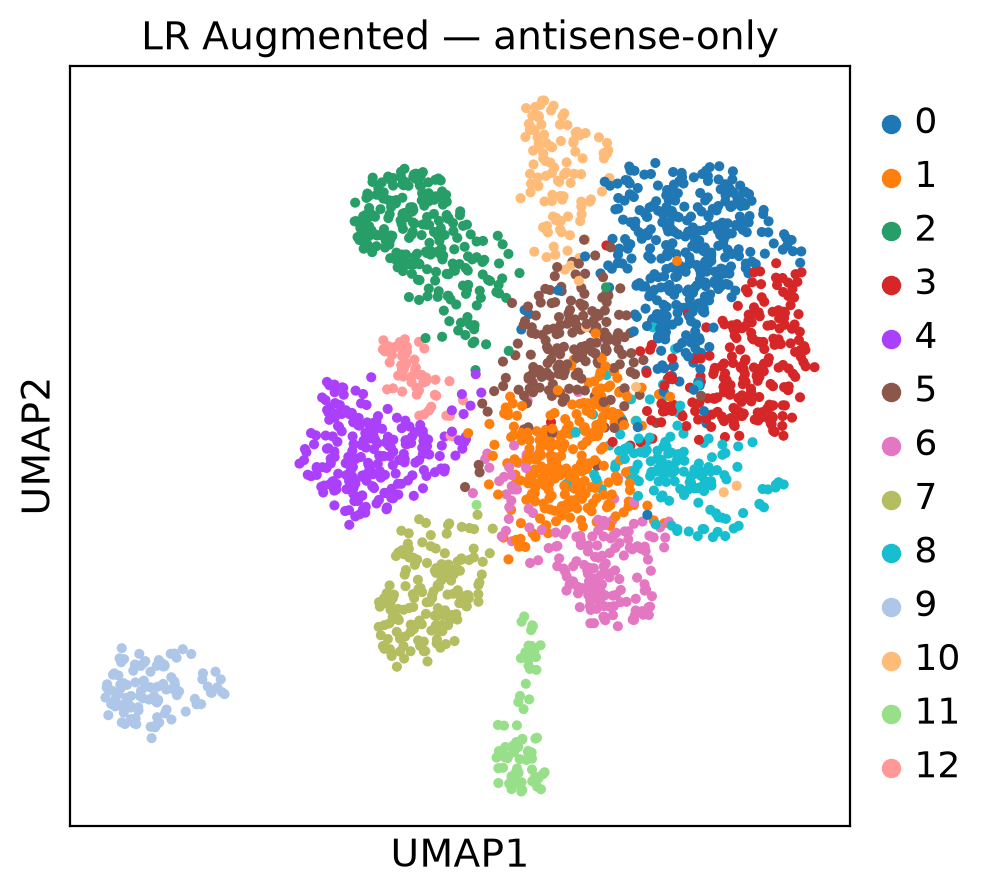

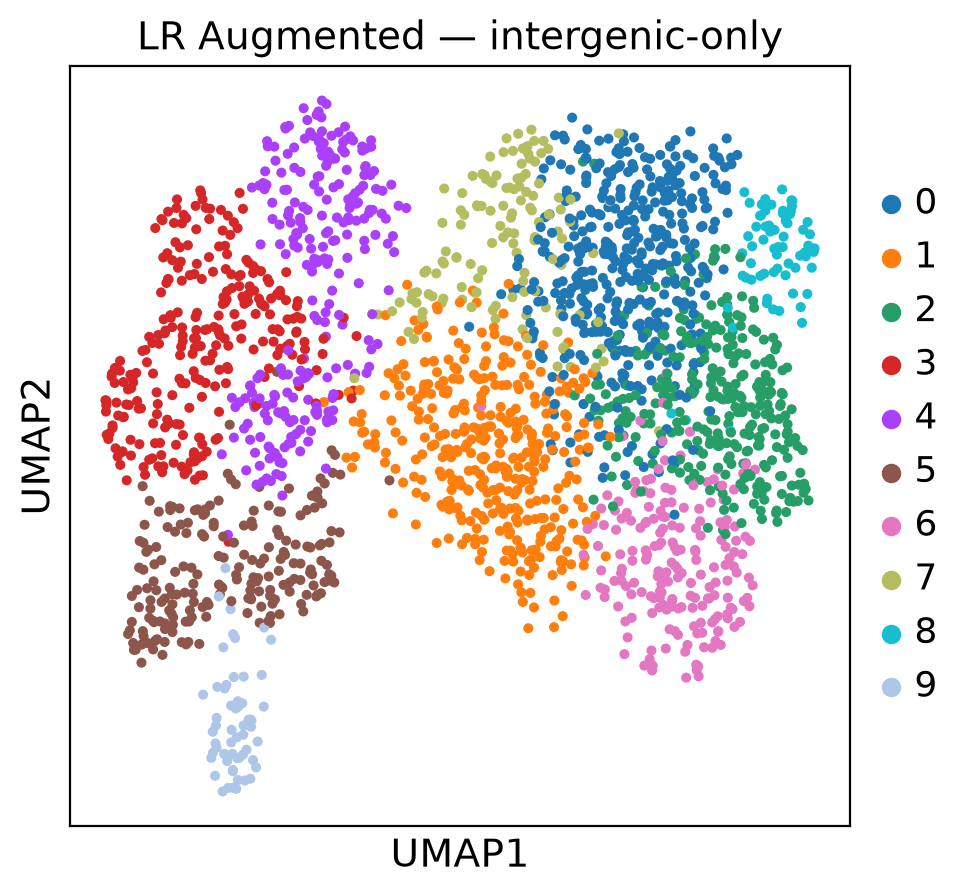

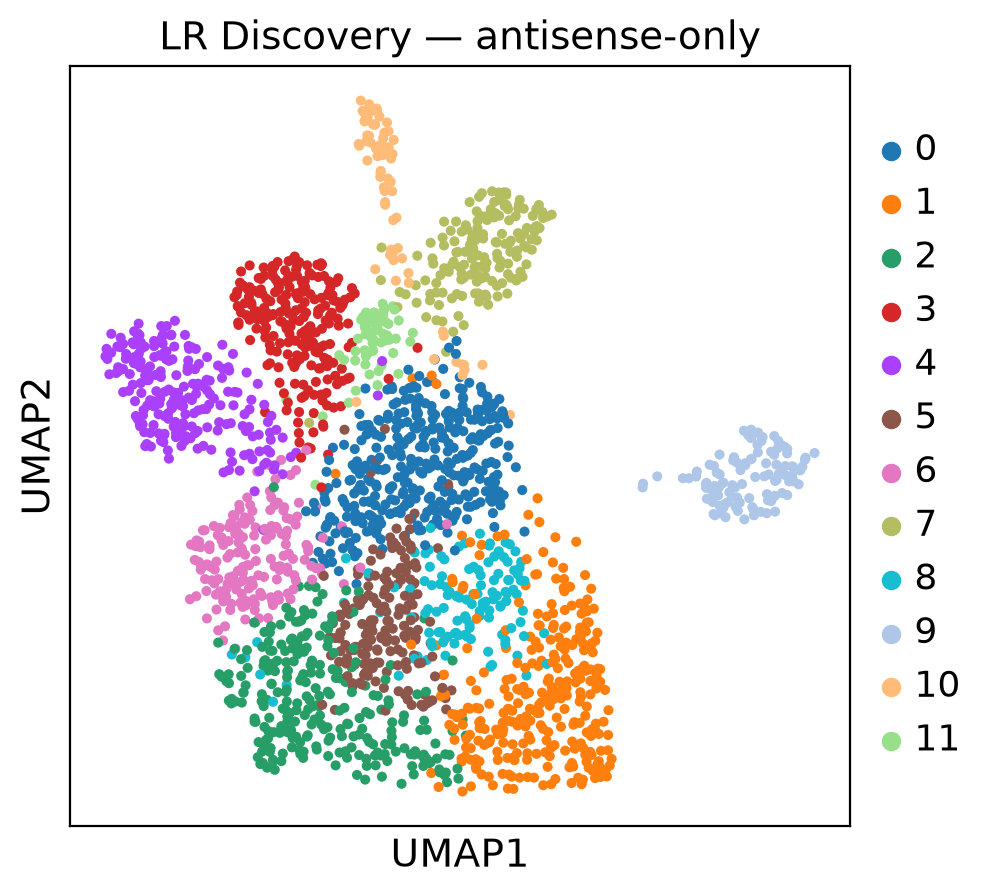

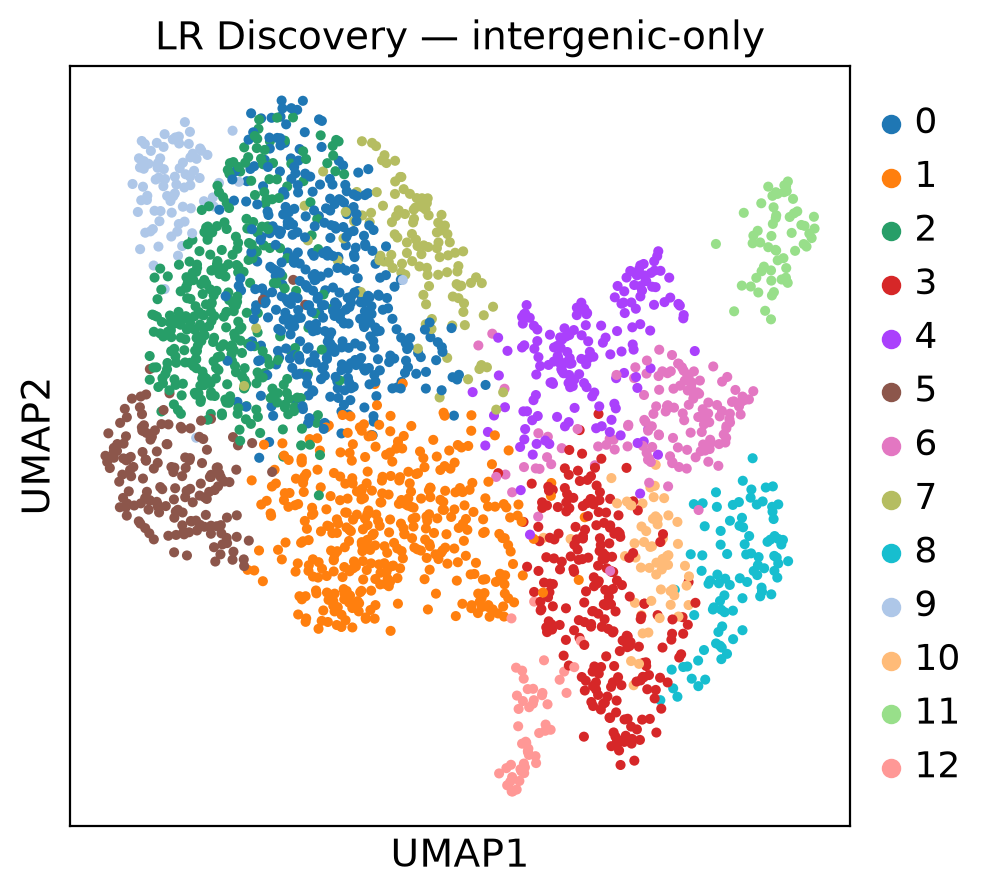

In [51]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt


sc.set_figure_params(figsize=(5, 5), frameon=True, dpi=100)

def subset_by_class(adata_raw, classes):
    # RESTORED: [1] indexing to properly match your original array syntax
    mask = np.array([parse_discovery_id(v)[1] in classes for v in adata_raw.var_names])
    return adata_raw[:, mask].copy()

lr_aug_antisense = subset_by_class(adatas_raw['LR_Aug'], {'antisense_exonic', 'antisense_intronic'})
lr_aug_intergenic = subset_by_class(adatas_raw['LR_Aug'], {'intergenic'})
lr_aug_intronic = subset_by_class(adatas_raw['LR_Aug'], {'known_gene_intronic'})
lr_dis_antisense = subset_by_class(adatas_raw['LR_Dis'], {'antisense_exonic', 'antisense_intronic'})
lr_dis_intergenic = subset_by_class(adatas_raw['LR_Dis'], {'intergenic'})

print(f"LR Aug antisense-only: {lr_aug_antisense.n_vars:,} features")
print(f"LR Aug intergenic-only: {lr_aug_intergenic.n_vars:,} features")
print(f"LR Aug intronic-only (known_gene_intronic): {lr_aug_intronic.n_vars:,} features")
print(f"LR Dis antisense-only: {lr_dis_antisense.n_vars:,} features")
print(f"LR Dis intergenic-only: {lr_dis_intergenic.n_vars:,} features")


def cluster_subset(adata, resolution=0.8, label=""):
    if adata.n_vars == 0:
        print(f"Skipping '{label}': contains 0 features.")
        return None
    a = adata.copy()
    
    n_top = min(2000, a.n_vars)
    n_comps = min(30, a.n_vars - 1, a.n_obs - 1)
    if n_comps < 1:
        print(f"Skipping '{label}': not enough features/cells for PCA.")
        return None
    sc.pp.highly_variable_genes(a, n_top_genes=n_top, flavor='seurat')
    sc.tl.pca(a, svd_solver='arpack', random_state=42, n_comps=n_comps)
    sc.pp.neighbors(a, n_neighbors=15, n_pcs=min(30, n_comps), random_state=42)
    sc.tl.umap(a, random_state=42)
    sc.tl.leiden(a, resolution=resolution, key_added='leiden', random_state=42)
    print(f"{label}: {a.obs['leiden'].nunique()} clusters ({a.n_vars:,} features)")
    return a


lr_aug_antisense_cl = cluster_subset(lr_aug_antisense, label="LR Aug antisense-only")
lr_aug_intergenic_cl = cluster_subset(lr_aug_intergenic, label="LR Aug intergenic-only")
lr_aug_intronic_cl = cluster_subset(lr_aug_intronic, label="LR Aug intronic-only")
lr_dis_antisense_cl = cluster_subset(lr_dis_antisense, label="LR Dis antisense-only")
lr_dis_intergenic_cl = cluster_subset(lr_dis_intergenic, label="LR Dis intergenic-only")


plots_to_make = [
    (lr_aug_antisense_cl, 'LR Augmented — antisense-only'),
    (lr_aug_intergenic_cl, 'LR Augmented — intergenic-only'),
    (lr_aug_intronic_cl, 'LR Augmented — intronic-only (known_gene_intronic)'),
    (lr_dis_antisense_cl, 'LR Discovery — antisense-only'),
    (lr_dis_intergenic_cl, 'LR Discovery — intergenic-only')
]


for cl_data, title in plots_to_make:
    if cl_data is not None:
        sc.pl.umap(
            cl_data, 
            color='leiden', 
            title=title, 
            show=True
        )


... storing 'Highlight_Target' as categorical


Success! Found exact structural match name: 'near:PLPP3:1375bp|intergenic|peak_312805'


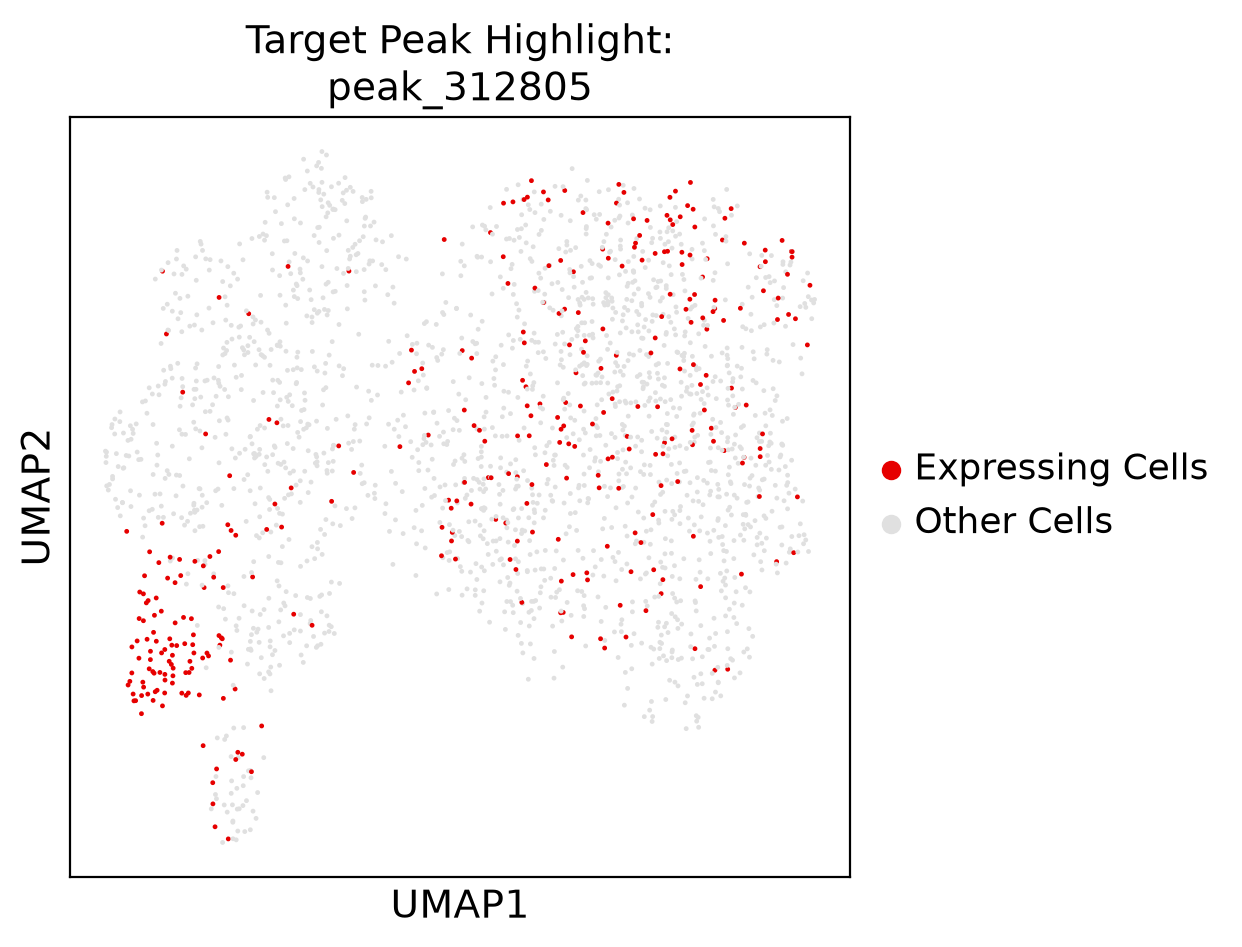

In [53]:
search_keyword = 'peak_312805'

matching_features = [v for v in lr_aug_intergenic_cl.var_names if search_keyword in str(v)]

if len(matching_features) > 0:
    target_peak = matching_features[0]
    print(f"Success! Found exact structural match name: '{target_peak}'")
    
    
    expression_values = lr_aug_intergenic_cl[:, target_peak].X
    if hasattr(expression_values, "toarray"):
        expression_values = expression_values.toarray().flatten()
    else:
        expression_values = np.asarray(expression_values).flatten()
        
   
    lr_aug_intergenic_cl.obs['Highlight_Target'] = np.where(
        expression_values > 0, 
        'Expressing Cells', 
        'Other Cells'
    )
    
    
    sc.pl.umap(
        lr_aug_intergenic_cl,
        color='Highlight_Target',
        title=f'Target Peak Highlight:\n{search_keyword}',
        palette={'Other Cells': '#e0e0e0', 'Expressing Cells': '#e60000'},
        size=12,
        show=True
    )
else:
    print(f"Error: No items containing '{search_keyword}' found in this dataset.")
    # Debug tool: display first 5 feature columns so you can verify naming format
    print("Available sample features names:", list(lr_aug_intergenic_cl.var_names[:5]))


In [57]:
sr_audit_lookup = load_audit_coordinates_igv(
    "/mnt/md0/jack-gaa/gaa/final9/SRR21492166_augmentation_audit.tsv"
)
print(f"Loaded {len(sr_audit_lookup):,} SR audit entries")

target_id = 'peak_312805'

target_row = lr_audit_lookup[lr_audit_lookup['peak_id'] == target_id]
chrom, start, end = target_row[['chromosome', 'start', 'end']].iloc[0]
print(f"{target_id}: {chrom}:{start}-{end}")

sr_same_chrom = sr_audit_lookup[sr_audit_lookup['chromosome'] == chrom]
overlap = sr_same_chrom[(sr_same_chrom['start'] < end) & (sr_same_chrom['end'] > start)]

if len(overlap) == 0:
    print(f"Confirmed: no SR peak overlaps this locus ({chrom}:{start}-{end})")
else:
    print("SR does call something here:")
    print(overlap)

Loaded 117,490 SR audit entries
peak_312805: chr1:56493250-56493386
SR does call something here:
         peak_id chromosome     start       end strand  ambiguous_multigene
6936  peak_60160       chr1  56493256  56493321      -                False


In [62]:
lr_exclusive = pd.read_csv("/mnt/md0/jack-gaa/gaa/analysis/peak_rankings/lr_exclusive_candidates.csv")
print(f"Loaded {len(lr_exclusive)} LR-exclusive candidates")
import re

def parse_locus(locus_str):
    m = re.match(r'([\w.]+):(\d+)-(\d+) \(([+-])\)', locus_str)
    if not m:
        return None
    return m.group(1), int(m.group(2)), int(m.group(3)), m.group(4)

results = []
for _, row in lr_exclusive.iterrows():
    chrom, start, end, strand = parse_locus(row['LR_Aug_locus'])
    sr_same = sr_audit_lookup[
        (sr_audit_lookup['chromosome'] == chrom) & (sr_audit_lookup['strand'] == strand)
    ]
    overlap = sr_same[(sr_same['start'] < end) & (sr_same['end'] > start)]
    results.append({
        'gene_context': row['gene_context'],
        'lr_locus': row['LR_Aug_locus'],
        'sr_overlap_found': len(overlap) > 0,
        'sr_peak_id': overlap['peak_id'].iloc[0] if len(overlap) else None,
        'overlap_bp': min(end, overlap['end'].iloc[0]) - max(start, overlap['start'].iloc[0]) if len(overlap) else 0,
    })

results_df = pd.DataFrame(results)
print(f"{results_df['sr_overlap_found'].sum()} / {len(results_df)} 'LR-exclusive' candidates actually have an SR peak at the same locus")
display(results_df)

Loaded 10 LR-exclusive candidates
7 / 10 'LR-exclusive' candidates actually have an SR peak at the same locus


,gene_context,lr_locus,sr_overlap_found,sr_peak_id,overlap_bp
0,ARHGAP24,chr4:85734642-85734952 (-),True,peak_99781,98
1,near:ENSG00000229370:4523bp,chr2:13532830-13533150 (-),True,peak_86331,11
2,ENSG00000251294,chr5:24586844-24587212 (-),True,peak_101904,112
3,BRCC3,chrX:155094096-155094392 (-),True,peak_117435,116
4,SPARCL1,chr4:87527620-87527867 (+),True,peak_40454,60
5,MYO1B-AS1,chr2:191245454-191245626 (+),False,None,0
6,near:CCDC102B:17980bp,chr18:69073169-69073501 (+),True,peak_24942,82
7,ENSG00000241666,chr1:167630265-167630444 (+),False,None,0
8,FCRL1,chr1:157819197-157819250 (+),False,None,0
9,ADAM7-AS1,chr8:24310163-24310272 (+),True,peak_51936,74
